In [6]:
# ------------------------------------------------------------
# General data handling
# ------------------------------------------------------------

import os
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# Machine learning models
# ------------------------------------------------------------

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier

# ------------------------------------------------------------
# Model selection and preprocessing
# ------------------------------------------------------------

from sklearn.model_selection import (
    StratifiedGroupKFold,
    GridSearchCV
)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# ------------------------------------------------------------
# Model evaluation
# ------------------------------------------------------------

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score,
    average_precision_score
)

print("=" * 70)
print("LIBRARIES IMPORTED SUCCESSFULLY")
print("=" * 70)

from sklearn.model_selection import StratifiedKFold

LIBRARIES IMPORTED SUCCESSFULLY


In [2]:
dataset_path = '/kaggle/input/'

# Recorremos todo el dataset
for root, dirs, files in os.walk(dataset_path):
    for file in files:
        # Construimos el path completo
        full_path = os.path.join(root, file)
        # Lo mostramos tal cual para pegar en un import
        print(f"'{full_path}'")

'/kaggle/input/datasets/maiderb/chiefptml-data/SM00.xlsx'


In [3]:
# ============================================================
# PART 2A — LOAD DATASET AND BASIC DATA VALIDATION
# ============================================================

# ------------------------------------------------------------
# Dataset path
# ------------------------------------------------------------

file_path = "/kaggle/input/datasets/maiderb/chiefptml-data/SM00.xlsx"

# ------------------------------------------------------------
# Load dataset
# ------------------------------------------------------------

df = pd.read_excel(file_path)

print("=" * 70)
print("DATASET LOADED")
print("=" * 70)

print(f"Number of rows:    {len(df):,}")
print(f"Number of columns: {len(df.columns):,}")

# ------------------------------------------------------------
# Column names
# ------------------------------------------------------------

print("\nColumn names:")

for i, col in enumerate(df.columns):
    print(f"{i:02d}: {col}")

# ------------------------------------------------------------
# Data types
# ------------------------------------------------------------

print("\nData types:")

display(df.dtypes)

# ------------------------------------------------------------
# Missing values
# ------------------------------------------------------------

print("\nMissing values:")

missing_values = (
    df.isna()
    .sum()
    .sort_values(ascending=False)
)

missing_values = missing_values[
    missing_values > 0
]

if len(missing_values) == 0:
    print("No missing values detected.")
else:
    display(missing_values)

# ------------------------------------------------------------
# Define key columns
# ------------------------------------------------------------

target = "f(vdij,vpj,vnrj)obj"
chiral_column = "Chiral Drug"
chembl_column = "CHEMBLID mi"
smiles_column = "CANONICAL_SMILES"

required_columns = [
    target,
    chiral_column,
    chembl_column,
    smiles_column
]

for column in required_columns:

    if column not in df.columns:
        raise ValueError(
            f"Required column '{column}' was not found."
        )

# ------------------------------------------------------------
# Target distribution
# ------------------------------------------------------------

print("\nTarget distribution:")

display(
    df[target]
    .value_counts(dropna=False)
    .sort_index()
    .rename("count")
    .to_frame()
)

print("\nTarget proportions:")

display(
    df[target]
    .value_counts(
        normalize=True,
        dropna=False
    )
    .sort_index()
    .rename("proportion")
    .to_frame()
)

# ------------------------------------------------------------
# Chirality distribution
# ------------------------------------------------------------

print("\nChirality distribution:")

display(
    df[chiral_column]
    .value_counts(dropna=False)
    .sort_index()
    .rename("count")
    .to_frame()
)

# ------------------------------------------------------------
# CHEMBL identifiers
# ------------------------------------------------------------

print("\nCHEMBL identifiers:")

valid_chembl = df[chembl_column].notna()

print(
    f"Rows with non-missing CHEMBL ID: "
    f"{valid_chembl.sum():,}"
)

print(
    f"Unique CHEMBL IDs: "
    f"{df.loc[valid_chembl, chembl_column].nunique():,}"
)

# ------------------------------------------------------------
# Rows per CHEMBL ID
# ------------------------------------------------------------

print("\nRows per CHEMBL ID:")

rows_per_compound = (
    df.loc[valid_chembl]
    .groupby(chembl_column)
    .size()
)

print(f"Mean:   {rows_per_compound.mean():.2f}")
print(f"Median: {rows_per_compound.median():.2f}")
print(f"Min:    {rows_per_compound.min():.0f}")
print(f"Max:    {rows_per_compound.max():.0f}")

# ------------------------------------------------------------
# Canonical SMILES
# ------------------------------------------------------------

print("\nCanonical SMILES:")

print(
    f"Unique canonical SMILES: "
    f"{df[smiles_column].nunique():,}"
)

# ------------------------------------------------------------
# CHEMBL ID -> number of different SMILES
# ------------------------------------------------------------

print("\nCHEMBL ID → number of different SMILES:")

smiles_per_compound = (
    df.loc[valid_chembl]
    .groupby(chembl_column)[smiles_column]
    .nunique()
)

print(
    f"CHEMBL IDs with exactly one SMILES: "
    f"{(smiles_per_compound == 1).sum():,}"
)

print(
    f"CHEMBL IDs with >1 SMILES: "
    f"{(smiles_per_compound > 1).sum():,}"
)

print("\n" + "=" * 70)
print("PART 2 COMPLETED SUCCESSFULLY")
print("=" * 70)

DATASET LOADED
Number of rows:    756,897
Number of columns: 16

Column names:
00: CANONICAL_SMILES
01: Chiral Drug
02: CHEMBLID mi
03: f(vdij,vpj,vnrj)obj
04: f(vdij,vpj,vnj)ref
05: fs1 = f(mi)chiral
06: fs2 = fpj
07: Sh1(D1di)
08: Sh(D2di)
09: Sh1(D1pj)
10: Sh1(D1nrj)
11: DSh1(D1di, cj)
12: DSh2(D2di, cj)
13: DSh1(D1pj, cj)
14: DSh1(D1nrj, cj)
15: Unnamed: 15

Data types:


CANONICAL_SMILES        object
Chiral Drug            float64
CHEMBLID mi             object
f(vdij,vpj,vnrj)obj    float64
f(vdij,vpj,vnj)ref     float64
fs1 = f(mi)chiral      float64
fs2 = fpj              float64
Sh1(D1di)               object
Sh(D2di)               float64
Sh1(D1pj)              float64
Sh1(D1nrj)             float64
DSh1(D1di, cj)          object
DSh2(D2di, cj)         float64
DSh1(D1pj, cj)         float64
DSh1(D1nrj, cj)        float64
Unnamed: 15            float64
dtype: object


Missing values:


Unnamed: 15            756896
CANONICAL_SMILES            1
CHEMBLID mi                 1
Chiral Drug                 1
f(vdij,vpj,vnj)ref          1
fs1 = f(mi)chiral           1
fs2 = fpj                   1
f(vdij,vpj,vnrj)obj         1
Sh1(D1di)                   1
Sh(D2di)                    1
Sh1(D1nrj)                  1
Sh1(D1pj)                   1
DSh1(D1di, cj)              1
DSh2(D2di, cj)              1
DSh1(D1pj, cj)              1
DSh1(D1nrj, cj)             1
dtype: int64


Target distribution:


...


Target proportions:


,proportion
"f(vdij,vpj,vnrj)obj",
0.0,0.887899
1.0,0.112100
NaN,0.000001



Chirality distribution:


,count
Chiral Drug,
0.0,530060
1.0,226836
NaN,1



CHEMBL identifiers:
Rows with non-missing CHEMBL ID: 756,896
Unique CHEMBL IDs: 65,536

Rows per CHEMBL ID:
Mean:   11.55
Median: 6.00
Min:    2
Max:    2160

Canonical SMILES:
Unique canonical SMILES: 65,535

CHEMBL ID → number of different SMILES:
CHEMBL IDs with exactly one SMILES: 65,535
CHEMBL IDs with >1 SMILES: 1

PART 2 COMPLETED SUCCESSFULLY


In [4]:
# ============================================================
# PART 2B — CLEAN DATASET
# ============================================================

# Work on a copy of the original dataframe
df_clean = df.copy()

# ------------------------------------------------------------
# 1. Remove the unnecessary Excel column
# ------------------------------------------------------------

if "Unnamed: 15" in df_clean.columns:
    df_clean = df_clean.drop(columns=["Unnamed: 15"])

# ------------------------------------------------------------
# 2. Define the essential columns
# ------------------------------------------------------------

essential_columns = [
    "CANONICAL_SMILES",
    "Chiral Drug",
    "CHEMBLID mi",
    "f(vdij,vpj,vnrj)obj",
    "f(vdij,vpj,vnj)ref",
    "fs1 = f(mi)chiral",
    "fs2 = fpj",
    "Sh1(D1di)",
    "Sh(D2di)",
    "Sh1(D1pj)",
    "Sh1(D1nrj)",
    "DSh1(D1di, cj)",
    "DSh2(D2di, cj)",
    "DSh1(D1pj, cj)",
    "DSh1(D1nrj, cj)"
]

# Check that all required columns are present
missing_columns = [
    col
    for col in essential_columns
    if col not in df_clean.columns
]

if missing_columns:
    raise ValueError(
        f"The following required columns are missing: "
        f"{missing_columns}"
    )

# ------------------------------------------------------------
# 3. Remove rows with missing essential information
# ------------------------------------------------------------

rows_before = len(df_clean)

missing_essential = (
    df_clean[essential_columns]
    .isna()
    .any(axis=1)
)

print("=" * 70)
print("DATA CLEANING")
print("=" * 70)

print(
    f"Rows with missing essential information: "
    f"{missing_essential.sum():,}"
)

if missing_essential.sum() > 0:
    print("\nRows that will be removed:")
    display(
        df_clean.loc[
            missing_essential,
            essential_columns
        ]
    )

df_clean = df_clean.loc[
    ~missing_essential
].copy()

rows_after = len(df_clean)

print("\nRows before cleaning:", f"{rows_before:,}")
print("Rows after cleaning: ", f"{rows_after:,}")
print("Rows removed:        ", f"{rows_before - rows_after:,}")

# ------------------------------------------------------------
# 4. Define target and chirality columns
# ------------------------------------------------------------

target = "f(vdij,vpj,vnrj)obj"
chirality = "Chiral Drug"

# ------------------------------------------------------------
# 5. Convert binary variables to integer
# ------------------------------------------------------------

df_clean[target] = (
    df_clean[target]
    .astype(int)
)

df_clean[chirality] = (
    df_clean[chirality]
    .astype(int)
)

# ------------------------------------------------------------
# 6. Validate binary variables
# ------------------------------------------------------------

print("\nTarget values:")
print(
    sorted(
        df_clean[target].unique()
    )
)

print("\nChirality values:")
print(
    sorted(
        df_clean[chirality].unique()
    )
)

if set(df_clean[target].unique()) != {0, 1}:
    raise ValueError(
        "Target variable does not contain exactly "
        "the expected values 0 and 1."
    )

if set(df_clean[chirality].unique()) != {0, 1}:
    raise ValueError(
        "Chirality variable does not contain exactly "
        "the expected values 0 and 1."
    )

# ------------------------------------------------------------
# 7. Final dataset summary
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("CLEAN DATASET SUMMARY")
print("=" * 70)

print(
    f"Rows:              {len(df_clean):,}"
)

print(
    f"Columns:           {len(df_clean.columns):,}"
)

print(
    f"Unique CHEMBL IDs: "
    f"{df_clean['CHEMBLID mi'].nunique():,}"
)

print(
    f"Unique SMILES:     "
    f"{df_clean['CANONICAL_SMILES'].nunique():,}"
)

# ------------------------------------------------------------
# 8. Target distribution
# ------------------------------------------------------------

print("\nTarget distribution:")

display(
    df_clean[target]
    .value_counts()
    .sort_index()
    .rename("count")
    .to_frame()
)

print("\nTarget proportion:")

display(
    df_clean[target]
    .value_counts(
        normalize=True
    )
    .sort_index()
    .rename("proportion")
    .to_frame()
)

# ------------------------------------------------------------
# 9. Chirality distribution
# ------------------------------------------------------------

print("\nChirality distribution:")

display(
    df_clean[chirality]
    .value_counts()
    .sort_index()
    .rename("count")
    .to_frame()
)

# ------------------------------------------------------------
# 10. CHEMBL ID validation
# ------------------------------------------------------------

print("\nCHEMBL ID validation:")

chembl_column = "CHEMBLID mi"

md_mask = (
    df_clean[chembl_column]
    .astype(str)
    .eq("m.d.")
)

print(
    f"Rows with CHEMBL ID = 'm.d.': "
    f"{md_mask.sum():,}"
)

print(
    f"Unique SMILES among 'm.d.' rows: "
    f"{df_clean.loc[md_mask, 'CANONICAL_SMILES'].nunique():,}"
)

valid_chembl = ~md_mask

print(
    f"Rows with valid CHEMBL IDs: "
    f"{valid_chembl.sum():,}"
)

print(
    f"Unique valid CHEMBL IDs: "
    f"{df_clean.loc[valid_chembl, chembl_column].nunique():,}"
)

# ------------------------------------------------------------
# 11. Rows per valid CHEMBL ID
# ------------------------------------------------------------

rows_per_compound = (
    df_clean.loc[valid_chembl]
    .groupby(chembl_column)
    .size()
)

print("\nRows per valid CHEMBL ID:")

print(
    f"Mean:   {rows_per_compound.mean():.2f}"
)

print(
    f"Median: {rows_per_compound.median():.2f}"
)

print(
    f"Min:    {rows_per_compound.min():.0f}"
)

print(
    f"Max:    {rows_per_compound.max():.0f}"
)

# ------------------------------------------------------------
# 12. Number of SMILES per valid CHEMBL ID
# ------------------------------------------------------------

smiles_per_compound = (
    df_clean.loc[valid_chembl]
    .groupby(chembl_column)["CANONICAL_SMILES"]
    .nunique()
)

multiple_smiles = (
    smiles_per_compound > 1
)

print(
    "\nValid CHEMBL IDs with more than one SMILES:"
)

print(
    multiple_smiles.sum()
)

if multiple_smiles.sum() > 0:

    print(
        "\nCHEMBL IDs with multiple SMILES:"
    )

    display(
        smiles_per_compound[
            multiple_smiles
        ]
        .sort_values(
            ascending=False
        )
        .to_frame(
            "number_of_SMILES"
        )
    )

# ------------------------------------------------------------
# 13. Final cleaning check
# ------------------------------------------------------------

print("\nFinal missing-value check:")

remaining_missing = (
    df_clean[essential_columns]
    .isna()
    .sum()
)

remaining_missing = (
    remaining_missing[
        remaining_missing > 0
    ]
)

if len(remaining_missing) == 0:
    print(
        "No missing values remain in the essential columns."
    )
else:
    display(remaining_missing)

print("\n" + "=" * 70)
print("PART 2B COMPLETED SUCCESSFULLY")
print("=" * 70)

DATA CLEANING
Rows with missing essential information: 1

Rows that will be removed:


,CANONICAL_SMILES,Chiral Drug,CHEMBLID mi,"f(vdij,vpj,vnrj)obj","f(vdij,vpj,vnj)ref",fs1 = f(mi)chiral,fs2 = fpj,Sh1(D1di),Sh(D2di),Sh1(D1pj),Sh1(D1nrj),"DSh1(D1di, cj)","DSh2(D2di, cj)","DSh1(D1pj, cj)","DSh1(D1nrj, cj)"
756896,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Rows before cleaning: 756,897
Rows after cleaning:  756,896
Rows removed:         1

Target values:
[np.int64(0), np.int64(1)]

Chirality values:
[np.int64(0), np.int64(1)]

CLEAN DATASET SUMMARY
Rows:              756,896
Columns:           15
Unique CHEMBL IDs: 65,536
Unique SMILES:     65,535

Target distribution:


,count
"f(vdij,vpj,vnrj)obj",
0,672048
1,84848



Target proportion:


,proportion
"f(vdij,vpj,vnrj)obj",
0,0.8879
1,0.1121



Chirality distribution:


,count
Chiral Drug,
0,530060
1,226836



CHEMBL ID validation:
Rows with CHEMBL ID = 'm.d.': 2,160
Unique SMILES among 'm.d.' rows: 290
Rows with valid CHEMBL IDs: 754,736
Unique valid CHEMBL IDs: 65,535

Rows per valid CHEMBL ID:
Mean:   11.52
Median: 6.00
Min:    2
Max:    1536

Valid CHEMBL IDs with more than one SMILES:
0

Final missing-value check:
No missing values remain in the essential columns.

PART 2B COMPLETED SUCCESSFULLY


In [5]:
# ============================================================
# PART 3 — DEFINE COMPOUND-LEVEL GROUPING
# ============================================================

target = "f(vdij,vpj,vnrj)obj"
chembl_column = "CHEMBLID mi"
smiles_column = "CANONICAL_SMILES"

# ------------------------------------------------------------
# 1. Define compound-level grouping
# ------------------------------------------------------------

# Use the CHEMBL ID as the compound identifier whenever
# a valid CHEMBL ID is available.
df_clean["compound_group"] = (
    df_clean[chembl_column].astype(str)
)

# For records without a valid CHEMBL ID (marked as "m.d."),
# use the canonical SMILES as the compound-level identifier.
md_chembl = (
    df_clean[chembl_column]
    .astype(str)
    .eq("m.d.")
)

df_clean.loc[md_chembl, "compound_group"] = (
    "SMILES_"
    + df_clean.loc[
        md_chembl,
        smiles_column
    ].astype(str)
)

# ------------------------------------------------------------
# 2. Basic compound-group validation
# ------------------------------------------------------------

print("=" * 70)
print("COMPOUND-LEVEL IDENTIFICATION")
print("=" * 70)

total_rows = len(df_clean)

unique_compound_groups = (
    df_clean["compound_group"].nunique()
)

print(
    f"Total rows:             {total_rows:,}"
)

print(
    f"Unique compound groups: {unique_compound_groups:,}"
)

print("\nRows with valid CHEMBL IDs:")
print(
    (~md_chembl).sum()
)

print("\nRows with CHEMBL ID marked as 'm.d.':")
print(
    md_chembl.sum()
)

print("\nUnique groups generated from 'm.d.' records:")
print(
    df_clean.loc[
        md_chembl,
        "compound_group"
    ].nunique()
)

# ------------------------------------------------------------
# 3. Validate that every row has a compound group
# ------------------------------------------------------------

missing_groups = (
    df_clean["compound_group"]
    .isna()
    .sum()
)

empty_groups = (
    df_clean["compound_group"]
    .astype(str)
    .str.strip()
    .eq("")
    .sum()
)

print("\nCompound-group validation:")
print(
    f"Missing compound groups: {missing_groups:,}"
)
print(
    f"Empty compound groups:   {empty_groups:,}"
)

if missing_groups > 0 or empty_groups > 0:
    raise ValueError(
        "Invalid compound groups detected."
    )

# ------------------------------------------------------------
# 4. Check whether one compound group contains
#    multiple canonical SMILES
# ------------------------------------------------------------

smiles_per_group = (
    df_clean
    .groupby("compound_group")[smiles_column]
    .nunique()
)

multiple_smiles_groups = (
    smiles_per_group[
        smiles_per_group > 1
    ]
)

print(
    "\nCompound groups containing multiple SMILES:"
)
print(
    len(multiple_smiles_groups)
)

if len(multiple_smiles_groups) > 0:

    display(
        multiple_smiles_groups
        .sort_values(
            ascending=False
        )
        .head(20)
        .rename(
            "number_of_SMILES"
        )
        .to_frame()
    )

    raise ValueError(
        "At least one compound group contains "
        "multiple canonical SMILES."
    )

# ------------------------------------------------------------
# 5. Check target consistency within compounds
# ------------------------------------------------------------

target_values_per_group = (
    df_clean
    .groupby("compound_group")[target]
    .nunique()
)

mixed_activity_groups = (
    target_values_per_group[
        target_values_per_group > 1
    ]
)

n_mixed_groups = len(
    mixed_activity_groups
)

mixed_group_percentage = (
    100
    * n_mixed_groups
    / unique_compound_groups
)

print(
    "\nCompound groups containing both "
    "active and inactive assays:"
)
print(
    f"{n_mixed_groups:,}"
)

print(
    "\nPercentage of compound groups with "
    "both activities:"
)
print(
    f"{mixed_group_percentage:.2f}%"
)

# ------------------------------------------------------------
# 6. Distribution of number of assays per compound
# ------------------------------------------------------------

assays_per_group = (
    df_clean
    .groupby("compound_group")
    .size()
)

print(
    "\nAssays per compound group:"
)

print(
    f"Mean:   {assays_per_group.mean():.2f}"
)

print(
    f"Median: {assays_per_group.median():.2f}"
)

print(
    f"Min:    {assays_per_group.min():.0f}"
)

print(
    f"Max:    {assays_per_group.max():.0f}"
)

# ------------------------------------------------------------
# 7. Final compound-group summary
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("COMPOUND-LEVEL GROUPING SUMMARY")
print("=" * 70)

print(
    f"Total assay rows:              {total_rows:,}"
)

print(
    f"Total compound groups:         {unique_compound_groups:,}"
)

print(
    f"CHEMBL-based groups:           "
    f"{(~md_chembl).sum():,} rows"
)

print(
    f"SMILES-based groups:           "
    f"{md_chembl.sum():,} rows"
)

print(
    f"Groups with multiple SMILES:   "
    f"{len(multiple_smiles_groups):,}"
)

print(
    f"Groups with mixed activity:    "
    f"{n_mixed_groups:,}"
)

print("\n" + "=" * 70)
print("PART 3 COMPLETED SUCCESSFULLY")
print("=" * 70)

COMPOUND-LEVEL IDENTIFICATION
Total rows:             756,896
Unique compound groups: 65,825

Rows with valid CHEMBL IDs:
754736

Rows with CHEMBL ID marked as 'm.d.':
2160

Unique groups generated from 'm.d.' records:
290

Compound-group validation:
Missing compound groups: 0
Empty compound groups:   0

Compound groups containing multiple SMILES:
0

Compound groups containing both active and inactive assays:
20,798

Percentage of compound groups with both activities:
31.60%

Assays per compound group:
Mean:   11.50
Median: 6.00
Min:    2
Max:    1536

COMPOUND-LEVEL GROUPING SUMMARY
Total assay rows:              756,896
Total compound groups:         65,825
CHEMBL-based groups:           754,736 rows
SMILES-based groups:           2,160 rows
Groups with multiple SMILES:   0
Groups with mixed activity:    20,798

PART 3 COMPLETED SUCCESSFULLY


In [7]:
# ============================================================
# PART 4 — COMPOUND-LEVEL TRAIN/TEST SPLIT
# ============================================================

from sklearn.model_selection import StratifiedKFold

target = "f(vdij,vpj,vnrj)obj"
group_column = "compound_group"

# ------------------------------------------------------------
# 1. Create a compound-level stratification label
# ------------------------------------------------------------
#
# A compound is considered active if at least one of its
# assay records is active.
#
# This compound-level label is used only to stratify the
# train/test partition.
#
# The original assay-level target labels remain unchanged.

compound_activity = (
    df_clean
    .groupby(group_column)[target]
    .max()
    .astype(int)
)

print("=" * 70)
print("COMPOUND-LEVEL TRAIN/TEST SPLIT")
print("=" * 70)

print("\nCompound-level activity distribution:")

display(
    compound_activity
    .value_counts()
    .sort_index()
    .rename("number_of_compounds")
    .to_frame()
)

print("\nCompound-level activity proportion:")

display(
    compound_activity
    .value_counts(normalize=True)
    .sort_index()
    .rename("proportion")
    .to_frame()
)

# ------------------------------------------------------------
# 2. Build one-row-per-compound dataframe
# ------------------------------------------------------------

compound_df = pd.DataFrame({
    group_column: compound_activity.index,
    "compound_active": compound_activity.values
})

print("\nNumber of compound groups:")
print(
    f"{len(compound_df):,}"
)

# ------------------------------------------------------------
# 3. Stratified compound-level train/test split
# ------------------------------------------------------------
#
# StratifiedKFold is applied to the compound-level dataframe,
# not to individual assay records.
#
# One of the five folds is used as the test set and the
# remaining four folds as the training set.

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

train_idx, test_idx = next(
    skf.split(
        compound_df,
        compound_df["compound_active"]
    )
)

train_groups = set(
    compound_df.iloc[train_idx][group_column]
)

test_groups = set(
    compound_df.iloc[test_idx][group_column]
)

# ------------------------------------------------------------
# 4. Validate compound assignment
# ------------------------------------------------------------

all_groups = set(
    compound_df[group_column]
)

assigned_groups = (
    train_groups.union(test_groups)
)

unassigned_groups = (
    all_groups - assigned_groups
)

overlap = (
    train_groups.intersection(test_groups)
)

print("\nCompound groups:")
print(
    f"Total groups:       {len(all_groups):,}"
)

print(
    f"Training groups:    {len(train_groups):,}"
)

print(
    f"Test groups:        {len(test_groups):,}"
)

print(
    f"Overlapping groups: {len(overlap):,}"
)

print(
    f"Unassigned groups:  {len(unassigned_groups):,}"
)

if len(overlap) != 0:
    raise RuntimeError(
        "ERROR: Some compounds appear in both "
        "training and test sets."
    )

if len(unassigned_groups) != 0:
    raise RuntimeError(
        "ERROR: Some compound groups were not "
        "assigned to either training or test."
    )

if len(assigned_groups) != len(all_groups):
    raise RuntimeError(
        "ERROR: The train/test assignment does not "
        "cover all compound groups."
    )

print(
    "\nCompound-level separation verified successfully."
)

# ------------------------------------------------------------
# 5. Assign all assay records from each compound to the
#    corresponding dataset partition
# ------------------------------------------------------------

df_clean["dataset_split"] = np.where(
    df_clean[group_column].isin(train_groups),
    "train",
    "test"
)

# ------------------------------------------------------------
# 6. Verify separation after assignment to assay records
# ------------------------------------------------------------

train_group_set = set(
    df_clean.loc[
        df_clean["dataset_split"] == "train",
        group_column
    ]
)

test_group_set = set(
    df_clean.loc[
        df_clean["dataset_split"] == "test",
        group_column
    ]
)

overlap_after_assignment = (
    train_group_set.intersection(
        test_group_set
    )
)

print("\nCompound separation after assay-level assignment:")
print(
    f"Training groups:    {len(train_group_set):,}"
)

print(
    f"Test groups:        {len(test_group_set):,}"
)

print(
    f"Overlapping groups: "
    f"{len(overlap_after_assignment):,}"
)

if len(overlap_after_assignment) != 0:
    raise RuntimeError(
        "ERROR: Compound overlap detected after "
        "assigning assay records."
    )

# ------------------------------------------------------------
# 7. Row-level dataset distribution
# ------------------------------------------------------------

print("\nRow-level dataset distribution:")

split_summary = (
    df_clean
    .groupby("dataset_split")[target]
    .agg(
        rows="count",
        active="sum"
    )
)

split_summary["inactive"] = (
    split_summary["rows"]
    - split_summary["active"]
)

split_summary["active_rate"] = (
    split_summary["active"]
    / split_summary["rows"]
)

split_summary["row_percentage"] = (
    100
    * split_summary["rows"]
    / len(df_clean)
)

display(split_summary)

# ------------------------------------------------------------
# 8. Compound-level dataset distribution
# ------------------------------------------------------------

print("\nCompound-level dataset distribution:")

compound_split_summary = (
    compound_df.assign(
        dataset_split=np.where(
            compound_df[group_column].isin(train_groups),
            "train",
            "test"
        )
    )
    .groupby("dataset_split")["compound_active"]
    .agg(
        compounds="count",
        active_compounds="sum"
    )
)

compound_split_summary["inactive_compounds"] = (
    compound_split_summary["compounds"]
    - compound_split_summary["active_compounds"]
)

compound_split_summary["active_compound_rate"] = (
    compound_split_summary["active_compounds"]
    / compound_split_summary["compounds"]
)

display(compound_split_summary)

# ------------------------------------------------------------
# 9. Final split summary
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("TRAIN/TEST SPLIT SUMMARY")
print("=" * 70)

print(
    f"Total compound groups: {len(all_groups):,}"
)

print(
    f"Training compounds:    {len(train_groups):,}"
)

print(
    f"Test compounds:        {len(test_groups):,}"
)

print(
    f"Compound overlap:      {len(overlap_after_assignment):,}"
)

print(
    f"Training assay rows:   "
    f"{(df_clean['dataset_split'] == 'train').sum():,}"
)

print(
    f"Test assay rows:       "
    f"{(df_clean['dataset_split'] == 'test').sum():,}"
)

print("\n" + "=" * 70)
print("PART 4 COMPLETED SUCCESSFULLY")
print("=" * 70)

COMPOUND-LEVEL TRAIN/TEST SPLIT

Compound-level activity distribution:


,number_of_compounds
"f(vdij,vpj,vnrj)obj",
0,44363
1,21462



Compound-level activity proportion:


,proportion
"f(vdij,vpj,vnrj)obj",
0,0.673954
1,0.326046



Number of compound groups:
65,825

Compound groups:
Total groups:       65,825
Training groups:    52,660
Test groups:        13,165
Overlapping groups: 0
Unassigned groups:  0

Compound-level separation verified successfully.

Compound separation after assay-level assignment:
Training groups:    52,660
Test groups:        13,165
Overlapping groups: 0

Row-level dataset distribution:


,rows,active,inactive,active_rate,row_percentage
dataset_split,,,,,
test,151862,16555,135307,0.109013,20.063787
train,605034,68293,536741,0.112875,79.936213



Compound-level dataset distribution:


,compounds,active_compounds,inactive_compounds,active_compound_rate
dataset_split,,,,
test,13165,4293,8872,0.326092
train,52660,17169,35491,0.326035



TRAIN/TEST SPLIT SUMMARY
Total compound groups: 65,825
Training compounds:    52,660
Test compounds:        13,165
Compound overlap:      0
Training assay rows:   605,034
Test assay rows:       151,862

PART 4 COMPLETED SUCCESSFULLY


In [8]:
# ============================================================
# CHECK EXACT COLUMN NAMES
# ============================================================

print("=" * 70)
print("CURRENT COLUMNS IN df_clean")
print("=" * 70)

for i, column in enumerate(df_clean.columns, start=1):
    print(f"{i:2d}. {column}")

CURRENT COLUMNS IN df_clean
 1. CANONICAL_SMILES
 2. Chiral Drug
 3. CHEMBLID mi
 4. f(vdij,vpj,vnrj)obj
 5. f(vdij,vpj,vnj)ref
 6. fs1 = f(mi)chiral
 7. fs2 = fpj
 8. Sh1(D1di)
 9. Sh(D2di)
10. Sh1(D1pj)
11. Sh1(D1nrj)
12. DSh1(D1di, cj)
13. DSh2(D2di, cj)
14. DSh1(D1pj, cj)
15. DSh1(D1nrj, cj)
16. compound_group
17. dataset_split


In [9]:
# ============================================================
# PART 5A — CHECK FEATURE DATA TYPES
# ============================================================

feature_columns = [
    'f(vdij,vpj,vnj)ref',
    'fs2 = fpj',
    'Sh1(D1di)',
    'Sh(D2di)',
    'DSh1(D1nrj, cj)',
    'DSh1(D1di, cj)',
    'DSh2(D2di, cj)',
    'fs1 = f(mi)chiral'
]

print("=" * 70)
print("DATA TYPES OF ML FEATURES")
print("=" * 70)

# ------------------------------------------------------------
# 1. Check original data types
# ------------------------------------------------------------

print("\nOriginal data types:")

for column in feature_columns:

    print(
        f"{column:35s} -> "
        f"{df_clean[column].dtype}"
    )

# ------------------------------------------------------------
# 2. Check numeric convertibility
# ------------------------------------------------------------

print("\nNumeric conversion check:")

conversion_summary = []

for column in feature_columns:

    numeric_values = pd.to_numeric(
        df_clean[column],
        errors="coerce"
    )

    original_missing = (
        df_clean[column]
        .isna()
        .sum()
    )

    converted_missing = (
        numeric_values
        .isna()
        .sum()
    )

    non_numeric_count = (
        converted_missing
        - original_missing
    )

    conversion_summary.append({
        "feature": column,
        "original_dtype": str(
            df_clean[column].dtype
        ),
        "original_missing": original_missing,
        "non_numeric_entries": non_numeric_count,
        "missing_after_conversion": converted_missing
    })

conversion_summary = pd.DataFrame(
    conversion_summary
)

display(
    conversion_summary
)

# ------------------------------------------------------------
# 3. Display examples of non-numeric entries
# ------------------------------------------------------------

print("\nNon-numeric values/examples:")

for column in feature_columns:

    numeric_values = pd.to_numeric(
        df_clean[column],
        errors="coerce"
    )

    non_numeric_mask = (
        numeric_values.isna()
        & df_clean[column].notna()
    )

    non_numeric = (
        df_clean.loc[
            non_numeric_mask,
            column
        ]
    )

    print(f"\n{column}")

    print(
        f"  Non-numeric entries: "
        f"{len(non_numeric):,}"
    )

    if len(non_numeric) > 0:

        print(
            "  Examples:"
        )

        print(
            non_numeric
            .astype(str)
            .unique()[:10]
        )

# ------------------------------------------------------------
# 4. Overall validation
# ------------------------------------------------------------

total_non_numeric = (
    conversion_summary[
        "non_numeric_entries"
    ].sum()
)

total_missing_after_conversion = (
    conversion_summary[
        "missing_after_conversion"
    ].sum()
)

print("\n" + "=" * 70)
print("FEATURE TYPE VALIDATION SUMMARY")
print("=" * 70)

print(
    f"Total non-numeric entries: "
    f"{total_non_numeric:,}"
)

print(
    f"Total missing values after numeric conversion: "
    f"{total_missing_after_conversion:,}"
)

if total_non_numeric == 0:
    print(
        "\nAll ML features are numerically convertible."
    )
else:
    print(
        "\nWARNING: Non-numeric feature values were detected."
    )

print("\n" + "=" * 70)
print("PART 5A COMPLETED")
print("=" * 70)

DATA TYPES OF ML FEATURES

Original data types:
f(vdij,vpj,vnj)ref                  -> float64
fs2 = fpj                           -> float64
Sh1(D1di)                           -> object
Sh(D2di)                            -> float64
DSh1(D1nrj, cj)                     -> float64
DSh1(D1di, cj)                      -> object
DSh2(D2di, cj)                      -> float64
fs1 = f(mi)chiral                   -> float64

Numeric conversion check:


,feature,original_dtype,original_missing,non_numeric_entries,missing_after_conversion
0,"f(vdij,vpj,vnj)ref",float64,0,0,0
1,fs2 = fpj,float64,0,0,0
2,Sh1(D1di),object,0,3,3
3,Sh(D2di),float64,0,0,0
4,"DSh1(D1nrj, cj)",float64,0,0,0
5,"DSh1(D1di, cj)",object,0,3,3
6,"DSh2(D2di, cj)",float64,0,0,0
7,fs1 = f(mi)chiral,float64,0,0,0



Non-numeric values/examples:

f(vdij,vpj,vnj)ref
  Non-numeric entries: 0

fs2 = fpj
  Non-numeric entries: 0

Sh1(D1di)
  Non-numeric entries: 3
  Examples:
['#íNUM!' '#íREF!']

Sh(D2di)
  Non-numeric entries: 0

DSh1(D1nrj, cj)
  Non-numeric entries: 0

DSh1(D1di, cj)
  Non-numeric entries: 3
  Examples:
['#íNUM!' '#íREF!']

DSh2(D2di, cj)
  Non-numeric entries: 0

fs1 = f(mi)chiral
  Non-numeric entries: 0

FEATURE TYPE VALIDATION SUMMARY
Total non-numeric entries: 6
Total missing values after numeric conversion: 6


PART 5A COMPLETED


In [10]:
# ============================================================
# PART 5B — IDENTIFY INVALID FEATURE ROWS
# ============================================================

problem_columns = [
    'Sh1(D1di)',
    'DSh1(D1di, cj)'
]

problem_mask = pd.Series(False, index=df_clean.index)

for column in problem_columns:
    numeric_values = pd.to_numeric(
        df_clean[column],
        errors='coerce'
    )

    problem_mask |= (
        numeric_values.isna()
        & df_clean[column].notna()
    )

problem_rows = df_clean.loc[
    problem_mask,
    [
        'CANONICAL_SMILES',
        'CHEMBLID mi',
        'Chiral Drug',
        'f(vdij,vpj,vnrj)obj',
        'Sh1(D1di)',
        'DSh1(D1di, cj)',
        'compound_group',
        'dataset_split'
    ]
]

print("=" * 70)
print("INVALID FEATURE ROWS")
print("=" * 70)

print(f"Number of affected rows: {len(problem_rows)}")

print("\nAffected rows:")
print(problem_rows.to_string(index=True))

print("\nTarget distribution:")
print(
    problem_rows['f(vdij,vpj,vnrj)obj']
    .value_counts(dropna=False)
)

print("\nDataset split:")
print(
    problem_rows['dataset_split']
    .value_counts(dropna=False)
)

INVALID FEATURE ROWS
Number of affected rows: 3

Affected rows:
                                      CANONICAL_SMILES  CHEMBLID mi  Chiral Drug  f(vdij,vpj,vnrj)obj Sh1(D1di) DSh1(D1di, cj) compound_group dataset_split
254961                            C\C=C\CC1COCCC(=N1)N  CHEMBL89431            0                    0    #íNUM!         #íNUM!    CHEMBL89431          test
395871                            C\C=C\CC1COCCC(=N1)N  CHEMBL89431            0                    0    #íREF!         #íREF!    CHEMBL89431          test
696011  NC(CCC(=O)NC(CSCc1ccccc1)C(=O)NCCC(=O)O)C(=O)O  CHEMBL58451            0                    0    #íNUM!         #íNUM!    CHEMBL58451         train

Target distribution:
f(vdij,vpj,vnrj)obj
0    3
Name: count, dtype: int64

Dataset split:
dataset_split
test     2
train    1
Name: count, dtype: int64


In [11]:
# ============================================================
# PART 5C — BUILD FINAL V1–V15 FEATURE MATRIX
# ============================================================

target = 'f(vdij,vpj,vnrj)obj'

# ------------------------------------------------------------
# 1. Define ML variables
# ------------------------------------------------------------

numeric_columns = [
    'f(vdij,vpj,vnj)ref',
    'fs2 = fpj',
    'Sh1(D1di)',
    'Sh(D2di)',
    'Sh1(D1pj)',
    'DSh1(D1nrj, cj)',
    'DSh1(D1di, cj)',
    'DSh2(D2di, cj)',
    'fs1 = f(mi)chiral'
]

# ------------------------------------------------------------
# 2. Create ML-specific dataframe
# ------------------------------------------------------------

df_ml = df_clean.copy()

# ------------------------------------------------------------
# 3. Convert ML variables to numeric
# ------------------------------------------------------------
#
# Invalid Excel entries such as #NUM! and #REF! are converted
# to NaN and removed in the next step.

for column in numeric_columns:

    df_ml[column] = pd.to_numeric(
        df_ml[column],
        errors='coerce'
    )

# ------------------------------------------------------------
# 4. Remove rows with invalid/missing ML variables
# ------------------------------------------------------------

before_rows = len(df_ml)

df_ml = (
    df_ml
    .dropna(
        subset=numeric_columns + [target]
    )
    .copy()
)

removed_rows = (
    before_rows
    - len(df_ml)
)

# ------------------------------------------------------------
# 5. Validate the expected cleaning result
# ------------------------------------------------------------

print("=" * 70)
print("FINAL ML DATASET")
print("=" * 70)

print(
    f"Original rows:        {before_rows:,}"
)

print(
    f"Removed invalid rows: {removed_rows:,}"
)

print(
    f"Final ML rows:        {len(df_ml):,}"
)

if removed_rows != 3:
    raise ValueError(
        "Unexpected number of rows removed during "
        "ML feature cleaning."
    )

if len(df_ml) != 756893:
    raise ValueError(
        "Unexpected final ML dataset size."
    )

# ------------------------------------------------------------
# 6. Build V1–V7
# ------------------------------------------------------------

X_features = pd.DataFrame(
    index=df_ml.index
)

X_features['V1'] = (
    df_ml['f(vdij,vpj,vnj)ref']
)

X_features['V2'] = (
    df_ml['fs2 = fpj']
)

X_features['V3'] = (
    df_ml['DSh1(D1di, cj)']
)

X_features['V4'] = (
    df_ml['Sh(D2di)']
)

X_features['V5'] = (
    df_ml['DSh2(D2di, cj)']
)

X_features['V6'] = (
    df_ml['Sh1(D1pj)']
)

X_features['V7'] = (
    df_ml['DSh1(D1nrj, cj)']
)

# ------------------------------------------------------------
# 7. Build V8–V14
# ------------------------------------------------------------

f_chiral = (
    df_ml['fs1 = f(mi)chiral']
)

X_features['V8'] = (
    f_chiral
    * df_ml['Sh1(D1di)']
    * df_ml['Sh(D2di)']
)

X_features['V9'] = (
    f_chiral
    * df_ml['Sh(D2di)']
)

X_features['V10'] = (
    f_chiral
    * df_ml['Sh1(D1di)']
    * df_ml['DSh2(D2di, cj)']
)

X_features['V11'] = (
    f_chiral
    * df_ml['Sh(D2di)']
    * df_ml['DSh2(D2di, cj)']
)

X_features['V12'] = (
    f_chiral
    * df_ml['Sh1(D1di)']
)

X_features['V13'] = (
    f_chiral
    * df_ml['Sh1(D1di)']
    * df_ml['Sh(D2di)']
    * df_ml['DSh2(D2di, cj)']
)

X_features['V14'] = (
    f_chiral
    * df_ml['DSh2(D2di, cj)']
)

# ------------------------------------------------------------
# 8. Build V15
# ------------------------------------------------------------

X_features['V15'] = f_chiral

# ------------------------------------------------------------
# 9. Build target
# ------------------------------------------------------------

y = (
    df_ml[target]
    .astype(int)
)

# ------------------------------------------------------------
# 10. Build metadata
# ------------------------------------------------------------

metadata = df_ml[
    [
        'CANONICAL_SMILES',
        'Chiral Drug',
        'CHEMBLID mi',
        'compound_group',
        'dataset_split'
    ]
].copy()

# ------------------------------------------------------------
# 11. Validate feature matrix
# ------------------------------------------------------------

if X_features.isna().sum().sum() != 0:
    raise ValueError(
        "Missing values remain in X_features."
    )

if y.isna().sum() != 0:
    raise ValueError(
        "Missing values remain in the target."
    )

if len(X_features) != len(y):
    raise ValueError(
        "X_features and y have different numbers of rows."
    )

if len(X_features) != len(metadata):
    raise ValueError(
        "X_features and metadata have different "
        "numbers of rows."
    )

# ------------------------------------------------------------
# 12. Validate feature names
# ------------------------------------------------------------

expected_features = [
    'V1', 'V2', 'V3', 'V4', 'V5',
    'V6', 'V7', 'V8', 'V9', 'V10',
    'V11', 'V12', 'V13', 'V14', 'V15'
]

if list(X_features.columns) != expected_features:
    raise ValueError(
        "Feature names or order do not match V1–V15."
    )

# ------------------------------------------------------------
# 13. Final dataset summary
# ------------------------------------------------------------

print(
    f"\nFeature matrix shape: "
    f"{X_features.shape}"
)

print(
    "\nFeatures:"
)

print(
    list(X_features.columns)
)

print(
    "\nMissing values in X_features:"
)

print(
    X_features.isna().sum().sum()
)

print(
    "\nTarget distribution:"
)

display(
    y.value_counts()
    .sort_index()
    .rename("count")
    .to_frame()
)

print(
    "\nDataset split:"
)

display(
    metadata[
        'dataset_split'
    ]
    .value_counts()
    .to_frame("rows")
)

print(
    "\nChirality distribution:"
)

display(
    metadata[
        'Chiral Drug'
    ]
    .value_counts()
    .sort_index()
    .to_frame("rows")
)

print(
    "\nUnique compound groups:"
)

print(
    metadata[
        'compound_group'
    ].nunique()
)

# ------------------------------------------------------------
# 14. Final ML dataset validation
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FINAL ML DATASET VALIDATION")
print("=" * 70)

print(
    f"Rows:                 {len(df_ml):,}"
)

print(
    f"Features:             {X_features.shape[1]}"
)

print(
    f"Compound groups:      "
    f"{metadata['compound_group'].nunique():,}"
)

print(
    f"Train rows:           "
    f"{(metadata['dataset_split'] == 'train').sum():,}"
)

print(
    f"Test rows:            "
    f"{(metadata['dataset_split'] == 'test').sum():,}"
)

print(
    f"Missing feature values: "
    f"{X_features.isna().sum().sum():,}"
)

print(
    "\n" + "=" * 70
)

print(
    "PART 5C COMPLETED SUCCESSFULLY"
)

print(
    "=" * 70
)

FINAL ML DATASET
Original rows:        756,896
Removed invalid rows: 3
Final ML rows:        756,893

Feature matrix shape: (756893, 15)

Features:
['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15']

Missing values in X_features:
0

Target distribution:


,count
"f(vdij,vpj,vnrj)obj",
0,672045
1,84848



Dataset split:


,rows
dataset_split,
train,605033
test,151860



Chirality distribution:


,rows
Chiral Drug,
0,530057
1,226836



Unique compound groups:
65825

FINAL ML DATASET VALIDATION
Rows:                 756,893
Features:             15
Compound groups:      65,825
Train rows:           605,033
Test rows:            151,860
Missing feature values: 0

PART 5C COMPLETED SUCCESSFULLY


In [12]:
# ============================================================
# PART 6A — EXPORT COMPOUND-LEVEL TRAIN AND TEST DATASETS
# ============================================================

# Combine metadata, target, and V1–V15 features
ml_dataset = pd.concat(
    [
        metadata,
        y.rename(target),
        X_features
    ],
    axis=1
)

# Add the original PTML variables used to construct V8–V14
ml_dataset['fs1 = f(mi)chiral'] = df_ml['fs1 = f(mi)chiral']
ml_dataset['fs2 = fpj'] = df_ml['fs2 = fpj']

# Split according to the previously established compound-level split
train_dataset = ml_dataset[
    ml_dataset['dataset_split'] == 'train'
].copy()

test_dataset = ml_dataset[
    ml_dataset['dataset_split'] == 'test'
].copy()

# ------------------------------------------------------------
# Export files
# ------------------------------------------------------------

train_path = '/kaggle/working/compound_level_train.csv'
test_path = '/kaggle/working/compound_level_test.csv'

train_dataset.to_csv(
    train_path,
    index=False
)

test_dataset.to_csv(
    test_path,
    index=False
)

# ------------------------------------------------------------
# Verification
# ------------------------------------------------------------

train_groups = set(train_dataset['compound_group'])
test_groups = set(test_dataset['compound_group'])

overlap = train_groups.intersection(test_groups)

print("=" * 70)
print("EXPORTED COMPOUND-LEVEL DATASETS")
print("=" * 70)

print(f"Training rows: {len(train_dataset):,}")
print(f"Test rows:     {len(test_dataset):,}")

print(f"\nTraining compounds: {train_dataset['compound_group'].nunique():,}")
print(f"Test compounds:     {test_dataset['compound_group'].nunique():,}")

print(f"\nOverlapping compounds: {len(overlap)}")

print("\nFiles created:")
print(train_path)
print(test_path)

EXPORTED COMPOUND-LEVEL DATASETS
Training rows: 605,033
Test rows:     151,860

Training compounds: 52,660
Test compounds:     13,165

Overlapping compounds: 0

Files created:
/kaggle/working/compound_level_train.csv
/kaggle/working/compound_level_test.csv


In [13]:
# ============================================================
# PART 6B. Verify V1-V15 feature construction
# ============================================================

print("=" * 70)
print("V1-V15 FEATURE VERIFICATION")
print("=" * 70)

# ------------------------------------------------------------
# Check that all features are numeric
# ------------------------------------------------------------

print("\nData types:")

display(
    X_features.dtypes
    .rename("dtype")
    .to_frame()
)

# ------------------------------------------------------------
# Check for missing and infinite values
# ------------------------------------------------------------

missing_values = X_features.isna().sum().sum()

infinite_values = np.isinf(
    X_features.to_numpy()
).sum()

print("\nMissing values:")
print(f"Total missing feature values: {missing_values:,}")

print("\nInfinite values:")
print(f"Total infinite feature values: {infinite_values:,}")

# ------------------------------------------------------------
# Check feature ranges
# ------------------------------------------------------------

feature_summary = X_features.describe().T

feature_summary["infinite_values"] = [
    np.isinf(X_features[column]).sum()
    for column in X_features.columns
]

print("\nFeature summary:")
display(feature_summary)

# ------------------------------------------------------------
# Check that train/test contain the expected features
# ------------------------------------------------------------

print("\nFeature columns:")
print(list(X_features.columns))

expected_features = [
    "V1", "V2", "V3", "V4", "V5",
    "V6", "V7", "V8", "V9", "V10",
    "V11", "V12", "V13", "V14", "V15"
]

if list(X_features.columns) != expected_features:
    raise RuntimeError(
        "ERROR: V1-V15 feature columns do not match the expected order."
    )

print("\nFeature order verified successfully.")

# ------------------------------------------------------------
# Verify index alignment
# ------------------------------------------------------------

if not (
    X_features.index.equals(y.index)
    and X_features.index.equals(metadata.index)
    and X_features.index.equals(df_ml.index)
):
    raise RuntimeError(
        "ERROR: Feature, target, metadata, and ML dataframe indices "
        "are not aligned."
    )

print("Feature/target/metadata index alignment verified successfully.")

# ------------------------------------------------------------
# Final verification
# ------------------------------------------------------------

if missing_values != 0:
    raise RuntimeError(
        "ERROR: Missing values remain in the feature matrix."
    )

if infinite_values != 0:
    raise RuntimeError(
        "ERROR: Infinite values remain in the feature matrix."
    )

print("\n" + "=" * 70)
print("PART 6B COMPLETED SUCCESSFULLY")
print("=" * 70)

V1-V15 FEATURE VERIFICATION

Data types:


,dtype
V1,float64
V2,float64
V3,float64
V4,float64
V5,float64
V6,float64
V7,float64
V8,float64
V9,float64
V10,float64



Missing values:
Total missing feature values: 0

Infinite values:
Total infinite feature values: 0

Feature summary:


,count,mean,std,min,25%,50%,75%,max,infinite_values
V1,756893.0,0.124020,0.136506,0.000000,0.00378,0.07632,0.228960,1.000000,0
V2,756893.0,0.406733,0.380743,0.000000,0.02000,0.29000,0.740000,1.000000,0
V3,756893.0,-0.000013,0.000115,-0.003000,0.00000,0.00000,0.000000,0.001000,0
V4,756893.0,0.028612,0.011606,0.000000,0.02000,0.02800,0.036000,0.100000,0
V5,756893.0,-0.000007,0.010041,-0.050000,-0.00600,0.00000,0.006000,0.067000,0
V6,756893.0,0.068550,0.065683,0.000000,0.00300,0.05700,0.146000,0.160000,0
V7,756893.0,0.000015,0.006484,-0.054000,-0.00200,-0.00100,0.000000,0.054000,0
V8,756893.0,0.001435,0.001855,0.000000,0.00000,0.00000,0.002831,0.010851,0
V9,756893.0,0.008997,0.011637,0.000000,0.00000,0.00000,0.017717,0.068244,0
V10,756893.0,0.000064,0.000816,-0.005433,0.00000,0.00000,0.000000,0.007167,0



Feature columns:
['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15']

Feature order verified successfully.
Feature/target/metadata index alignment verified successfully.

PART 6B COMPLETED SUCCESSFULLY


In [14]:
# ============================================================
# PART 7A — CREATE AND EXPORT ALL / CHIRAL / NON-CHIRAL DATASETS
# ============================================================

# Combine metadata, target, and V1-V15 features
ml_dataset = pd.concat(
    [
        metadata,
        y.rename(target),
        X_features
    ],
    axis=1
)

# Keep the original f(mi)chiral variable for traceability
ml_dataset['fs1 = f(mi)chiral'] = df_ml['fs1 = f(mi)chiral']

# Create the three analysis datasets
all_data = ml_dataset.copy()

chiral_data = ml_dataset[
    ml_dataset['Chiral Drug'] == 1
].copy()

nonchiral_data = ml_dataset[
    ml_dataset['Chiral Drug'] == 0
].copy()

datasets = {
    'all': all_data,
    'chiral': chiral_data,
    'nonchiral': nonchiral_data
}

# ------------------------------------------------------------
# Split each dataset into training and test sets
# ------------------------------------------------------------

exported_datasets = {}

for name, data in datasets.items():

    train_data = data[
        data['dataset_split'] == 'train'
    ].copy()

    test_data = data[
        data['dataset_split'] == 'test'
    ].copy()

    exported_datasets[f'{name}_train'] = train_data
    exported_datasets[f'{name}_test'] = test_data

# ------------------------------------------------------------
# Verify compound-level separation
# ------------------------------------------------------------

print("Compound-level separation check:")

for name, data in datasets.items():

    train_data = exported_datasets[f'{name}_train']
    test_data = exported_datasets[f'{name}_test']

    train_groups = set(train_data['compound_group'])
    test_groups = set(test_data['compound_group'])

    overlap = train_groups.intersection(test_groups)

    print(f"\n{name.upper()}")
    print(f"Training compounds: {len(train_groups):,}")
    print(f"Test compounds: {len(test_groups):,}")
    print(f"Shared compounds: {len(overlap):,}")

    if len(overlap) == 0:
        print("Status: PASS")
    else:
        print("Status: WARNING")

# ------------------------------------------------------------
# Export datasets
# ------------------------------------------------------------

export_paths = {}

for name, data in exported_datasets.items():

    path = f'/kaggle/working/{name}.csv'

    data.to_csv(
        path,
        index=False
    )

    export_paths[name] = path

# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

print("\nExported datasets:")

for name, data in exported_datasets.items():

    print(
        f"{name}: "
        f"{len(data):,} rows, "
        f"{data['compound_group'].nunique():,} compounds"
    )

print("\nPART 7A completed successfully.")

Compound-level separation check:

ALL
Training compounds: 52,660
Test compounds: 13,165
Shared compounds: 0
Status: PASS

CHIRAL
Training compounds: 16,395
Test compounds: 4,039
Shared compounds: 0
Status: PASS

NONCHIRAL
Training compounds: 36,265
Test compounds: 9,126
Shared compounds: 0
Status: PASS

Exported datasets:
all_train: 605,033 rows, 52,660 compounds
all_test: 151,860 rows, 13,165 compounds
chiral_train: 181,848 rows, 16,395 compounds
chiral_test: 44,988 rows, 4,039 compounds
nonchiral_train: 423,185 rows, 36,265 compounds
nonchiral_test: 106,872 rows, 9,126 compounds

PART 7A completed successfully.


In [15]:
# ============================================================
# PART 7B — VERIFY EXPORTED DATASETS
# ============================================================


expected_files = [
    'all_train.csv',
    'all_test.csv',
    'chiral_train.csv',
    'chiral_test.csv',
    'nonchiral_train.csv',
    'nonchiral_test.csv'
]

print("=" * 70)
print("EXPORTED DATASET VERIFICATION")
print("=" * 70)

for filename in expected_files:

    path = f'/kaggle/working/{filename}'

    if not os.path.exists(path):
        print(f"{filename}: NOT FOUND")
        continue

    data = pd.read_csv(path)

    print(f"\n{filename}")
    print("-" * 70)
    print(f"Rows:     {len(data):,}")
    print(f"Columns:  {len(data.columns)}")
    print(f"Compounds: {data['compound_group'].nunique():,}")
    print(f"Target:   {data['f(vdij,vpj,vnrj)obj'].value_counts().to_dict()}")
    print(f"Missing values: {data.isna().sum().sum():,}")

print("\n" + "=" * 70)
print("VERIFICATION COMPLETED")
print("=" * 70)

EXPORTED DATASET VERIFICATION

all_train.csv
----------------------------------------------------------------------
Rows:     605,033
Columns:  22
Compounds: 52,660
Target:   {0: 536740, 1: 68293}
Missing values: 0

all_test.csv
----------------------------------------------------------------------
Rows:     151,860
Columns:  22
Compounds: 13,165
Target:   {0: 135305, 1: 16555}
Missing values: 0

chiral_train.csv
----------------------------------------------------------------------
Rows:     181,848
Columns:  22
Compounds: 16,395
Target:   {0: 156146, 1: 25702}
Missing values: 0

chiral_test.csv
----------------------------------------------------------------------
Rows:     44,988
Columns:  22
Compounds: 4,039
Target:   {0: 38848, 1: 6140}
Missing values: 0

nonchiral_train.csv
----------------------------------------------------------------------
Rows:     423,185
Columns:  22
Compounds: 36,265
Target:   {0: 380594, 1: 42591}
Missing values: 0

nonchiral_test.csv
-------------------

In [17]:
# ============================================================
# PART 8 — CONFIGURE COMPOUND-LEVEL 5-FOLD CROSS-VALIDATION
# ============================================================

# ------------------------------------------------------------
# Cross-validation configuration
# ------------------------------------------------------------

N_SPLITS = 5
RANDOM_STATE = 42

cv = StratifiedGroupKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

# ------------------------------------------------------------
# Verify cross-validation using the ALL training dataset
# ------------------------------------------------------------

all_train = exported_datasets['all_train'].copy()

X_all_train = all_train[X_features.columns].copy()
y_all_train = all_train[target].astype(int)
groups_all_train = all_train['compound_group'].copy()

print("=" * 70)
print("COMPOUND-LEVEL CROSS-VALIDATION CONFIGURATION")
print("=" * 70)

print(f"Training rows:     {len(all_train):,}")
print(f"Training compounds:{groups_all_train.nunique():,}")
print(f"Number of folds:   {N_SPLITS}")
print(f"Random state:      {RANDOM_STATE}")

# ------------------------------------------------------------
# Inspect fold composition
# ------------------------------------------------------------

print("\nFold composition:")

for fold, (train_idx, val_idx) in enumerate(
    cv.split(X_all_train, y_all_train, groups_all_train),
    start=1
):

    train_groups = set(groups_all_train.iloc[train_idx])
    val_groups = set(groups_all_train.iloc[val_idx])

    group_overlap = train_groups.intersection(val_groups)

    y_train_fold = y_all_train.iloc[train_idx]
    y_val_fold = y_all_train.iloc[val_idx]

    print(f"\nFold {fold}")
    print(f"  Training rows:       {len(train_idx):,}")
    print(f"  Validation rows:     {len(val_idx):,}")
    print(f"  Training compounds:  {len(train_groups):,}")
    print(f"  Validation compounds:{len(val_groups):,}")
    print(f"  Group overlap:       {len(group_overlap):,}")
    print(
        f"  Training active rate:{y_train_fold.mean():.4f}"
    )
    print(
        f"  Validation active rate:{y_val_fold.mean():.4f}"
    )

    if len(group_overlap) != 0:
        raise ValueError(
            f"Compound overlap detected in fold {fold}."
        )

print("\n" + "=" * 70)
print("PART 8A COMPLETED SUCCESSFULLY")
print("=" * 70)

COMPOUND-LEVEL CROSS-VALIDATION CONFIGURATION
Training rows:     605,033
Training compounds:52,660
Number of folds:   5
Random state:      42

Fold composition:

Fold 1
  Training rows:       480,515
  Validation rows:     124,518
  Training compounds:  42,086
  Validation compounds:10,574
  Group overlap:       0
  Training active rate:0.1130
  Validation active rate:0.1123

Fold 2
  Training rows:       481,648
  Validation rows:     123,385
  Training compounds:  42,043
  Validation compounds:10,617
  Group overlap:       0
  Training active rate:0.1125
  Validation active rate:0.1144

Fold 3
  Training rows:       485,231
  Validation rows:     119,802
  Training compounds:  42,281
  Validation compounds:10,379
  Group overlap:       0
  Training active rate:0.1123
  Validation active rate:0.1152

Fold 4
  Training rows:       485,533
  Validation rows:     119,500
  Training compounds:  42,151
  Validation compounds:10,509
  Group overlap:       0
  Training active rate:0.1131
  V

In [18]:
# ============================================================
# PART 9 — DEFINE MACHINE-LEARNING MODELS AND HYPERPARAMETER GRIDS
# ============================================================

# ------------------------------------------------------------
# Define the eight machine-learning models
# ------------------------------------------------------------

models = {

    'RandomForest': RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),

    'LogisticRegression': LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    'LinearSVM': LinearSVC(
        random_state=42,
        max_iter=5000
    ),

    'KNN': KNeighborsClassifier(
        n_jobs=-1
    ),

    'LDA': LinearDiscriminantAnalysis(),

    'GaussianNB': GaussianNB(),

    'DecisionTree': DecisionTreeClassifier(
        random_state=42
    ),

    'SGDClassifier': SGDClassifier(
        random_state=42,
        max_iter=2000
    )
}

# ------------------------------------------------------------
# Define hyperparameter grids
# ------------------------------------------------------------

param_grids = {

    'RandomForest': {
        'n_estimators': [50, 100],
        'max_depth': [None, 5],
        'min_samples_split': [2]
    },

    'LogisticRegression': {
        'C': [0.1, 1],
        'penalty': ['l2']
    },

    'LinearSVM': {
        'C': [0.1, 1]
    },

    'KNN': {
        'n_neighbors': [3, 5],
        'weights': ['uniform']
    },

    'LDA': {
        'solver': ['svd', 'lsqr']
    },

    'GaussianNB': {},

    'DecisionTree': {
        'max_depth': [None, 5],
        'min_samples_split': [2, 5]
    },

    'SGDClassifier': {
        'loss': ['hinge', 'log_loss'],
        'penalty': ['l2', 'l1'],
        'alpha': [0.0001, 0.001]
    }
}

# ------------------------------------------------------------
# Verify model and hyperparameter definitions
# ------------------------------------------------------------

print("=" * 70)
print("MACHINE-LEARNING MODELS")
print("=" * 70)

for name in models:

    n_combinations = 1

    for values in param_grids[name].values():
        n_combinations *= len(values)

    print(
        f"{name:<20} "
        f"Hyperparameter combinations: {n_combinations}"
    )

print("\n" + "=" * 70)
print("TOTAL MODELS:", len(models))
print("=" * 70)

MACHINE-LEARNING MODELS
RandomForest         Hyperparameter combinations: 4
LogisticRegression   Hyperparameter combinations: 2
LinearSVM            Hyperparameter combinations: 2
KNN                  Hyperparameter combinations: 2
LDA                  Hyperparameter combinations: 2
GaussianNB           Hyperparameter combinations: 1
DecisionTree         Hyperparameter combinations: 4
SGDClassifier        Hyperparameter combinations: 8

TOTAL MODELS: 8


In [19]:
# ============================================================
# PART 10 — PREPARE FEATURE MATRICES FOR ALL / CHIRAL / NON-CHIRAL
# ============================================================

# ------------------------------------------------------------
# Define the V1–V15 feature columns
# ------------------------------------------------------------

feature_columns = [
    'V1',
    'V2',
    'V3',
    'V4',
    'V5',
    'V6',
    'V7',
    'V8',
    'V9',
    'V10',
    'V11',
    'V12',
    'V13',
    'V14',
    'V15'
]

# ------------------------------------------------------------
# Verify feature columns
# ------------------------------------------------------------

missing_features = [
    column for column in feature_columns
    if column not in all_data.columns
]

if missing_features:
    raise ValueError(
        f"Missing feature columns: {missing_features}"
    )

# ------------------------------------------------------------
# Create analysis datasets
# ------------------------------------------------------------

analysis_datasets = {
    'all': all_data,
    'chiral': chiral_data,
    'nonchiral': nonchiral_data
}

# ------------------------------------------------------------
# Prepare train/test feature matrices and target vectors
# ------------------------------------------------------------

prepared_data = {}

for name, data in analysis_datasets.items():

    train_data = data[
        data['dataset_split'] == 'train'
    ].copy()

    test_data = data[
        data['dataset_split'] == 'test'
    ].copy()

    X_train = train_data[
        feature_columns
    ].copy()

    y_train = train_data[
        target
    ].astype(int).copy()

    X_test = test_data[
        feature_columns
    ].copy()

    y_test = test_data[
        target
    ].astype(int).copy()

    prepared_data[name] = {
        'train_data': train_data,
        'test_data': test_data,
        'X_train': X_train,
        'y_train': y_train,
        'X_test': X_test,
        'y_test': y_test
    }

# ------------------------------------------------------------
# Verify prepared datasets
# ------------------------------------------------------------

print("=" * 70)
print("FEATURE MATRICES")
print("=" * 70)

for name, data in prepared_data.items():

    print(f"\n{name.upper()}")
    print("-" * 70)

    print(f"X_train shape: {data['X_train'].shape}")
    print(f"y_train shape: {data['y_train'].shape}")

    print(f"X_test shape:  {data['X_test'].shape}")
    print(f"y_test shape:  {data['y_test'].shape}")

    print(
        f"Train active rate: "
        f"{data['y_train'].mean():.6f}"
    )

    print(
        f"Test active rate:  "
        f"{data['y_test'].mean():.6f}"
    )

    print(
        f"Train missing values: "
        f"{data['X_train'].isna().sum().sum()}"
    )

    print(
        f"Test missing values: "
        f"{data['X_test'].isna().sum().sum()}"
    )

print("\n" + "=" * 70)
print("FEATURE PREPARATION COMPLETED")
print("=" * 70)

FEATURE MATRICES

ALL
----------------------------------------------------------------------
X_train shape: (605033, 15)
y_train shape: (605033,)
X_test shape:  (151860, 15)
y_test shape:  (151860,)
Train active rate: 0.112875
Test active rate:  0.109015
Train missing values: 0
Test missing values: 0

CHIRAL
----------------------------------------------------------------------
X_train shape: (181848, 15)
y_train shape: (181848,)
X_test shape:  (44988, 15)
y_test shape:  (44988,)
Train active rate: 0.141338
Test active rate:  0.136481
Train missing values: 0
Test missing values: 0

NONCHIRAL
----------------------------------------------------------------------
X_train shape: (423185, 15)
y_train shape: (423185,)
X_test shape:  (106872, 15)
y_test shape:  (106872,)
Train active rate: 0.100644
Test active rate:  0.097453
Train missing values: 0
Test missing values: 0

FEATURE PREPARATION COMPLETED


In [20]:
# ============================================================
# PART 11 — HYPERPARAMETER SELECTION USING GROUPED CROSS-VALIDATION
# ============================================================

# ------------------------------------------------------------
# Define models that require feature scaling
# ------------------------------------------------------------

scaled_models = {
    'LogisticRegression',
    'LinearSVM',
    'KNN',
    'LDA',
    'GaussianNB',
    'SGDClassifier'
}

# ------------------------------------------------------------
# Create model pipelines and adapted parameter grids
# ------------------------------------------------------------

model_pipelines = {}
cv_param_grids = {}

for name, model in models.items():

    if name in scaled_models:

        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('model', model)
        ])

    else:

        pipeline = Pipeline([
            ('model', model)
        ])

    grid = {
        f'model__{parameter}': values
        for parameter, values in param_grids[name].items()
    }

    model_pipelines[name] = pipeline
    cv_param_grids[name] = grid

# ------------------------------------------------------------
# Hyperparameter optimization using compound-level CV
# ------------------------------------------------------------

cv_results = {}
best_models = {}
best_scores = {}
best_parameters = {}

for dataset_name, data in prepared_data.items():

    print("\n" + "=" * 70)
    print(f"HYPERPARAMETER SELECTION — {dataset_name.upper()}")
    print("=" * 70)

    X_train = data['X_train']
    y_train = data['y_train']
    train_data = data['train_data']

    groups_train = train_data['compound_group']

    cv_results[dataset_name] = {}
    best_models[dataset_name] = {}
    best_scores[dataset_name] = {}
    best_parameters[dataset_name] = {}

    for model_name in models:

        print(f"\nRunning {model_name}...")

        search = GridSearchCV(
            estimator=model_pipelines[model_name],
            param_grid=cv_param_grids[model_name],
            scoring='f1',
            cv=cv,
            n_jobs=-1,
            refit=True,
            return_train_score=False
        )

        search.fit(
            X_train,
            y_train,
            groups=groups_train
        )

        cv_results[dataset_name][model_name] = pd.DataFrame(
            search.cv_results_
        )

        best_models[dataset_name][model_name] = (
            search.best_estimator_
        )

        best_scores[dataset_name][model_name] = (
            search.best_score_
        )

        best_parameters[dataset_name][model_name] = (
            search.best_params_
        )

        print(
            f"Best CV F1: "
            f"{search.best_score_:.6f}"
        )

        print(
            f"Best parameters: "
            f"{search.best_params_}"
        )

print("\n" + "=" * 70)
print("HYPERPARAMETER SELECTION COMPLETED")
print("=" * 70)


HYPERPARAMETER SELECTION — ALL

Running RandomForest...
Best CV F1: 0.630704
Best parameters: {'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 50}

Running LogisticRegression...


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best CV F1: 0.292734
Best parameters: {'model__C': 1, 'model__penalty': 'l2'}

Running LinearSVM...
Best CV F1: 0.151923
Best parameters: {'model__C': 1}

Running KNN...
Best CV F1: 0.616508
Best parameters: {'model__n_neighbors': 5, 'model__weights': 'uniform'}

Running LDA...
Best CV F1: 0.331949
Best parameters: {'model__solver': 'svd'}

Running GaussianNB...
Best CV F1: 0.422998
Best parameters: {}

Running DecisionTree...
Best CV F1: 0.617347
Best parameters: {'model__max_depth': None, 'model__min_samples_split': 2}

Running SGDClassifier...
Best CV F1: 0.304047
Best parameters: {'model__alpha': 0.0001, 'model__loss': 'log_loss', 'model__penalty': 'l2'}

HYPERPARAMETER SELECTION — CHIRAL

Running RandomForest...
Best CV F1: 0.707450
Best parameters: {'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 50}

Running LogisticRegression...
Best CV F1: 0.479069
Best parameters: {'model__C': 0.1, 'model__penalty': 'l2'}

Running LinearSVM...
Best CV F1: 0.462

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best CV F1: 0.583968
Best parameters: {'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 100}

Running LogisticRegression...
Best CV F1: 0.198412
Best parameters: {'model__C': 1, 'model__penalty': 'l2'}

Running LinearSVM...
Best CV F1: 0.135982
Best parameters: {'model__C': 0.1}

Running KNN...
Best CV F1: 0.570625
Best parameters: {'model__n_neighbors': 5, 'model__weights': 'uniform'}

Running LDA...
Best CV F1: 0.272162
Best parameters: {'model__solver': 'svd'}

Running GaussianNB...
Best CV F1: 0.382395
Best parameters: {}

Running DecisionTree...
Best CV F1: 0.572035
Best parameters: {'model__max_depth': None, 'model__min_samples_split': 2}

Running SGDClassifier...
Best CV F1: 0.203524
Best parameters: {'model__alpha': 0.0001, 'model__loss': 'log_loss', 'model__penalty': 'l1'}

HYPERPARAMETER SELECTION COMPLETED


In [21]:
# ============================================================
# PART 12 — FINAL TRAIN AND TEST EVALUATION
# ============================================================

# ------------------------------------------------------------
# Initialize result containers
# ------------------------------------------------------------

train_results = []
test_results = []

train_predictions = {}
test_predictions = {}

# ------------------------------------------------------------
# Evaluate selected models on training and test datasets
# ------------------------------------------------------------

for dataset_name, data in prepared_data.items():

    print("\n" + "=" * 70)
    print(f"FINAL MODEL EVALUATION — {dataset_name.upper()}")
    print("=" * 70)

    X_train = data['X_train']
    y_train = data['y_train']

    X_test = data['X_test']
    y_test = data['y_test']

    train_data = data['train_data']
    test_data = data['test_data']

    train_predictions[dataset_name] = {}
    test_predictions[dataset_name] = {}

    for model_name in models:

        print(f"\nEvaluating {model_name}...")

        # ----------------------------------------------------
        # Retrieve the best model selected by grouped CV
        # ----------------------------------------------------

        model = best_models[dataset_name][model_name]

        # ----------------------------------------------------
        # Generate training predictions
        # ----------------------------------------------------

        y_train_pred = model.predict(X_train)

        if hasattr(model, 'predict_proba'):
            y_train_score = model.predict_proba(X_train)[:, 1]
        else:
            y_train_score = model.decision_function(X_train)

        # ----------------------------------------------------
        # Generate test predictions
        # ----------------------------------------------------

        y_test_pred = model.predict(X_test)

        if hasattr(model, 'predict_proba'):
            y_test_score = model.predict_proba(X_test)[:, 1]
        else:
            y_test_score = model.decision_function(X_test)

        # ----------------------------------------------------
        # Calculate training metrics
        # ----------------------------------------------------

        train_accuracy = accuracy_score(
            y_train,
            y_train_pred
        )

        train_balanced_accuracy = balanced_accuracy_score(
            y_train,
            y_train_pred
        )

        train_precision = precision_score(
            y_train,
            y_train_pred,
            zero_division=0
        )

        train_recall = recall_score(
            y_train,
            y_train_pred,
            zero_division=0
        )

        train_f1 = f1_score(
            y_train,
            y_train_pred,
            zero_division=0
        )

        train_mcc = matthews_corrcoef(
            y_train,
            y_train_pred
        )

        train_auroc = roc_auc_score(
            y_train,
            y_train_score
        )

        train_auprc = average_precision_score(
            y_train,
            y_train_score
        )

        # ----------------------------------------------------
        # Calculate test metrics
        # ----------------------------------------------------

        test_accuracy = accuracy_score(
            y_test,
            y_test_pred
        )

        test_balanced_accuracy = balanced_accuracy_score(
            y_test,
            y_test_pred
        )

        test_precision = precision_score(
            y_test,
            y_test_pred,
            zero_division=0
        )

        test_recall = recall_score(
            y_test,
            y_test_pred,
            zero_division=0
        )

        test_f1 = f1_score(
            y_test,
            y_test_pred,
            zero_division=0
        )

        test_mcc = matthews_corrcoef(
            y_test,
            y_test_pred
        )

        test_auroc = roc_auc_score(
            y_test,
            y_test_score
        )

        test_auprc = average_precision_score(
            y_test,
            y_test_score
        )

        # ----------------------------------------------------
        # Store training predictions
        # ----------------------------------------------------

        train_prediction_data = train_data[
            [
                'compound_group',
                'CANONICAL_SMILES',
                'CHEMBLID mi',
                'Chiral Drug',
                target
            ]
        ].copy()

        train_prediction_data['y_pred'] = y_train_pred
        train_prediction_data['y_score'] = y_train_score

        train_predictions[
            dataset_name
        ][model_name] = train_prediction_data

        # ----------------------------------------------------
        # Store test predictions
        # ----------------------------------------------------

        test_prediction_data = test_data[
            [
                'compound_group',
                'CANONICAL_SMILES',
                'CHEMBLID mi',
                'Chiral Drug',
                target
            ]
        ].copy()

        test_prediction_data['y_pred'] = y_test_pred
        test_prediction_data['y_score'] = y_test_score

        test_predictions[
            dataset_name
        ][model_name] = test_prediction_data

        # ----------------------------------------------------
        # Store training results
        # ----------------------------------------------------

        train_results.append({
            'dataset': dataset_name,
            'model': model_name,
            'accuracy': train_accuracy,
            'balanced_accuracy': train_balanced_accuracy,
            'precision': train_precision,
            'recall': train_recall,
            'f1': train_f1,
            'mcc': train_mcc,
            'auroc': train_auroc,
            'auprc': train_auprc
        })

        # ----------------------------------------------------
        # Store test results
        # ----------------------------------------------------

        test_results.append({
            'dataset': dataset_name,
            'model': model_name,
            'cv_f1': best_scores[dataset_name][model_name],
            'accuracy': test_accuracy,
            'balanced_accuracy': test_balanced_accuracy,
            'precision': test_precision,
            'recall': test_recall,
            'f1': test_f1,
            'mcc': test_mcc,
            'auroc': test_auroc,
            'auprc': test_auprc
        })

        print(
            f"Train F1: {train_f1:.6f} | "
            f"Test F1: {test_f1:.6f} | "
            f"Test AUROC: {test_auroc:.6f} | "
            f"Test AUPRC: {test_auprc:.6f}"
        )

# ------------------------------------------------------------
# Create result tables
# ------------------------------------------------------------

train_results_df = pd.DataFrame(
    train_results
)

test_results_df = pd.DataFrame(
    test_results
)

# ------------------------------------------------------------
# Display training results
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FINAL TRAINING RESULTS")
print("=" * 70)

display(
    train_results_df.sort_values(
        ['dataset', 'f1'],
        ascending=[True, False]
    ).reset_index(drop=True)
)

# ------------------------------------------------------------
# Display test results
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FINAL TEST RESULTS")
print("=" * 70)

display(
    test_results_df.sort_values(
        ['dataset', 'f1'],
        ascending=[True, False]
    ).reset_index(drop=True)
)

# ------------------------------------------------------------
# Export result tables
# ------------------------------------------------------------

train_results_path = (
    '/kaggle/working/final_train_results.csv'
)

test_results_path = (
    '/kaggle/working/final_test_results.csv'
)

train_results_df.to_csv(
    train_results_path,
    index=False
)

test_results_df.to_csv(
    test_results_path,
    index=False
)

print("\nResults saved to:")
print(train_results_path)
print(test_results_path)

print("\n" + "=" * 70)
print("PART 12 COMPLETED SUCCESSFULLY")
print("=" * 70)


FINAL MODEL EVALUATION — ALL

Evaluating RandomForest...
Train F1: 0.794192 | Test F1: 0.644240 | Test AUROC: 0.941352 | Test AUPRC: 0.706171

Evaluating LogisticRegression...
Train F1: 0.295400 | Test F1: 0.307009 | Test AUROC: 0.881707 | Test AUPRC: 0.443968

Evaluating LinearSVM...
Train F1: 0.151547 | Test F1: 0.170913 | Test AUROC: 0.881803 | Test AUPRC: 0.456852

Evaluating KNN...
Train F1: 0.704120 | Test F1: 0.619912 | Test AUROC: 0.894920 | Test AUPRC: 0.518434

Evaluating LDA...
Train F1: 0.332730 | Test F1: 0.343483 | Test AUROC: 0.880094 | Test AUPRC: 0.448534

Evaluating GaussianNB...
Train F1: 0.423322 | Test F1: 0.420755 | Test AUROC: 0.864652 | Test AUPRC: 0.369821

Evaluating DecisionTree...
Train F1: 0.788582 | Test F1: 0.633153 | Test AUROC: 0.887996 | Test AUPRC: 0.589103

Evaluating SGDClassifier...
Train F1: 0.333680 | Test F1: 0.337567 | Test AUROC: 0.881773 | Test AUPRC: 0.442533

FINAL MODEL EVALUATION — CHIRAL

Evaluating RandomForest...
Train F1: 0.913995 | 

,dataset,model,accuracy,balanced_accuracy,precision,recall,f1,mcc,auroc,auprc
0,all,RandomForest,0.954907,0.874571,0.819035,0.770811,0.794192,0.769343,0.985839,0.903695
1,all,DecisionTree,0.954928,0.863190,0.837955,0.744703,0.788582,0.765119,0.986616,0.906354
2,all,KNN,0.924313,0.869130,0.630094,0.797856,0.704120,0.667472,0.942530,0.627041
3,all,GaussianNB,0.813035,0.723541,0.324710,0.607954,0.423322,0.346535,0.862932,0.369804
4,all,SGDClassifier,0.889910,0.608139,0.526602,0.244212,0.333680,0.307283,0.879589,0.441246
5,all,LDA,0.888570,0.608221,0.513346,0.246131,0.332730,0.302718,0.876939,0.443236
6,all,LogisticRegression,0.893707,0.589851,0.586641,0.197399,0.295400,0.297486,0.879831,0.443387
7,all,LinearSVM,0.893012,0.540258,0.722625,0.084650,0.151547,0.223052,0.879598,0.454895
8,chiral,RandomForest,0.975611,0.951085,0.911115,0.916894,0.913995,0.899793,0.996586,0.979526
9,chiral,DecisionTree,0.975611,0.941090,0.931642,0.892966,0.911894,0.898020,0.997025,0.980708



FINAL TEST RESULTS


,dataset,model,cv_f1,accuracy,balanced_accuracy,precision,recall,f1,mcc,auroc,auprc
0,all,RandomForest,0.630704,0.926669,0.787295,0.683732,0.609061,0.644240,0.604768,0.941352,0.706171
1,all,DecisionTree,0.617347,0.924411,0.781336,0.672231,0.598369,0.633153,0.592421,0.887996,0.589103
2,all,KNN,0.616508,0.906605,0.815345,0.557129,0.698641,0.619912,0.572167,0.894920,0.518434
3,all,GaussianNB,0.422998,0.815192,0.727652,0.319570,0.615705,0.420755,0.348361,0.864652,0.369821
4,all,LDA,0.331949,0.892236,0.614179,0.511347,0.258593,0.343483,0.311827,0.880094,0.448534
5,all,SGDClassifier,0.304047,0.892849,0.610944,0.517668,0.250438,0.337567,0.309392,0.881773,0.442533
6,all,LogisticRegression,0.292734,0.897320,0.595110,0.580895,0.208638,0.307009,0.305645,0.881707,0.443968
7,all,LinearSVM,0.151923,0.897781,0.546225,0.738007,0.096648,0.170913,0.242883,0.881803,0.456852
8,chiral,RandomForest,0.707450,0.923935,0.819311,0.743723,0.675407,0.707921,0.665330,0.951221,0.781427
9,chiral,KNN,0.698912,0.915444,0.830438,0.681762,0.713518,0.697278,0.648394,0.898466,0.638178



Results saved to:
/kaggle/working/final_train_results.csv
/kaggle/working/final_test_results.csv

PART 12 COMPLETED SUCCESSFULLY


In [24]:
# ============================================================
# PART 13 — FINAL MODEL SUMMARY AND BEST HYPERPARAMETERS
# ============================================================


print("=" * 70)
print("PART 13 — FINAL MODEL SUMMARY")
print("=" * 70)

# ------------------------------------------------------------
# 1. Convert stored results to DataFrames
# ------------------------------------------------------------

train_results_df = pd.DataFrame(train_results)
test_results_df = pd.DataFrame(test_results)

# ------------------------------------------------------------
# 2. Collect best hyperparameters from GridSearchCV
# ------------------------------------------------------------

hyperparameter_rows = []

for dataset_name in ["all", "chiral", "nonchiral"]:
    for model_name in models.keys():

        best_model = best_models[dataset_name][model_name]

        if hasattr(best_model, "best_params_"):
            best_params = best_model.best_params_
        else:
            best_params = {}

        hyperparameter_rows.append({
            "dataset": dataset_name,
            "model": model_name,
            "cv_f1": best_scores[dataset_name][model_name],
            "best_parameters": str(best_params)
        })

hyperparameter_df = pd.DataFrame(hyperparameter_rows)

# ------------------------------------------------------------
# 3. Add train/test suffixes
# ------------------------------------------------------------

train_results_df = train_results_df.rename(
    columns={
        col: f"{col}_train"
        for col in train_results_df.columns
        if col not in ["dataset", "model"]
    }
)

test_results_df = test_results_df.rename(
    columns={
        col: f"{col}_test"
        for col in test_results_df.columns
        if col not in ["dataset", "model"]
    }
)

# ------------------------------------------------------------
# 4. Merge train and test results
# ------------------------------------------------------------

summary_df = (
    train_results_df
    .merge(
        test_results_df,
        on=["dataset", "model"],
        how="inner"
    )
)

# ------------------------------------------------------------
# 5. Add CV performance and best parameters
# ------------------------------------------------------------

summary_df = summary_df.merge(
    hyperparameter_df,
    on=["dataset", "model"],
    how="left"
)

# ------------------------------------------------------------
# 6. Remove duplicated CV F1 column if present
# ------------------------------------------------------------

if "cv_f1_test" in summary_df.columns:
    summary_df = summary_df.drop(columns=["cv_f1_test"])

if "cv_f1_train" in summary_df.columns:
    summary_df = summary_df.drop(columns=["cv_f1_train"])

# ------------------------------------------------------------
# 7. Order columns
# ------------------------------------------------------------

column_order = [
    "dataset",
    "model",
    "cv_f1",
    "best_parameters",

    "accuracy_train",
    "balanced_accuracy_train",
    "precision_train",
    "recall_train",
    "f1_train",
    "mcc_train",
    "auroc_train",
    "auprc_train",

    "accuracy_test",
    "balanced_accuracy_test",
    "precision_test",
    "recall_test",
    "f1_test",
    "mcc_test",
    "auroc_test",
    "auprc_test"
]

summary_df = summary_df[column_order]

# ------------------------------------------------------------
# 8. Sort by dataset and test F1
# ------------------------------------------------------------

dataset_order = {
    "all": 0,
    "chiral": 1,
    "nonchiral": 2
}

summary_df["dataset_order"] = summary_df["dataset"].map(dataset_order)

summary_df = (
    summary_df
    .sort_values(
        ["dataset_order", "f1_test"],
        ascending=[True, False]
    )
    .drop(columns="dataset_order")
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 9. Display final summary
# ------------------------------------------------------------

pd.set_option("display.max_colwidth", 200)

print("\n" + "=" * 70)
print("FINAL MODEL SUMMARY")
print("=" * 70)

display(summary_df)

# ------------------------------------------------------------
# 10. Display best hyperparameters separately
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("BEST HYPERPARAMETERS")
print("=" * 70)

display(
    summary_df[
        ["dataset", "model", "cv_f1", "best_parameters"]
    ]
)

# ------------------------------------------------------------
# 11. Export master summary
# ------------------------------------------------------------

summary_path = "/kaggle/working/final_model_summary.csv"

summary_df.to_csv(
    summary_path,
    index=False
)

print("\nFinal model summary saved to:")
print(summary_path)

print("\n" + "=" * 70)
print("PART 13 COMPLETED SUCCESSFULLY")
print("=" * 70)

PART 13 — FINAL MODEL SUMMARY

FINAL MODEL SUMMARY


,dataset,model,cv_f1,best_parameters,accuracy_train,balanced_accuracy_train,precision_train,recall_train,f1_train,mcc_train,auroc_train,auprc_train,accuracy_test,balanced_accuracy_test,precision_test,recall_test,f1_test,mcc_test,auroc_test,auprc_test
0,all,RandomForest,0.630704,{},0.954907,0.874571,0.819035,0.770811,0.794192,0.769343,0.985839,0.903695,0.926669,0.787295,0.683732,0.609061,0.644240,0.604768,0.941352,0.706171
1,all,DecisionTree,0.617347,{},0.954928,0.863190,0.837955,0.744703,0.788582,0.765119,0.986616,0.906354,0.924411,0.781336,0.672231,0.598369,0.633153,0.592421,0.887996,0.589103
2,all,KNN,0.616508,{},0.924313,0.869130,0.630094,0.797856,0.704120,0.667472,0.942530,0.627041,0.906605,0.815345,0.557129,0.698641,0.619912,0.572167,0.894920,0.518434
3,all,GaussianNB,0.422998,{},0.813035,0.723541,0.324710,0.607954,0.423322,0.346535,0.862932,0.369804,0.815192,0.727652,0.319570,0.615705,0.420755,0.348361,0.864652,0.369821
4,all,LDA,0.331949,{},0.888570,0.608221,0.513346,0.246131,0.332730,0.302718,0.876939,0.443236,0.892236,0.614179,0.511347,0.258593,0.343483,0.311827,0.880094,0.448534
5,all,SGDClassifier,0.304047,{},0.889910,0.608139,0.526602,0.244212,0.333680,0.307283,0.879589,0.441246,0.892849,0.610944,0.517668,0.250438,0.337567,0.309392,0.881773,0.442533
6,all,LogisticRegression,0.292734,{},0.893707,0.589851,0.586641,0.197399,0.295400,0.297486,0.879831,0.443387,0.897320,0.595110,0.580895,0.208638,0.307009,0.305645,0.881707,0.443968
7,all,LinearSVM,0.151923,{},0.893012,0.540258,0.722625,0.084650,0.151547,0.223052,0.879598,0.454895,0.897781,0.546225,0.738007,0.096648,0.170913,0.242883,0.881803,0.456852
8,chiral,RandomForest,0.707450,{},0.975611,0.951085,0.911115,0.916894,0.913995,0.899793,0.996586,0.979526,0.923935,0.819311,0.743723,0.675407,0.707921,0.665330,0.951221,0.781427
9,chiral,KNN,0.698912,{},0.956832,0.928156,0.821033,0.888180,0.853287,0.828906,0.980834,0.861887,0.915444,0.830438,0.681762,0.713518,0.697278,0.648394,0.898466,0.638178



BEST HYPERPARAMETERS


,dataset,model,cv_f1,best_parameters
0,all,RandomForest,0.630704,{}
1,all,DecisionTree,0.617347,{}
2,all,KNN,0.616508,{}
3,all,GaussianNB,0.422998,{}
4,all,LDA,0.331949,{}
5,all,SGDClassifier,0.304047,{}
6,all,LogisticRegression,0.292734,{}
7,all,LinearSVM,0.151923,{}
8,chiral,RandomForest,0.707450,{}
9,chiral,KNN,0.698912,{}



Final model summary saved to:
/kaggle/working/final_model_summary.csv

PART 13 COMPLETED SUCCESSFULLY


In [25]:
# ============================================================
# PART 13B — CORRECT BEST HYPERPARAMETERS
# ============================================================

print("=" * 70)
print("PART 13B — BEST HYPERPARAMETERS")
print("=" * 70)

# best_parameters was stored during PART 11
hyperparameter_rows = []

for dataset_name in ["all", "chiral", "nonchiral"]:
    for model_name in models.keys():

        hyperparameter_rows.append({
            "dataset": dataset_name,
            "model": model_name,
            "cv_f1": best_scores[dataset_name][model_name],
            "best_parameters": str(
                best_parameters[dataset_name][model_name]
            )
        })

hyperparameter_df = pd.DataFrame(hyperparameter_rows)

print("\n" + "=" * 70)
print("BEST HYPERPARAMETERS")
print("=" * 70)

display(hyperparameter_df)

# ------------------------------------------------------------
# Update the final summary
# ------------------------------------------------------------

summary_df = summary_df.drop(
    columns=["cv_f1", "best_parameters"]
)

summary_df = summary_df.merge(
    hyperparameter_df,
    on=["dataset", "model"],
    how="left"
)

# Keep the same column order
summary_df = summary_df[
    [
        "dataset",
        "model",
        "cv_f1",
        "best_parameters",

        "accuracy_train",
        "balanced_accuracy_train",
        "precision_train",
        "recall_train",
        "f1_train",
        "mcc_train",
        "auroc_train",
        "auprc_train",

        "accuracy_test",
        "balanced_accuracy_test",
        "precision_test",
        "recall_test",
        "f1_test",
        "mcc_test",
        "auroc_test",
        "auprc_test"
    ]
]

# ------------------------------------------------------------
# Save corrected summary
# ------------------------------------------------------------

summary_path = "/kaggle/working/final_model_summary.csv"

summary_df.to_csv(
    summary_path,
    index=False
)

print("\nCorrected final model summary saved to:")
print(summary_path)

print("\n" + "=" * 70)
print("PART 13B COMPLETED SUCCESSFULLY")
print("=" * 70)

PART 13B — BEST HYPERPARAMETERS

BEST HYPERPARAMETERS


,dataset,model,cv_f1,best_parameters
0,all,RandomForest,0.630704,"{'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 50}"
1,all,LogisticRegression,0.292734,"{'model__C': 1, 'model__penalty': 'l2'}"
2,all,LinearSVM,0.151923,{'model__C': 1}
3,all,KNN,0.616508,"{'model__n_neighbors': 5, 'model__weights': 'uniform'}"
4,all,LDA,0.331949,{'model__solver': 'svd'}
5,all,GaussianNB,0.422998,{}
6,all,DecisionTree,0.617347,"{'model__max_depth': None, 'model__min_samples_split': 2}"
7,all,SGDClassifier,0.304047,"{'model__alpha': 0.0001, 'model__loss': 'log_loss', 'model__penalty': 'l2'}"
8,chiral,RandomForest,0.707450,"{'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 50}"
9,chiral,LogisticRegression,0.479069,"{'model__C': 0.1, 'model__penalty': 'l2'}"



Corrected final model summary saved to:
/kaggle/working/final_model_summary.csv

PART 13B COMPLETED SUCCESSFULLY


PART 13C — ROC CURVES


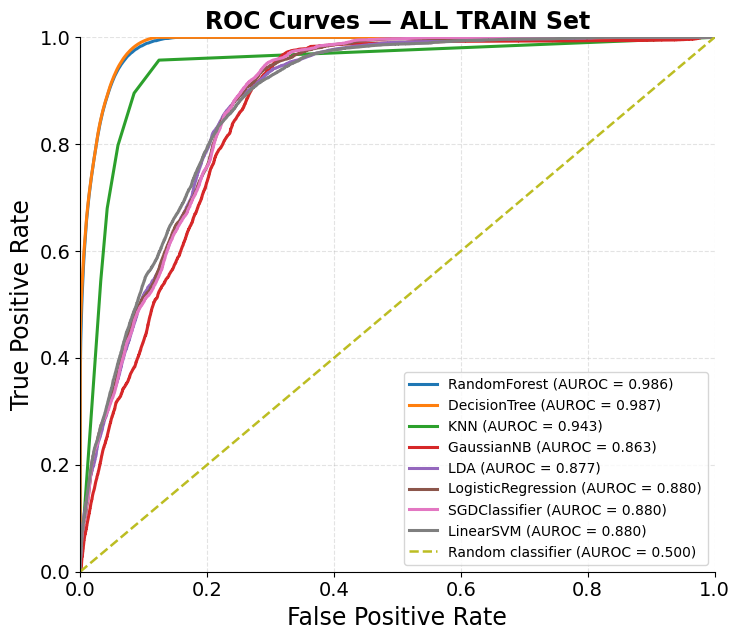

Saved: /kaggle/working/ROC_curves_all_train.png


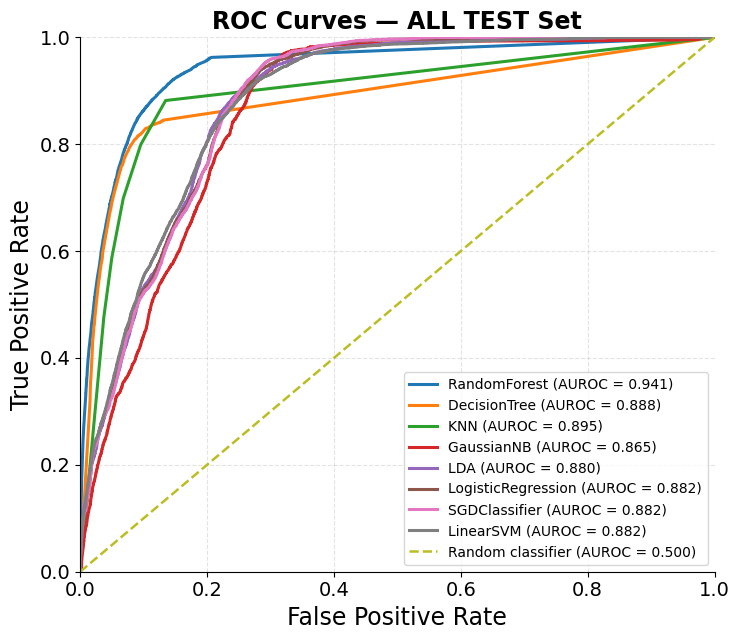

Saved: /kaggle/working/ROC_curves_all_test.png


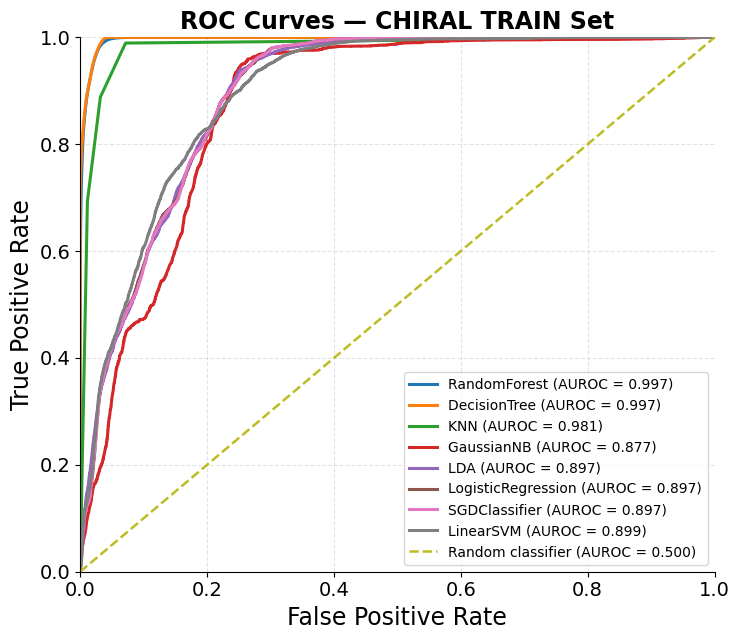

Saved: /kaggle/working/ROC_curves_chiral_train.png


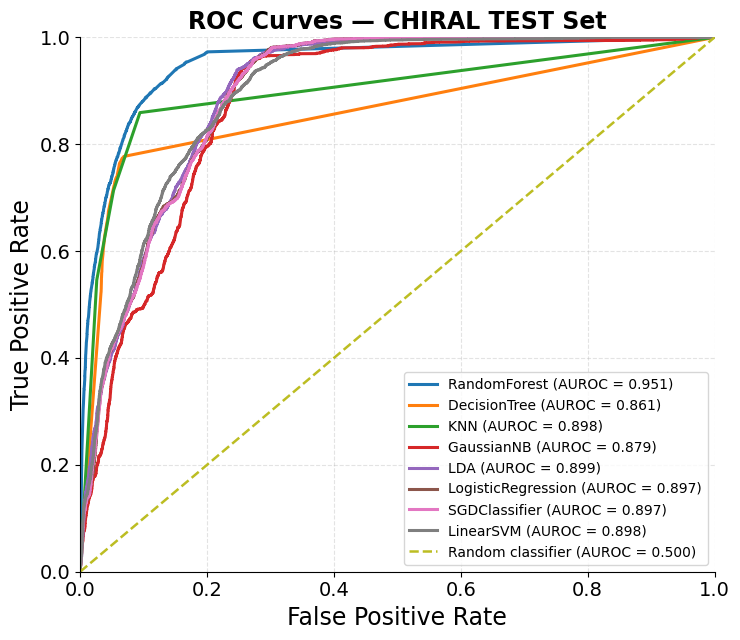

Saved: /kaggle/working/ROC_curves_chiral_test.png


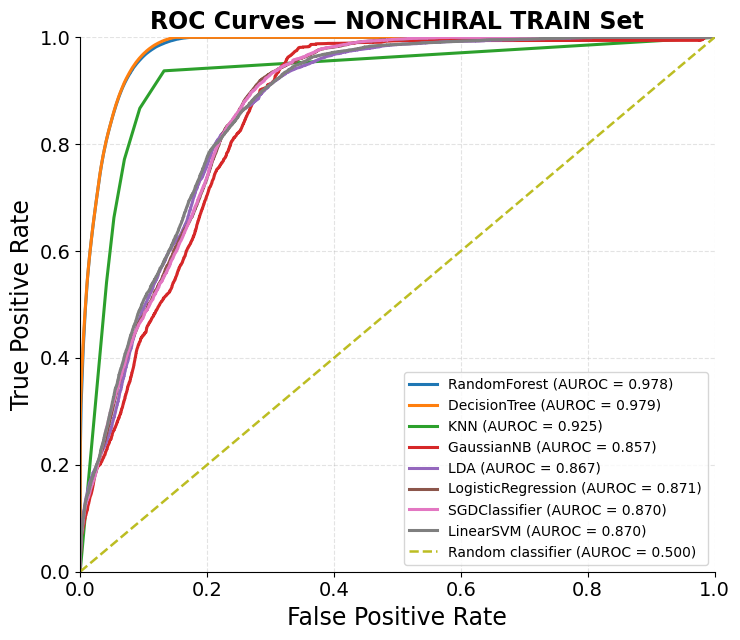

Saved: /kaggle/working/ROC_curves_nonchiral_train.png


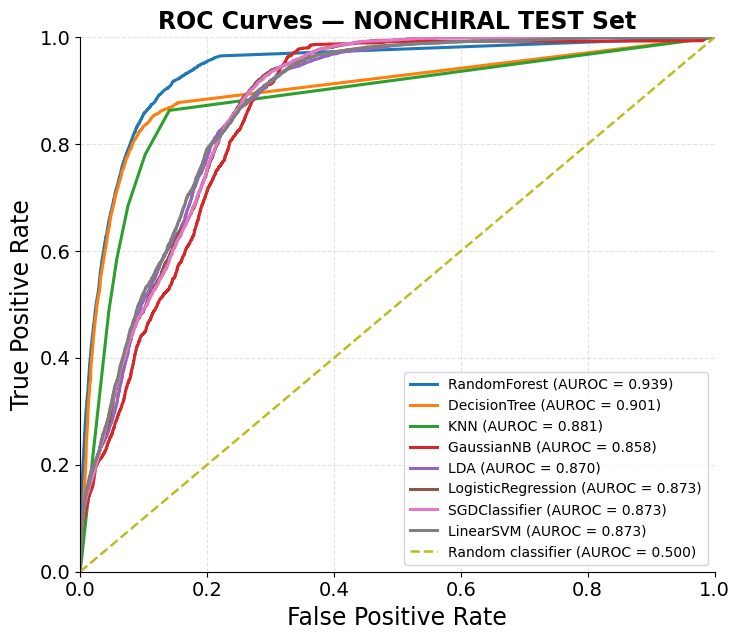

Saved: /kaggle/working/ROC_curves_nonchiral_test.png

PART 13C COMPLETED SUCCESSFULLY


In [26]:
# ============================================================
# PART 13C — ROC CURVES FOR ALL MODELS
# TRAIN AND TEST SETS
# ALL / CHIRAL / NONCHIRAL
# ============================================================

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

print("=" * 70)
print("PART 13C — ROC CURVES")
print("=" * 70)

# ------------------------------------------------------------
# Model order
# ------------------------------------------------------------

model_order = [
    "RandomForest",
    "DecisionTree",
    "KNN",
    "GaussianNB",
    "LDA",
    "LogisticRegression",
    "SGDClassifier",
    "LinearSVM"
]

# ------------------------------------------------------------
# Generate six ROC figures
# ------------------------------------------------------------

for dataset_name in ["all", "chiral", "nonchiral"]:

    X_train = prepared_data[dataset_name]["X_train"]
    y_train = prepared_data[dataset_name]["y_train"]

    X_test = prepared_data[dataset_name]["X_test"]
    y_test = prepared_data[dataset_name]["y_test"]

    for split_name in ["train", "test"]:

        if split_name == "train":
            X = X_train
            y = y_train
        else:
            X = X_test
            y = y_test

        # ----------------------------------------------------
        # Create figure
        # ----------------------------------------------------

        fig, ax = plt.subplots(
            figsize=(7.5, 6.5)
        )

        # ----------------------------------------------------
        # Plot all models
        # ----------------------------------------------------

        for model_name in model_order:

            model = best_models[
                dataset_name
            ][model_name]

            if hasattr(model, "predict_proba"):
                scores = model.predict_proba(X)[:, 1]

            elif hasattr(model, "decision_function"):
                scores = model.decision_function(X)

            else:
                continue

            fpr, tpr, _ = roc_curve(
                y,
                scores
            )

            roc_auc = auc(
                fpr,
                tpr
            )

            ax.plot(
                fpr,
                tpr,
                linewidth=2.2,
                label=(
                    f"{model_name} "
                    f"(AUROC = {roc_auc:.3f})"
                )
            )

        # ----------------------------------------------------
        # Random classifier
        # ----------------------------------------------------

        ax.plot(
            [0, 1],
            [0, 1],
            "--",
            linewidth=1.8,
            label="Random classifier (AUROC = 0.500)"
        )

        # ----------------------------------------------------
        # Axes
        # ----------------------------------------------------

        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)

        ax.set_xlabel(
            "False Positive Rate",
            fontsize=17
        )

        ax.set_ylabel(
            "True Positive Rate",
            fontsize=17
        )

        ax.set_title(
            f"ROC Curves — {dataset_name.upper()} "
            f"{split_name.upper()} Set",
            fontsize=17,
            fontweight="bold"
        )

        # ----------------------------------------------------
        # Ticks and grid
        # ----------------------------------------------------

        ax.tick_params(
            axis="both",
            labelsize=14
        )

        ax.grid(
            linestyle="--",
            linewidth=0.8,
            alpha=0.35
        )

        # ----------------------------------------------------
        # Legend
        # ----------------------------------------------------

        ax.legend(
            loc="lower right",
            fontsize=10,
            frameon=True
        )

        # ----------------------------------------------------
        # Remove top and right borders
        # ----------------------------------------------------

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        # ----------------------------------------------------
        # Save figure
        # ----------------------------------------------------

        plt.tight_layout()

        figure_path = (
            f"/kaggle/working/"
            f"ROC_curves_{dataset_name}_{split_name}.png"
        )

        plt.savefig(
            figure_path,
            dpi=600,
            bbox_inches="tight"
        )

        plt.show()

        print(
            f"Saved: {figure_path}"
        )

        plt.close()

print("\n" + "=" * 70)
print("PART 13C COMPLETED SUCCESSFULLY")
print("=" * 70)

PART 13C — ROC CURVES (LDA EXCLUDED)


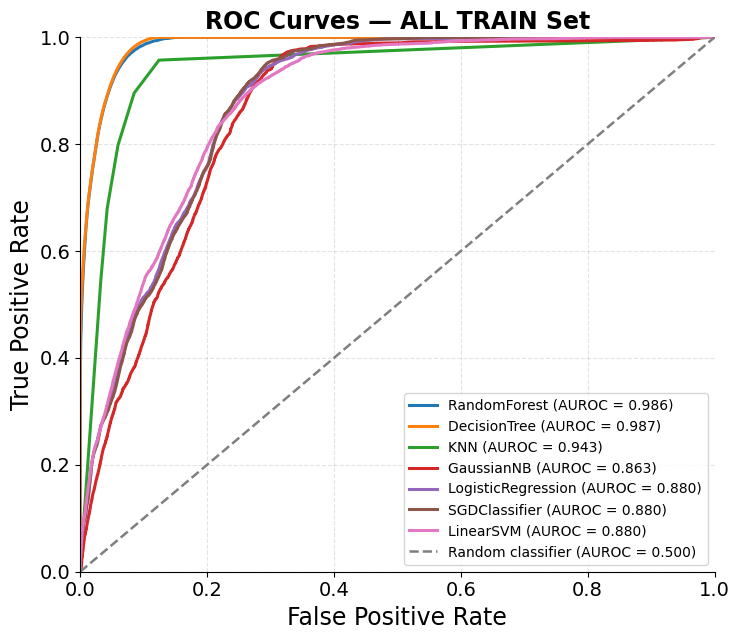

Saved: /kaggle/working/ROC_curves_all_train_noLDA.png


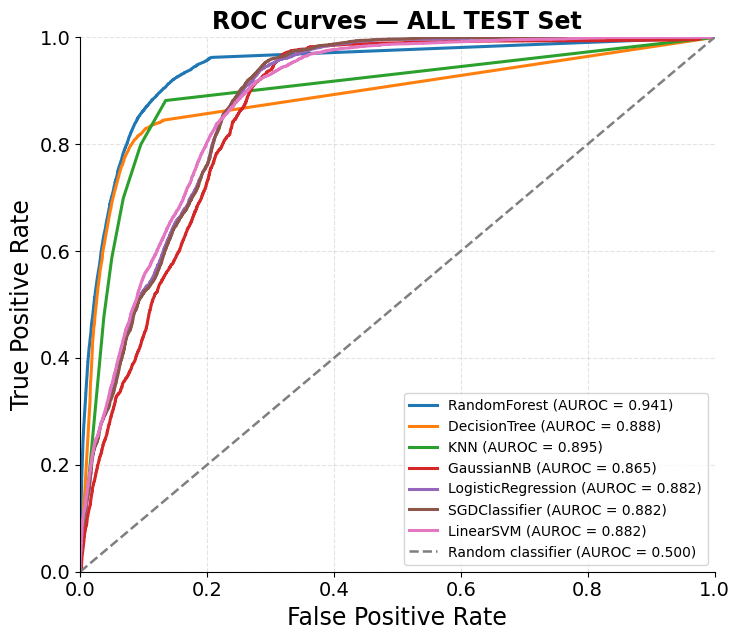

Saved: /kaggle/working/ROC_curves_all_test_noLDA.png


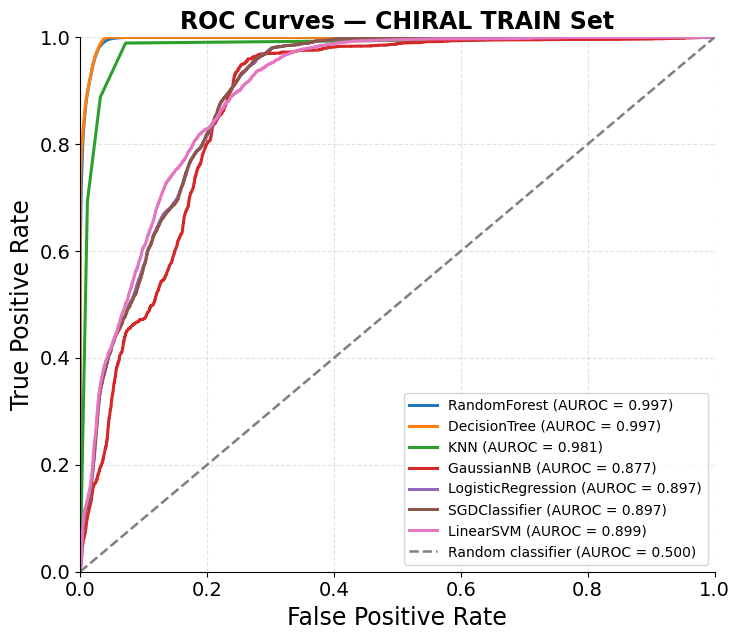

Saved: /kaggle/working/ROC_curves_chiral_train_noLDA.png


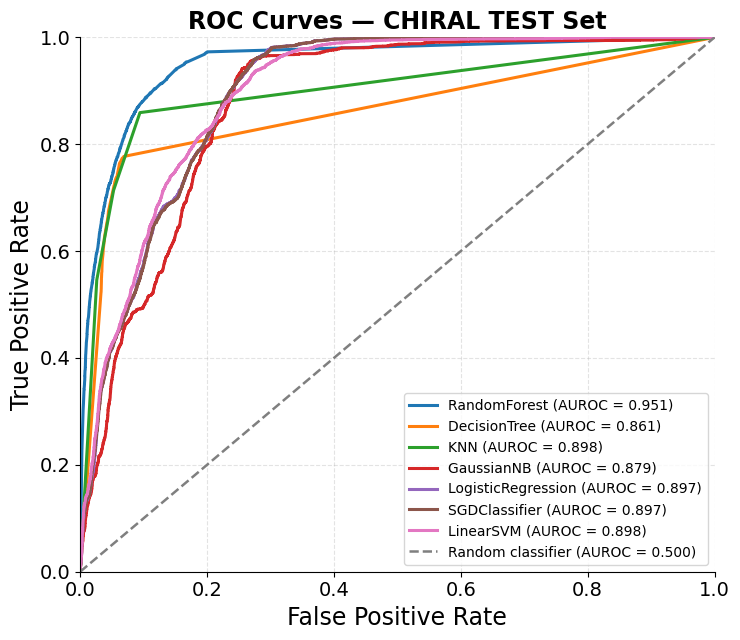

Saved: /kaggle/working/ROC_curves_chiral_test_noLDA.png


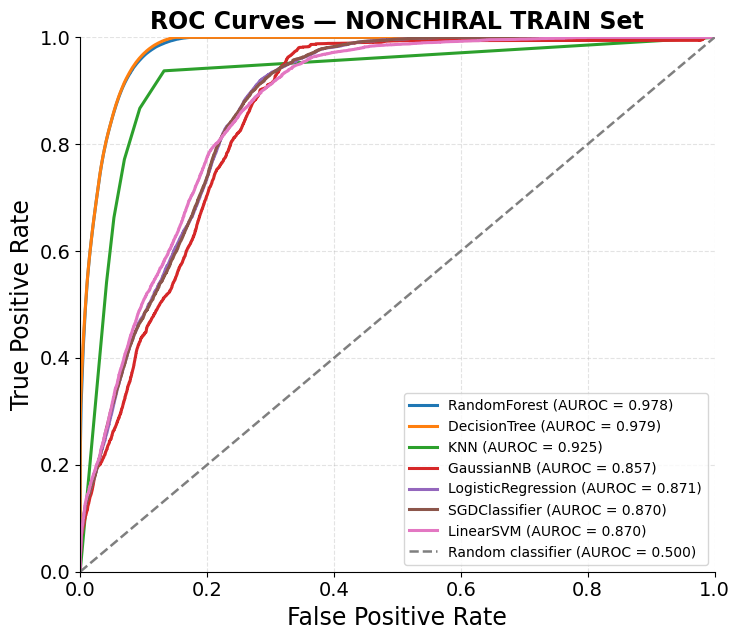

Saved: /kaggle/working/ROC_curves_nonchiral_train_noLDA.png


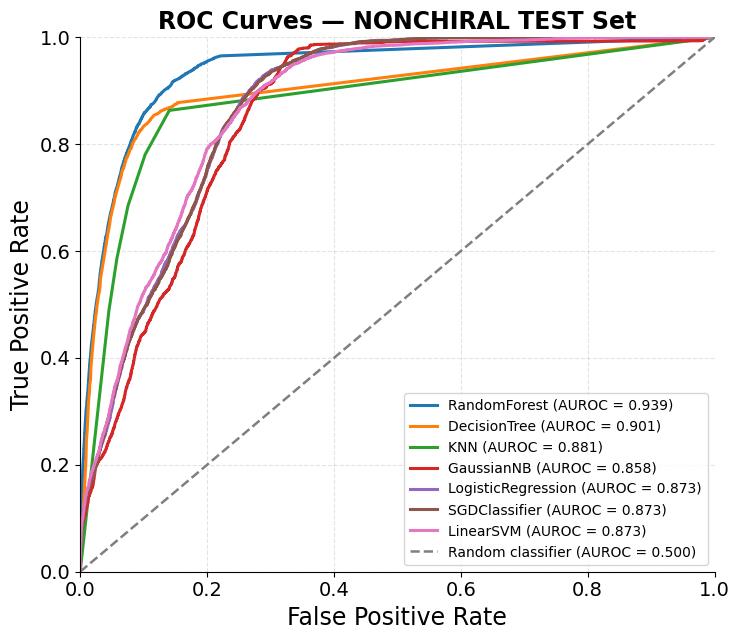

Saved: /kaggle/working/ROC_curves_nonchiral_test_noLDA.png

PART 13C COMPLETED SUCCESSFULLY
LDA was intentionally excluded from all ROC figures.


In [27]:
# ============================================================
# PART 13C — ROC CURVES FOR ALL MODELS EXCEPT LDA
# TRAIN AND TEST SETS
# ALL / CHIRAL / NONCHIRAL
# ============================================================

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

print("=" * 70)
print("PART 13C — ROC CURVES (LDA EXCLUDED)")
print("=" * 70)

# ------------------------------------------------------------
# Model order
# LDA is intentionally excluded because it has a separate
# dedicated analysis/figure in the manuscript.
# ------------------------------------------------------------

model_order = [
    "RandomForest",
    "DecisionTree",
    "KNN",
    "GaussianNB",
    "LogisticRegression",
    "SGDClassifier",
    "LinearSVM"
]

# ------------------------------------------------------------
# Generate six ROC figures
# ------------------------------------------------------------

for dataset_name in ["all", "chiral", "nonchiral"]:

    X_train = prepared_data[dataset_name]["X_train"]
    y_train = prepared_data[dataset_name]["y_train"]

    X_test = prepared_data[dataset_name]["X_test"]
    y_test = prepared_data[dataset_name]["y_test"]

    for split_name in ["train", "test"]:

        if split_name == "train":
            X = X_train
            y = y_train
        else:
            X = X_test
            y = y_test

        # ----------------------------------------------------
        # Create figure
        # ----------------------------------------------------

        fig, ax = plt.subplots(
            figsize=(7.5, 6.5)
        )

        # ----------------------------------------------------
        # Plot all models except LDA
        # ----------------------------------------------------

        for model_name in model_order:

            model = best_models[
                dataset_name
            ][model_name]

            if hasattr(model, "predict_proba"):
                scores = model.predict_proba(X)[:, 1]

            elif hasattr(model, "decision_function"):
                scores = model.decision_function(X)

            else:
                continue

            fpr, tpr, _ = roc_curve(
                y,
                scores
            )

            roc_auc = auc(
                fpr,
                tpr
            )

            ax.plot(
                fpr,
                tpr,
                linewidth=2.2,
                label=(
                    f"{model_name} "
                    f"(AUROC = {roc_auc:.3f})"
                )
            )

        # ----------------------------------------------------
        # Random classifier
        # ----------------------------------------------------

        ax.plot(
            [0, 1],
            [0, 1],
            "--",
            linewidth=1.8,
            label="Random classifier (AUROC = 0.500)"
        )

        # ----------------------------------------------------
        # Axes
        # ----------------------------------------------------

        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)

        ax.set_xlabel(
            "False Positive Rate",
            fontsize=17
        )

        ax.set_ylabel(
            "True Positive Rate",
            fontsize=17
        )

        ax.set_title(
            f"ROC Curves — {dataset_name.upper()} "
            f"{split_name.upper()} Set",
            fontsize=17,
            fontweight="bold"
        )

        # ----------------------------------------------------
        # Ticks and grid
        # ----------------------------------------------------

        ax.tick_params(
            axis="both",
            labelsize=14
        )

        ax.grid(
            linestyle="--",
            linewidth=0.8,
            alpha=0.35
        )

        # ----------------------------------------------------
        # Legend
        # ----------------------------------------------------

        ax.legend(
            loc="lower right",
            fontsize=10,
            frameon=True
        )

        # ----------------------------------------------------
        # Remove top and right borders
        # ----------------------------------------------------

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        # ----------------------------------------------------
        # Save figure
        # ----------------------------------------------------

        plt.tight_layout()

        figure_path = (
            f"/kaggle/working/"
            f"ROC_curves_{dataset_name}_{split_name}_noLDA.png"
        )

        plt.savefig(
            figure_path,
            dpi=600,
            bbox_inches="tight"
        )

        plt.show()

        print(
            f"Saved: {figure_path}"
        )

        plt.close()

print("\n" + "=" * 70)
print("PART 13C COMPLETED SUCCESSFULLY")
print("LDA was intentionally excluded from all ROC figures.")
print("=" * 70)

In [28]:
# ============================================================
# PART 14 — RANDOM FOREST FEATURE IMPORTANCE
# ============================================================

print("=" * 70)
print("PART 14 — RANDOM FOREST FEATURE IMPORTANCE")
print("=" * 70)

feature_columns = [
    "V1", "V2", "V3", "V4", "V5",
    "V6", "V7", "V8", "V9", "V10",
    "V11", "V12", "V13", "V14", "V15"
]

rf_importance_results = {}
rf_importance_tables = {}

for dataset_name in ["all", "chiral", "nonchiral"]:

    print("\n" + "=" * 70)
    print(f"RANDOM FOREST FEATURE IMPORTANCE — {dataset_name.upper()}")
    print("=" * 70)

    # Retrieve the final Random Forest pipeline
    rf_model = best_models[dataset_name]["RandomForest"]

    # Extract the Random Forest estimator from the pipeline
    rf_estimator = rf_model.named_steps["model"]

    # Verify that the estimator contains feature importances
    if not hasattr(rf_estimator, "feature_importances_"):
        raise AttributeError(
            f"Random Forest model for {dataset_name} does not "
            "contain feature_importances_."
        )

    importances = rf_estimator.feature_importances_

    if len(importances) != len(feature_columns):
        raise ValueError(
            f"Unexpected number of feature importances for {dataset_name}: "
            f"{len(importances)}"
        )

    importance_df = pd.DataFrame({
        "feature": feature_columns,
        "importance": importances
    })

    importance_df = (
        importance_df
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )

    importance_df["rank"] = np.arange(1, len(importance_df) + 1)

    # Reorder columns
    importance_df = importance_df[
        ["rank", "feature", "importance"]
    ]

    rf_importance_results[dataset_name] = importance_df
    rf_importance_tables[dataset_name] = importance_df.copy()

    display(importance_df)

    print(
        f"\nImportance sum: "
        f"{importance_df['importance'].sum():.6f}"
    )

# ------------------------------------------------------------
# Combined table
# ------------------------------------------------------------

combined_importance = pd.concat(
    [
        df.assign(dataset=dataset_name)
        for dataset_name, df in rf_importance_results.items()
    ],
    ignore_index=True
)

combined_importance = combined_importance[
    ["dataset", "rank", "feature", "importance"]
]

# ------------------------------------------------------------
# Export results
# ------------------------------------------------------------

importance_path = "/kaggle/working/random_forest_feature_importance.csv"

combined_importance.to_csv(
    importance_path,
    index=False
)

print("\n" + "=" * 70)
print("RANDOM FOREST FEATURE IMPORTANCE — COMBINED")
print("=" * 70)

display(combined_importance)

print("\nFeature importance results saved to:")
print(importance_path)

print("\n" + "=" * 70)
print("PART 14 COMPLETED SUCCESSFULLY")
print("=" * 70)

PART 14 — RANDOM FOREST FEATURE IMPORTANCE

RANDOM FOREST FEATURE IMPORTANCE — ALL


,rank,feature,importance
0,1,V1,0.272246
1,2,V2,0.188180
2,3,V6,0.095959
3,4,V4,0.080588
4,5,V5,0.070338
5,6,V7,0.053485
6,7,V8,0.037045
7,8,V13,0.034060
8,9,V9,0.032524
9,10,V11,0.029963



Importance sum: 1.000000

RANDOM FOREST FEATURE IMPORTANCE — CHIRAL


,rank,feature,importance
0,1,V1,0.224406
1,2,V2,0.216123
2,3,V6,0.085347
3,4,V8,0.054937
4,5,V13,0.051285
5,6,V9,0.048194
6,7,V10,0.046443
7,8,V11,0.046142
8,9,V14,0.042673
9,10,V7,0.042123



Importance sum: 1.000000

RANDOM FOREST FEATURE IMPORTANCE — NONCHIRAL


,rank,feature,importance
0,1,V1,0.300865
1,2,V2,0.195401
2,3,V4,0.118725
3,4,V5,0.111733
4,5,V6,0.099458
5,6,V7,0.066774
6,7,V13,0.021426
7,8,V8,0.018081
8,9,V11,0.016776
9,10,V10,0.015270



Importance sum: 1.000000

RANDOM FOREST FEATURE IMPORTANCE — COMBINED


,dataset,rank,feature,importance
0,all,1,V1,0.272246
1,all,2,V2,0.188180
2,all,3,V6,0.095959
3,all,4,V4,0.080588
4,all,5,V5,0.070338
5,all,6,V7,0.053485
6,all,7,V8,0.037045
7,all,8,V13,0.034060
8,all,9,V9,0.032524
9,all,10,V11,0.029963



Feature importance results saved to:
/kaggle/working/random_forest_feature_importance.csv

PART 14 COMPLETED SUCCESSFULLY


PART 14B — RANDOM FOREST FEATURE IMPORTANCE FIGURES
Common X-axis scale across datasets

Common X-axis maximum: 0.346


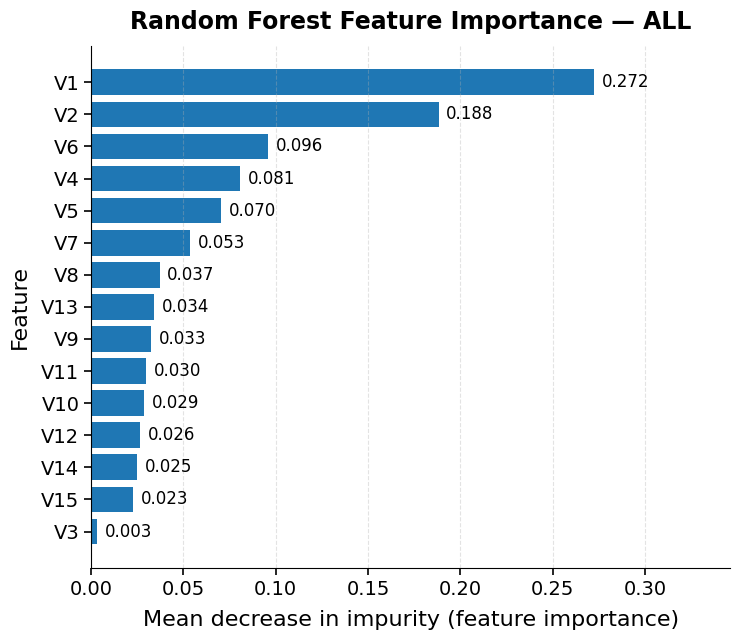


Figure saved to:
/kaggle/working/RF_feature_importance_all.png


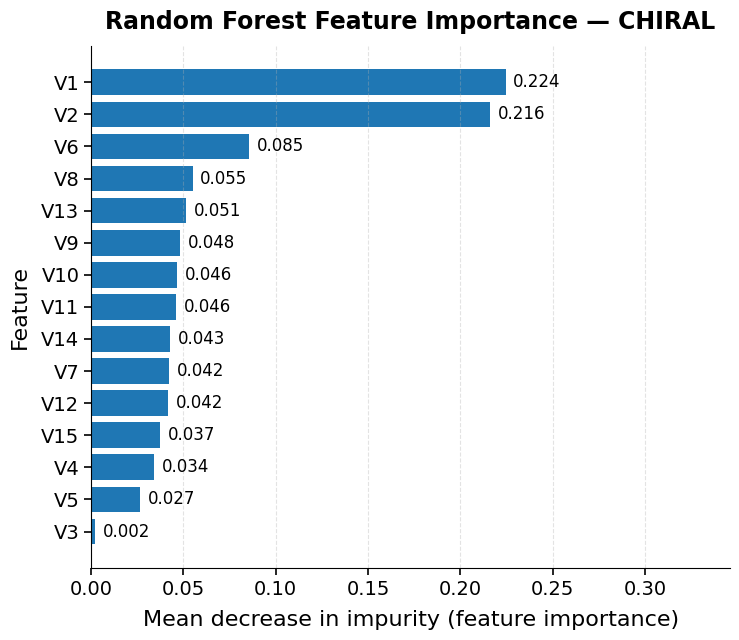


Figure saved to:
/kaggle/working/RF_feature_importance_chiral.png


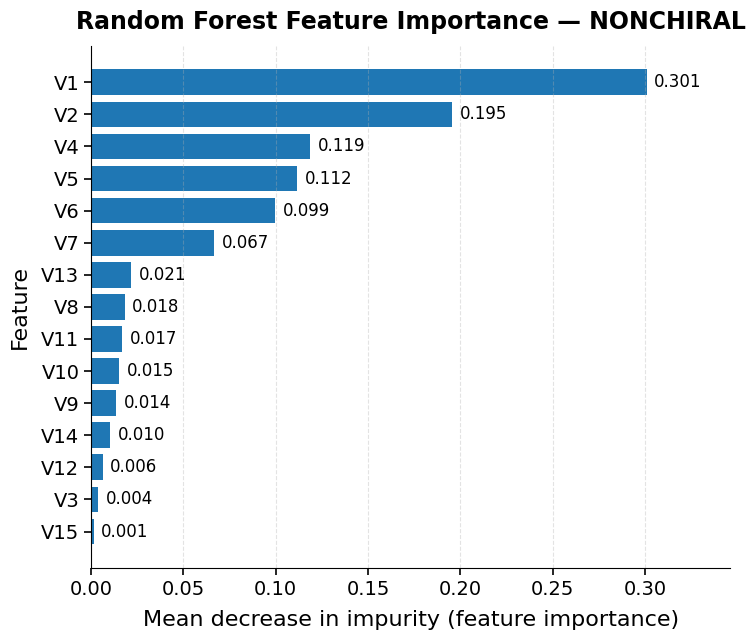


Figure saved to:
/kaggle/working/RF_feature_importance_nonchiral.png

PART 14B COMPLETED SUCCESSFULLY


In [29]:
# ============================================================
# PART 14B — RANDOM FOREST FEATURE IMPORTANCE FIGURES
# COMMON X-AXIS SCALE
# Publication-ready formatting for two-panel manuscript layout
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

print("=" * 70)
print("PART 14B — RANDOM FOREST FEATURE IMPORTANCE FIGURES")
print("Common X-axis scale across datasets")
print("=" * 70)

# ------------------------------------------------------------
# 1. Determine a common X-axis limit
# ------------------------------------------------------------

global_max_importance = max(
    rf_importance_results[dataset_name]["importance"].max()
    for dataset_name in ["all", "chiral", "nonchiral"]
)

# Add 15% margin for the numerical labels
common_xmax = global_max_importance * 1.15

print(f"\nCommon X-axis maximum: {common_xmax:.3f}")

# ------------------------------------------------------------
# 2. Generate the three figures
# ------------------------------------------------------------

for dataset_name in ["all", "chiral", "nonchiral"]:

    importance_df = rf_importance_results[dataset_name].copy()

    # Reverse order so the most important feature appears at the top
    plot_df = importance_df.sort_values(
        "importance",
        ascending=True
    )

    # --------------------------------------------------------
    # Figure size optimized for two-panel manuscript layout
    # --------------------------------------------------------

    fig, ax = plt.subplots(
        figsize=(7.5, 6.5)
    )

    bars = ax.barh(
        plot_df["feature"],
        plot_df["importance"]
    )

    # --------------------------------------------------------
    # Add numerical values at the end of each bar
    # --------------------------------------------------------

    for bar, value in zip(
        bars,
        plot_df["importance"]
    ):

        ax.text(
            value + common_xmax * 0.012,
            bar.get_y() + bar.get_height() / 2,
            f"{value:.3f}",
            va="center",
            fontsize=12
        )

    # --------------------------------------------------------
    # Common X-axis for all datasets
    # --------------------------------------------------------

    ax.set_xlim(
        0,
        common_xmax
    )

    # --------------------------------------------------------
    # Axis labels
    # --------------------------------------------------------

    ax.set_xlabel(
        "Mean decrease in impurity (feature importance)",
        fontsize=16,
        labelpad=8
    )

    ax.set_ylabel(
        "Feature",
        fontsize=16,
        labelpad=8
    )

    # --------------------------------------------------------
    # Title
    # --------------------------------------------------------

    ax.set_title(
        f"Random Forest Feature Importance — {dataset_name.upper()}",
        fontsize=17,
        fontweight="bold",
        pad=12
    )

    # --------------------------------------------------------
    # Tick labels
    # --------------------------------------------------------

    ax.tick_params(
        axis="both",
        labelsize=14,
        width=1.2,
        length=5
    )

    # --------------------------------------------------------
    # Grid
    # --------------------------------------------------------

    ax.grid(
        axis="x",
        linestyle="--",
        linewidth=0.8,
        alpha=0.35
    )

    # --------------------------------------------------------
    # Remove unnecessary spines
    # --------------------------------------------------------

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # --------------------------------------------------------
    # Layout
    # --------------------------------------------------------

    plt.tight_layout()

    # --------------------------------------------------------
    # Save high-resolution figure
    # --------------------------------------------------------

    figure_path = (
        f"/kaggle/working/"
        f"RF_feature_importance_{dataset_name}.png"
    )

    plt.savefig(
        figure_path,
        dpi=600,
        bbox_inches="tight"
    )

    plt.show()

    print(f"\nFigure saved to:")
    print(figure_path)

print("\n" + "=" * 70)
print("PART 14B COMPLETED SUCCESSFULLY")
print("=" * 70)

In [30]:
# ============================================================
# PART 15A — RDKit AVAILABILITY CHECK
# ============================================================

import sys
import subprocess

print("=" * 70)
print("PART 15A — RDKit AVAILABILITY CHECK")
print("=" * 70)

# ------------------------------------------------------------
# Check Python environment
# ------------------------------------------------------------

print("\nPython executable:")
print(sys.executable)

print("\nPython version:")
print(sys.version)

# ------------------------------------------------------------
# Check whether RDKit can be imported
# ------------------------------------------------------------

try:
    import rdkit

    print("\nRDKit is already available.")
    print("RDKit version:", rdkit.__version__)

except ImportError:
    print("\nRDKit is NOT currently available.")

# ------------------------------------------------------------
# Check installed package information
# ------------------------------------------------------------

result = subprocess.run(
    [sys.executable, "-m", "pip", "show", "rdkit"],
    capture_output=True,
    text=True
)

print("\nPip information:")
print(result.stdout if result.stdout else "RDKit package not found.")

print("\n" + "=" * 70)
print("PART 15A COMPLETED")
print("=" * 70)

PART 15A — RDKit AVAILABILITY CHECK

Python executable:
/usr/bin/python3

Python version:
3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]

RDKit is NOT currently available.

Pip information:
RDKit package not found.

PART 15A COMPLETED


In [31]:
# ============================================================
# PART 15B — INSTALL RDKit
# ============================================================

import sys
import subprocess

print("=" * 70)
print("PART 15B — INSTALLING RDKit")
print("=" * 70)

result = subprocess.run(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "rdkit"
    ],
    capture_output=True,
    text=True
)

if result.returncode == 0:
    print("\nRDKit installation completed successfully.")
else:
    print("\nRDKit installation failed.")
    print(result.stderr)

print("\n" + "=" * 70)
print("PART 15B COMPLETED")
print("=" * 70)

PART 15B — INSTALLING RDKit

RDKit installation completed successfully.

PART 15B COMPLETED


In [32]:
# ============================================================
# PART 15C — STRUCTURAL IDENTIFICATION OF ENANTIOMERIC PAIRS
# ============================================================

from rdkit import Chem
import pandas as pd
import numpy as np

print("=" * 70)
print("PART 15C — STRUCTURAL IDENTIFICATION OF ENANTIOMERIC PAIRS")
print("=" * 70)

# ------------------------------------------------------------
# Extract unique SMILES
# ------------------------------------------------------------

smiles_df = (
    df_ml[
        [
            "CANONICAL_SMILES",
            "Chiral Drug",
            "CHEMBLID mi",
            "compound_group",
            "dataset_split"
        ]
    ]
    .drop_duplicates(subset=["CANONICAL_SMILES"])
    .copy()
)

smiles_df["CANONICAL_SMILES"] = (
    smiles_df["CANONICAL_SMILES"]
    .astype(str)
)

print("\nUnique SMILES:")
print(len(smiles_df))

# ------------------------------------------------------------
# Parse molecules with RDKit
# ------------------------------------------------------------

smiles_df["mol"] = smiles_df["CANONICAL_SMILES"].apply(
    Chem.MolFromSmiles
)

valid_molecules = smiles_df["mol"].notna()

print("\nValid RDKit molecules:")
print(valid_molecules.sum())

print("Invalid SMILES:")
print((~valid_molecules).sum())

smiles_df = smiles_df.loc[
    valid_molecules
].copy()

# ------------------------------------------------------------
# Generate stereo-independent molecular representation
# ------------------------------------------------------------

def get_nonstereo_smiles(mol):
    """
    Generate canonical SMILES after removing stereochemical
    information.
    """
    mol_copy = Chem.Mol(mol)

    Chem.RemoveStereochemistry(mol_copy)

    return Chem.MolToSmiles(
        mol_copy,
        canonical=True
    )

smiles_df["nonstereo_smiles"] = smiles_df["mol"].apply(
    get_nonstereo_smiles
)

# ------------------------------------------------------------
# Count stereogenic centers
# ------------------------------------------------------------

def count_stereocenters(mol):
    """
    Count assigned or unassigned tetrahedral stereocenters.
    """
    centers = Chem.FindMolChiralCenters(
        mol,
        includeUnassigned=True
    )

    return len(centers)

smiles_df["n_stereocenters"] = smiles_df["mol"].apply(
    count_stereocenters
)

# ------------------------------------------------------------
# Identify non-stereo groups containing multiple
# stereochemical forms
# ------------------------------------------------------------

group_counts = (
    smiles_df
    .groupby("nonstereo_smiles")["CANONICAL_SMILES"]
    .nunique()
)

candidate_groups = group_counts[
    group_counts > 1
]

print("\nNon-stereochemical structures with multiple")
print("stereochemical representations:")
print(len(candidate_groups))

# ------------------------------------------------------------
# Build candidate enantiomeric groups
# ------------------------------------------------------------

candidate_df = smiles_df[
    smiles_df["nonstereo_smiles"].isin(
        candidate_groups.index
    )
].copy()

print("\nCandidate stereochemical molecules:")
print(len(candidate_df))

# ------------------------------------------------------------
# Display summary of candidate groups
# ------------------------------------------------------------

candidate_summary = (
    candidate_df
    .groupby("nonstereo_smiles")
    .agg(
        n_stereochemical_forms=(
            "CANONICAL_SMILES",
            "nunique"
        ),
        n_stereocenters=(
            "n_stereocenters",
            "max"
        )
    )
    .reset_index()
)

candidate_summary = candidate_summary.sort_values(
    [
        "n_stereochemical_forms",
        "n_stereocenters"
    ],
    ascending=False
)

print("\nCandidate group summary:")
display(
    candidate_summary.head(20)
)

# ------------------------------------------------------------
# Basic statistics
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("STRUCTURAL SUMMARY")
print("=" * 70)

print(
    f"Unique SMILES analysed: "
    f"{len(smiles_df):,}"
)

print(
    f"Candidate non-stereo groups with multiple "
    f"stereochemical forms: "
    f"{len(candidate_groups):,}"
)

print(
    f"Candidate stereochemical molecules: "
    f"{len(candidate_df):,}"
)

print(
    f"Candidate groups containing stereocenters: "
    f"{(candidate_summary['n_stereocenters'] > 0).sum():,}"
)

print("\n" + "=" * 70)
print("PART 15C COMPLETED")
print("=" * 70)

PART 15C — STRUCTURAL IDENTIFICATION OF ENANTIOMERIC PAIRS

Unique SMILES:
65535


[10:00:51] Conflicting single bond directions around double bond at index 5.
[10:00:51]   BondStereo set to STEREONONE and single bond directions set to NONE.
[10:00:53] SMILES Parse Error: syntax error while parsing: NOTSMILE
[10:00:53] SMILES Parse Error: check for mistakes around position 3:
[10:00:53] NOTSMILE
[10:00:53] ~~^
[10:00:53] SMILES Parse Error: Failed parsing SMILES 'NOTSMILE' for input: 'NOTSMILE'



Valid RDKit molecules:
65534
Invalid SMILES:
1

Non-stereochemical structures with multiple
stereochemical representations:
2495

Candidate stereochemical molecules:
5604

Candidate group summary:


,nonstereo_smiles,n_stereochemical_forms,n_stereocenters
1266,COC(=O)C1C(OC(=O)c2ccccc2)CC2CCC1N2C,10,4
1704,CSCCC1NC(=O)C(NC(C)=O)CSSCC(C(N)=O)NC(=O)CNC(=O)C(CCCNC(=N)N)NC(=O)C(CC(C)C)NC(=O)C(CCCNC(=N)N)NC(=O)C2CCCN2C1=O,9,7
1242,COC(=O)C(NC(=O)C(CC(C)C)NC(=O)N(Cc1ccccc1)CC(O)C(Cc1ccccc1)NC(=O)OC(C)(C)C)C(C)C,9,4
1276,COC(=O)C1C(c2ccc(C)cc2)CC2C(O)CC1N2C,8,5
73,C=CCN1CCC2c3c(cccc3OC)CCC21,7,2
74,C=CCN1CCC2c3cccc(O)c3CCC21,7,2
1062,CN1C2CCC1C(COc1ccc3c(c1)OCO3)C(c1ccc(F)cc1)C2,6,4
1064,CN1C2CCC1C(c1ccccc1)C(c1ccccc1)C2,6,4
1306,COC(=O)C1C2CCC(CC1OC(=O)c1ccccc1)N2,6,4
1869,Clc1ccc(C2CC3CCC2N3)cn1,6,3



STRUCTURAL SUMMARY
Unique SMILES analysed: 65,534
Candidate non-stereo groups with multiple stereochemical forms: 2,495
Candidate stereochemical molecules: 5,604
Candidate groups containing stereocenters: 2,262

PART 15C COMPLETED


In [33]:
# ============================================================
# PART 15D — IDENTIFICATION OF TRUE ENANTIOMERIC PAIRS
# ============================================================

from rdkit import Chem
import pandas as pd
import numpy as np

print("=" * 70)
print("PART 15D — IDENTIFICATION OF TRUE ENANTIOMERIC PAIRS")
print("=" * 70)

# ------------------------------------------------------------
# Create a lookup table for valid stereochemical SMILES
# ------------------------------------------------------------

stereo_lookup = {}

for _, row in smiles_df.iterrows():
    smiles = row["CANONICAL_SMILES"]
    mol = row["mol"]

    stereo_smiles = Chem.MolToSmiles(
        mol,
        canonical=True,
        isomericSmiles=True
    )

    stereo_lookup[stereo_smiles] = {
        "CANONICAL_SMILES": smiles,
        "compound_group": row["compound_group"],
        "dataset_split": row["dataset_split"],
        "Chiral Drug": row["Chiral Drug"],
        "CHEMBLID mi": row["CHEMBLID mi"],
        "nonstereo_smiles": row["nonstereo_smiles"],
        "n_stereocenters": row["n_stereocenters"]
    }

print(f"\nUnique stereochemical representations: {len(stereo_lookup):,}")

# ------------------------------------------------------------
# Function to generate the complete stereochemical inverse
# ------------------------------------------------------------

def generate_enantiomer_smiles(mol):
    """
    Invert all tetrahedral stereocenters and return the
    canonical isomeric SMILES of the resulting molecule.
    """

    mol_copy = Chem.Mol(mol)

    Chem.AssignStereochemistry(
        mol_copy,
        cleanIt=True,
        force=True
    )

    inverted_atoms = 0

    for atom in mol_copy.GetAtoms():

        if atom.GetChiralTag() == Chem.ChiralType.CHI_TETRAHEDRAL_CW:
            atom.SetChiralTag(
                Chem.ChiralType.CHI_TETRAHEDRAL_CCW
            )
            inverted_atoms += 1

        elif atom.GetChiralTag() == Chem.ChiralType.CHI_TETRAHEDRAL_CCW:
            atom.SetChiralTag(
                Chem.ChiralType.CHI_TETRAHEDRAL_CW
            )
            inverted_atoms += 1

    if inverted_atoms == 0:
        return None

    Chem.AssignStereochemistry(
        mol_copy,
        cleanIt=True,
        force=True
    )

    return Chem.MolToSmiles(
        mol_copy,
        canonical=True,
        isomericSmiles=True
    )


# ------------------------------------------------------------
# Identify true enantiomeric partners
# ------------------------------------------------------------

enantiomer_pairs = []

processed_pairs = set()

for _, row in smiles_df.iterrows():

    mol = row["mol"]

    if row["n_stereocenters"] == 0:
        continue

    enantiomer_smiles = generate_enantiomer_smiles(mol)

    if enantiomer_smiles is None:
        continue

    if enantiomer_smiles not in stereo_lookup:
        continue

    partner = stereo_lookup[enantiomer_smiles]

    current_smiles = Chem.MolToSmiles(
        mol,
        canonical=True,
        isomericSmiles=True
    )

    # Avoid counting A-B and B-A separately
    pair_key = tuple(
        sorted(
            [
                current_smiles,
                enantiomer_smiles
            ]
        )
    )

    if pair_key in processed_pairs:
        continue

    processed_pairs.add(pair_key)

    enantiomer_pairs.append(
        {
            "smiles_1": row["CANONICAL_SMILES"],
            "smiles_2": partner["CANONICAL_SMILES"],
            "compound_1": row["compound_group"],
            "compound_2": partner["compound_group"],
            "split_1": row["dataset_split"],
            "split_2": partner["dataset_split"],
            "chiral_1": row["Chiral Drug"],
            "chiral_2": partner["Chiral Drug"],
            "chembl_1": row["CHEMBLID mi"],
            "chembl_2": partner["CHEMBLID mi"],
            "nonstereo_smiles": row["nonstereo_smiles"],
            "n_stereocenters": row["n_stereocenters"]
        }
    )

enantiomer_pairs_df = pd.DataFrame(enantiomer_pairs)

# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("TRUE ENANTIOMER SUMMARY")
print("=" * 70)

print(
    f"\nTrue enantiomeric pairs identified: "
    f"{len(enantiomer_pairs_df):,}"
)

if len(enantiomer_pairs_df) > 0:

    cross_split = (
        enantiomer_pairs_df["split_1"]
        != enantiomer_pairs_df["split_2"]
    )

    train_train = (
        (enantiomer_pairs_df["split_1"] == "train") &
        (enantiomer_pairs_df["split_2"] == "train")
    )

    test_test = (
        (enantiomer_pairs_df["split_1"] == "test") &
        (enantiomer_pairs_df["split_2"] == "test")
    )

    train_test = (
        enantiomer_pairs_df["split_1"]
        .eq("train") &
        enantiomer_pairs_df["split_2"]
        .eq("test")
    )

    test_train = (
        enantiomer_pairs_df["split_1"]
        .eq("test") &
        enantiomer_pairs_df["split_2"]
        .eq("train")
    )

    print(
        f"Pairs within training set: "
        f"{train_train.sum():,}"
    )

    print(
        f"Pairs within test set: "
        f"{test_test.sum():,}"
    )

    print(
        f"Pairs crossing train/test split: "
        f"{cross_split.sum():,}"
    )

    print("\nCross-split enantiomeric pairs:")

    cross_split_df = enantiomer_pairs_df.loc[
        cross_split
    ].copy()

    display(
        cross_split_df.head(20)
    )

else:
    print("\nNo true enantiomeric pairs were identified.")

print("\n" + "=" * 70)
print("PART 15D COMPLETED")
print("=" * 70)

PART 15D — IDENTIFICATION OF TRUE ENANTIOMERIC PAIRS

Unique stereochemical representations: 65,534

TRUE ENANTIOMER SUMMARY

True enantiomeric pairs identified: 1,411
Pairs within training set: 981
Pairs within test set: 130
Pairs crossing train/test split: 300

Cross-split enantiomeric pairs:


,smiles_1,smiles_2,compound_1,compound_2,split_1,split_2,chiral_1,chiral_2,chembl_1,chembl_2,nonstereo_smiles,n_stereocenters
20,COc1cncc(c1)N2C[C@@H]3CNC[C@H]23,COc1cncc(c1)N2C[C@H]3CNC[C@@H]23,CHEMBL396901,CHEMBL239932,test,train,1,1,CHEMBL396901,CHEMBL239932,COc1cncc(N2CC3CNCC32)c1,2
22,COc1cncc(c1)N2C[C@@H]3CCNC[C@H]23,COc1cncc(c1)N2C[C@H]3CCNC[C@@H]23,CHEMBL220351,CHEMBL443370,test,train,1,1,CHEMBL220351,CHEMBL443370,COc1cncc(N2CC3CCNCC32)c1,2
24,Brc1cncc(c1)N2C[C@@H]3CN[C@@H]3C2,Brc1cncc(c1)N2C[C@H]3CN[C@H]3C2,CHEMBL238665,CHEMBL395456,train,test,1,1,CHEMBL238665,CHEMBL395456,Brc1cncc(N2CC3CNC3C2)c1,2
29,N#Cc1cncc(c1)N2C[C@@H]3CCNC[C@H]23,N#Cc1cncc(c1)N2C[C@H]3CCNC[C@@H]23,CHEMBL468064,CHEMBL426879,test,train,1,1,CHEMBL468064,CHEMBL426879,N#Cc1cncc(N2CC3CCNCC32)c1,2
34,Cc1cc(cnc1C)N2C[C@@H]3CN[C@@H]3C2,Cc1cc(cnc1C)N2C[C@H]3CN[C@H]3C2,CHEMBL238673,CHEMBL391166,train,test,1,1,CHEMBL238673,CHEMBL391166,Cc1cc(N2CC3CNC3C2)cnc1C,2
35,Cc1cc(cnc1C)N2C[C@@H]3CNC[C@H]23,Cc1cc(cnc1C)N2C[C@H]3CNC[C@@H]23,CHEMBL395934,CHEMBL239502,test,train,1,1,CHEMBL395934,CHEMBL239502,Cc1cc(N2CC3CNCC32)cnc1C,2
36,C1CN(C[C@H]2NC[C@@H]12)c3cncnc3,C1CN(C[C@@H]2NC[C@H]12)c3cncnc3,CHEMBL1162936,CHEMBL375377,test,train,1,1,CHEMBL1162936,CHEMBL375377,c1ncc(N2CCC3CNC3C2)cn1,2
38,N#Cc1cncc(c1)N2C[C@@H]3CN[C@@H]3C2,N#Cc1cncc(c1)N2C[C@H]3CN[C@H]3C2,CHEMBL238667,CHEMBL238670,test,train,1,1,CHEMBL238667,CHEMBL238670,N#Cc1cncc(N2CC3CNC3C2)c1,2
39,C1C[C@@H]2CN([C@@H]2CN1)c3cccnc3,C1C[C@H]2CN([C@H]2CN1)c3cccnc3,CHEMBL508645,CHEMBL374221,test,train,1,1,CHEMBL508645,CHEMBL374221,c1cncc(N2CC3CCNCC32)c1,2
41,Clc1cc(cnc1Cl)N2C[C@@H]3CNC[C@H]23,Clc1cc(cnc1Cl)N2C[C@H]3CNC[C@@H]23,CHEMBL239721,CHEMBL393627,test,train,1,1,CHEMBL239721,CHEMBL393627,Clc1cc(N2CC3CNCC32)cnc1Cl,2



PART 15D COMPLETED


In [34]:
# ============================================================
# PART 15E — IMPACT OF CROSS-SPLIT ENANTIOMERIC PAIRS
# ============================================================

print("=" * 70)
print("PART 15E — IMPACT OF CROSS-SPLIT ENANTIOMERIC PAIRS")
print("=" * 70)

# ------------------------------------------------------------
# Select cross-split enantiomeric pairs
# ------------------------------------------------------------

cross_split_pairs = enantiomer_pairs_df[
    enantiomer_pairs_df["split_1"] !=
    enantiomer_pairs_df["split_2"]
].copy()

print(
    f"\nCross-split enantiomeric pairs: "
    f"{len(cross_split_pairs):,}"
)

# ------------------------------------------------------------
# Identify compounds involved in cross-split pairs
# ------------------------------------------------------------

cross_split_compounds = set(
    cross_split_pairs["compound_1"]
).union(
    set(cross_split_pairs["compound_2"])
)

print(
    f"Unique compounds involved: "
    f"{len(cross_split_compounds):,}"
)

# ------------------------------------------------------------
# Identify train and test compounds separately
# ------------------------------------------------------------

train_cross_compounds = set()

test_cross_compounds = set()

for _, row in cross_split_pairs.iterrows():

    if row["split_1"] == "train":
        train_cross_compounds.add(row["compound_1"])
        test_cross_compounds.add(row["compound_2"])

    else:
        test_cross_compounds.add(row["compound_1"])
        train_cross_compounds.add(row["compound_2"])

print(
    f"Training compounds with a test-set enantiomer: "
    f"{len(train_cross_compounds):,}"
)

print(
    f"Test compounds with a training-set enantiomer: "
    f"{len(test_cross_compounds):,}"
)

# ------------------------------------------------------------
# Count test rows belonging to affected compounds
# ------------------------------------------------------------

test_affected = df_ml[
    (df_ml["dataset_split"] == "test") &
    (df_ml["compound_group"].isin(test_cross_compounds))
].copy()

train_affected = df_ml[
    (df_ml["dataset_split"] == "train") &
    (df_ml["compound_group"].isin(train_cross_compounds))
].copy()

print(
    f"\nTest rows belonging to affected compounds: "
    f"{len(test_affected):,}"
)

print(
    f"Total test rows: "
    f"{(df_ml['dataset_split'] == 'test').sum():,}"
)

test_row_percentage = (
    len(test_affected)
    /
    (df_ml["dataset_split"] == "test").sum()
    * 100
)

print(
    f"Percentage of test rows affected: "
    f"{test_row_percentage:.2f}%"
)

print(
    f"\nTraining rows belonging to affected compounds: "
    f"{len(train_affected):,}"
)

# ------------------------------------------------------------
# Count active/inactive test compounds and rows
# ------------------------------------------------------------

test_affected_compound_activity = (
    test_affected
    .groupby("compound_group")[target]
    .max()
    .value_counts()
    .sort_index()
)

print("\nAffected test compounds by activity:")
print(test_affected_compound_activity)

test_affected_activity = (
    test_affected[target]
    .value_counts()
    .sort_index()
)

print("\nAffected test rows by activity:")
print(test_affected_activity)

# ------------------------------------------------------------
# Pair-level activity consistency
# ------------------------------------------------------------

pair_activity = []

for _, row in cross_split_pairs.iterrows():

    compound_1_activity = (
        df_ml.loc[
            df_ml["compound_group"] == row["compound_1"],
            target
        ].max()
    )

    compound_2_activity = (
        df_ml.loc[
            df_ml["compound_group"] == row["compound_2"],
            target
        ].max()
    )

    pair_activity.append(
        {
            "compound_1": row["compound_1"],
            "compound_2": row["compound_2"],
            "split_1": row["split_1"],
            "split_2": row["split_2"],
            "activity_1": int(compound_1_activity),
            "activity_2": int(compound_2_activity)
        }
    )

pair_activity_df = pd.DataFrame(pair_activity)

pair_activity_df["same_activity"] = (
    pair_activity_df["activity_1"]
    ==
    pair_activity_df["activity_2"]
)

print("\n" + "=" * 70)
print("ENANTIOMER ACTIVITY CONSISTENCY")
print("=" * 70)

print(
    f"\nPairs with the same activity label: "
    f"{pair_activity_df['same_activity'].sum():,}"
)

print(
    f"Pairs with different activity labels: "
    f"{(~pair_activity_df['same_activity']).sum():,}"
)

print("\nActivity combinations:")

activity_combinations = pd.crosstab(
    pair_activity_df["activity_1"],
    pair_activity_df["activity_2"]
)

display(activity_combinations)

# ------------------------------------------------------------
# Save cross-split pair analysis
# ------------------------------------------------------------

cross_split_pairs.to_csv(
    "/kaggle/working/cross_split_enantiomeric_pairs.csv",
    index=False
)

pair_activity_df.to_csv(
    "/kaggle/working/cross_split_enantiomer_activity.csv",
    index=False
)

print("\nFiles saved:")
print(
    "/kaggle/working/cross_split_enantiomeric_pairs.csv"
)
print(
    "/kaggle/working/cross_split_enantiomer_activity.csv"
)

print("\n" + "=" * 70)
print("PART 15E COMPLETED")
print("=" * 70)

PART 15E — IMPACT OF CROSS-SPLIT ENANTIOMERIC PAIRS

Cross-split enantiomeric pairs: 300
Unique compounds involved: 600
Training compounds with a test-set enantiomer: 300
Test compounds with a training-set enantiomer: 300

Test rows belonging to affected compounds: 4,494
Total test rows: 151,860
Percentage of test rows affected: 2.96%

Training rows belonging to affected compounds: 4,050

Affected test compounds by activity:
f(vdij,vpj,vnrj)obj
0    146
1    154
Name: count, dtype: int64

Affected test rows by activity:
f(vdij,vpj,vnrj)obj
0    3792
1     702
Name: count, dtype: int64

ENANTIOMER ACTIVITY CONSISTENCY

Pairs with the same activity label: 228
Pairs with different activity labels: 72

Activity combinations:


activity_2,0,1
activity_1,,
0,112,5
1,67,116



Files saved:
/kaggle/working/cross_split_enantiomeric_pairs.csv
/kaggle/working/cross_split_enantiomer_activity.csv

PART 15E COMPLETED


In [35]:
# ============================================================
# PART 15F — SENSITIVITY ANALYSIS FOR CROSS-SPLIT ENANTIOMERS
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score,
    average_precision_score
)

print("=" * 70)
print("PART 15F — SENSITIVITY ANALYSIS FOR CROSS-SPLIT ENANTIOMERS")
print("=" * 70)

# ------------------------------------------------------------
# Identify test compounds whose enantiomer is in training
# ------------------------------------------------------------

affected_test_compounds = set(test_cross_compounds)

print(
    f"\nAffected test compounds: "
    f"{len(affected_test_compounds):,}"
)

# ------------------------------------------------------------
# Reconstruct the complete test dataset
# ------------------------------------------------------------

sensitivity_results = []

for dataset_name in ["all", "chiral", "nonchiral"]:

    test_data = prepared_data[dataset_name]["test_data"].copy()

    # Identify affected test rows
    affected_mask = test_data["compound_group"].isin(
        affected_test_compounds
    )

    test_full = test_data.copy()

    test_clean = test_data.loc[
        ~affected_mask
    ].copy()

    print("\n" + "-" * 70)
    print(f"DATASET: {dataset_name.upper()}")
    print("-" * 70)

    print(
        f"Original test rows: "
        f"{len(test_full):,}"
    )

    print(
        f"Rows excluded: "
        f"{affected_mask.sum():,}"
    )

    print(
        f"Sensitivity test rows: "
        f"{len(test_clean):,}"
    )

    # --------------------------------------------------------
    # Evaluate every final model using existing predictions
    # --------------------------------------------------------

    for model_name in model_order:

        model = best_models[dataset_name][model_name]

        X_full = test_full[feature_columns]
        y_full = test_full[target].astype(int)

        X_clean = test_clean[feature_columns]
        y_clean = test_clean[target].astype(int)

        # Full test predictions
        y_pred_full = model.predict(X_full)

        # Sensitivity-test predictions
        y_pred_clean = model.predict(X_clean)

        # Probability / decision scores
        if hasattr(model, "predict_proba"):
            y_score_full = model.predict_proba(X_full)[:, 1]
            y_score_clean = model.predict_proba(X_clean)[:, 1]

        elif hasattr(model, "decision_function"):
            y_score_full = model.decision_function(X_full)
            y_score_clean = model.decision_function(X_clean)

        else:
            y_score_full = y_pred_full
            y_score_clean = y_pred_clean

        # ----------------------------------------------------
        # Calculate metrics for both test sets
        # ----------------------------------------------------

        metric_sets = {
            "full_test": (
                y_full,
                y_pred_full,
                y_score_full
            ),
            "excluding_cross_split_enantiomers": (
                y_clean,
                y_pred_clean,
                y_score_clean
            )
        }

        for test_type, (
            y_true,
            y_pred,
            y_score
        ) in metric_sets.items():

            sensitivity_results.append(
                {
                    "dataset": dataset_name,
                    "model": model_name,
                    "test_type": test_type,
                    "n_rows": len(y_true),
                    "n_active": int(y_true.sum()),
                    "n_inactive": int((y_true == 0).sum()),
                    "Accuracy": accuracy_score(
                        y_true,
                        y_pred
                    ),
                    "Balanced Accuracy": balanced_accuracy_score(
                        y_true,
                        y_pred
                    ),
                    "Precision": precision_score(
                        y_true,
                        y_pred,
                        zero_division=0
                    ),
                    "Recall": recall_score(
                        y_true,
                        y_pred,
                        zero_division=0
                    ),
                    "F1": f1_score(
                        y_true,
                        y_pred,
                        zero_division=0
                    ),
                    "MCC": matthews_corrcoef(
                        y_true,
                        y_pred
                    ),
                    "AUROC": roc_auc_score(
                        y_true,
                        y_score
                    ),
                    "AUPRC": average_precision_score(
                        y_true,
                        y_score
                    )
                }
            )

# ------------------------------------------------------------
# Convert results to DataFrame
# ------------------------------------------------------------

sensitivity_results_df = pd.DataFrame(
    sensitivity_results
)

# ------------------------------------------------------------
# Calculate changes relative to the original test results
# ------------------------------------------------------------

full_results = sensitivity_results_df[
    sensitivity_results_df["test_type"] == "full_test"
].copy()

clean_results = sensitivity_results_df[
    sensitivity_results_df["test_type"] ==
    "excluding_cross_split_enantiomers"
].copy()

metric_columns = [
    "Accuracy",
    "Balanced Accuracy",
    "Precision",
    "Recall",
    "F1",
    "MCC",
    "AUROC",
    "AUPRC"
]

comparison_df = clean_results[
    ["dataset", "model"] + metric_columns
].merge(
    full_results[
        ["dataset", "model"] + metric_columns
    ],
    on=["dataset", "model"],
    suffixes=(
        "_sensitivity",
        "_full"
    )
)

for metric in metric_columns:

    comparison_df[
        f"{metric}_difference"
    ] = (
        comparison_df[f"{metric}_sensitivity"]
        -
        comparison_df[f"{metric}_full"]
    )

# ------------------------------------------------------------
# Display F1 and AUROC sensitivity
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("F1 SENSITIVITY")
print("=" * 70)

display(
    comparison_df[
        [
            "dataset",
            "model",
            "F1_full",
            "F1_sensitivity",
            "F1_difference"
        ]
    ]
)

print("\n" + "=" * 70)
print("AUROC SENSITIVITY")
print("=" * 70)

display(
    comparison_df[
        [
            "dataset",
            "model",
            "AUROC_full",
            "AUROC_sensitivity",
            "AUROC_difference"
        ]
    ]
)

# ------------------------------------------------------------
# Maximum absolute changes
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("MAXIMUM ABSOLUTE CHANGES")
print("=" * 70)

for metric in metric_columns:

    difference_column = f"{metric}_difference"

    max_change = comparison_df[
        difference_column
    ].abs().max()

    print(
        f"{metric}: "
        f"{max_change:.6f}"
    )

# ------------------------------------------------------------
# Export results
# ------------------------------------------------------------

sensitivity_results_df.to_csv(
    "/kaggle/working/"
    "enantiomer_sensitivity_results.csv",
    index=False
)

comparison_df.to_csv(
    "/kaggle/working/"
    "enantiomer_sensitivity_comparison.csv",
    index=False
)

print("\nFiles saved:")
print(
    "/kaggle/working/enantiomer_sensitivity_results.csv"
)
print(
    "/kaggle/working/enantiomer_sensitivity_comparison.csv"
)

print("\n" + "=" * 70)
print("PART 15F COMPLETED SUCCESSFULLY")
print("=" * 70)

PART 15F — SENSITIVITY ANALYSIS FOR CROSS-SPLIT ENANTIOMERS

Affected test compounds: 300

----------------------------------------------------------------------
DATASET: ALL
----------------------------------------------------------------------
Original test rows: 151,860
Rows excluded: 4,494
Sensitivity test rows: 147,366

----------------------------------------------------------------------
DATASET: CHIRAL
----------------------------------------------------------------------
Original test rows: 44,988
Rows excluded: 4,494
Sensitivity test rows: 40,494

----------------------------------------------------------------------
DATASET: NONCHIRAL
----------------------------------------------------------------------
Original test rows: 106,872
Rows excluded: 0
Sensitivity test rows: 106,872

F1 SENSITIVITY


,dataset,model,F1_full,F1_sensitivity,F1_difference
0,all,RandomForest,0.644240,0.644051,-0.000189
1,all,DecisionTree,0.633153,0.634112,0.000959
2,all,KNN,0.619912,0.618304,-0.001607
3,all,GaussianNB,0.420755,0.417958,-0.002797
4,all,LogisticRegression,0.307009,0.307234,0.000225
5,all,SGDClassifier,0.337567,0.336818,-0.000749
6,all,LinearSVM,0.170913,0.173753,0.002841
7,chiral,RandomForest,0.707921,0.715921,0.008000
8,chiral,DecisionTree,0.689368,0.697548,0.008180
9,chiral,KNN,0.697278,0.702445,0.005167



AUROC SENSITIVITY


,dataset,model,AUROC_full,AUROC_sensitivity,AUROC_difference
0,all,RandomForest,0.941352,0.941917,5.648033e-04
1,all,DecisionTree,0.887996,0.890947,2.951073e-03
2,all,KNN,0.894920,0.895193,2.724116e-04
3,all,GaussianNB,0.864652,0.864960,3.082744e-04
4,all,LogisticRegression,0.881707,0.881826,1.193056e-04
5,all,SGDClassifier,0.881773,0.881939,1.659487e-04
6,all,LinearSVM,0.881803,0.881884,8.103956e-05
7,chiral,RandomForest,0.951221,0.953978,2.757150e-03
8,chiral,DecisionTree,0.861024,0.864194,3.170215e-03
9,chiral,KNN,0.898466,0.900352,1.886111e-03



MAXIMUM ABSOLUTE CHANGES
Accuracy: 0.004850
Balanced Accuracy: 0.007319
Precision: 0.016642
Recall: 0.012332
F1: 0.013648
MCC: 0.016450
AUROC: 0.003335
AUPRC: 0.009704

Files saved:
/kaggle/working/enantiomer_sensitivity_results.csv
/kaggle/working/enantiomer_sensitivity_comparison.csv

PART 15F COMPLETED SUCCESSFULLY


PART 15G — ENANTIOMER SENSITIVITY FIGURE AND TEXT SUMMARY


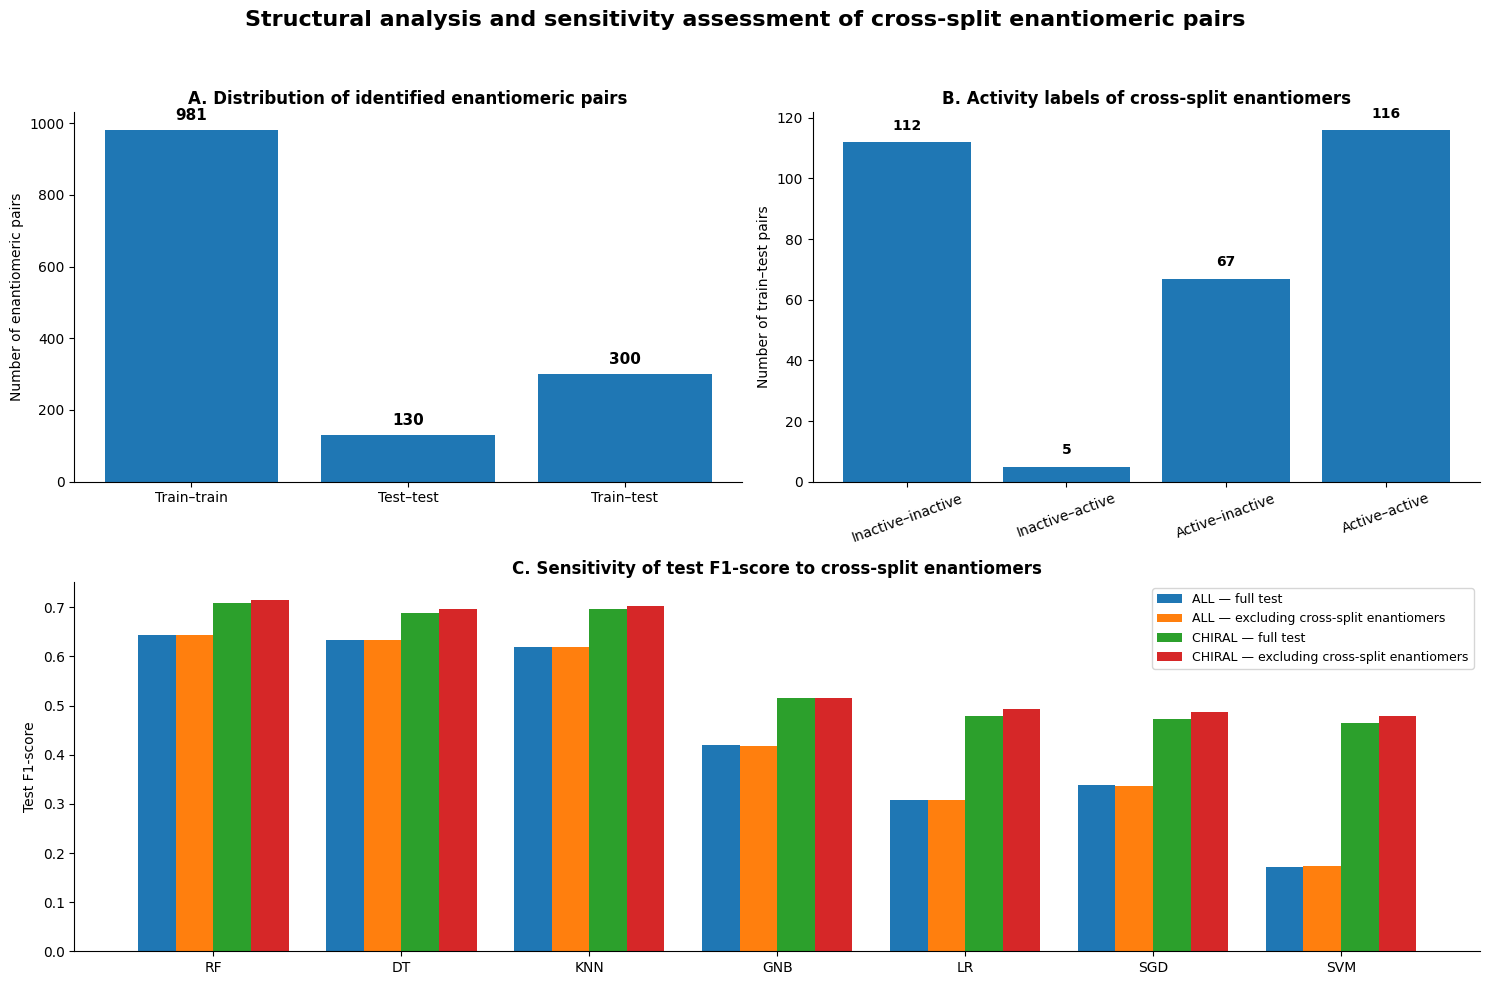



TEXT SUMMARY — PANEL A
Total true enantiomeric pairs: 1,411
Train–train: 981 pairs (69.53%)
Test–test: 130 pairs (9.21%)
Train–test: 300 pairs (21.26%)


TEXT SUMMARY — PANEL B
Cross-split enantiomeric pairs: 300
Inactive–inactive: 112 pairs (37.33%)
Inactive–active: 5 pairs (1.67%)
Active–inactive: 67 pairs (22.33%)
Active–active: 116 pairs (38.67%)

Same activity label: 228 pairs (76.00%)
Different activity label: 72 pairs (24.00%)


TEXT SUMMARY — PANEL C: F1 SENSITIVITY

ALL
RandomForest: full=0.644240, sensitivity=0.644051, difference=-0.000189
DecisionTree: full=0.633153, sensitivity=0.634112, difference=+0.000959
KNN: full=0.619912, sensitivity=0.618304, difference=-0.001607
GaussianNB: full=0.420755, sensitivity=0.417958, difference=-0.002797
LogisticRegression: full=0.307009, sensitivity=0.307234, difference=+0.000225
SGDClassifier: full=0.337567, sensitivity=0.336818, difference=-0.000749
LinearSVM: full=0.170913, sensitivity=0.173753, difference=+0.002841

CHIRAL
RandomFor

In [41]:
# ============================================================
# PART 15G — ENANTIOMER SENSITIVITY FIGURE AND TEXT SUMMARY
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("=" * 70)
print("PART 15G — ENANTIOMER SENSITIVITY FIGURE AND TEXT SUMMARY")
print("=" * 70)

# ------------------------------------------------------------
# Panel A — Distribution of true enantiomeric pairs
# ------------------------------------------------------------

pair_summary = pd.DataFrame({
    "pair_type": [
        "Train–train",
        "Test–test",
        "Train–test"
    ],
    "n_pairs": [
        981,
        130,
        300
    ]
})

total_pairs = pair_summary["n_pairs"].sum()

pair_summary["percentage"] = (
    pair_summary["n_pairs"]
    / total_pairs
    * 100
)

# ------------------------------------------------------------
# Panel B — Activity combinations of cross-split pairs
# ------------------------------------------------------------

activity_summary = pd.DataFrame({
    "activity_combination": [
        "Inactive–inactive",
        "Inactive–active",
        "Active–inactive",
        "Active–active"
    ],
    "n_pairs": [
        112,
        5,
        67,
        116
    ]
})

cross_split_total = activity_summary["n_pairs"].sum()

activity_summary["percentage"] = (
    activity_summary["n_pairs"]
    / cross_split_total
    * 100
)

same_activity = (
    activity_summary.loc[
        activity_summary["activity_combination"].isin(
            [
                "Inactive–inactive",
                "Active–active"
            ]
        ),
        "n_pairs"
    ].sum()
)

different_activity = (
    activity_summary.loc[
        activity_summary["activity_combination"].isin(
            [
                "Inactive–active",
                "Active–inactive"
            ]
        ),
        "n_pairs"
    ].sum()
)

# ------------------------------------------------------------
# Panel C — F1 sensitivity
# ------------------------------------------------------------

f1_plot = comparison_df.copy()

# LDA is intentionally excluded because it is treated
# separately in the manuscript.
model_order_plot = [
    "RandomForest",
    "DecisionTree",
    "KNN",
    "GaussianNB",
    "LogisticRegression",
    "SGDClassifier",
    "LinearSVM"
]

# ------------------------------------------------------------
# Create figure
# ------------------------------------------------------------

fig = plt.figure(figsize=(15, 10))

# ------------------------------------------------------------
# Panel A
# ------------------------------------------------------------

ax1 = plt.subplot(2, 2, 1)

bars1 = ax1.bar(
    pair_summary["pair_type"],
    pair_summary["n_pairs"]
)

for bar, value in zip(
    bars1,
    pair_summary["n_pairs"]
):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        value + 20,
        f"{value:,}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

ax1.set_ylabel("Number of enantiomeric pairs")

ax1.set_title(
    "A. Distribution of identified enantiomeric pairs",
    fontweight="bold"
)

ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

# ------------------------------------------------------------
# Panel B
# ------------------------------------------------------------

ax2 = plt.subplot(2, 2, 2)

bars2 = ax2.bar(
    activity_summary["activity_combination"],
    activity_summary["n_pairs"]
)

for bar, value in zip(
    bars2,
    activity_summary["n_pairs"]
):
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        value + 3,
        f"{value:,}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

ax2.set_ylabel("Number of train–test pairs")

ax2.set_title(
    "B. Activity labels of cross-split enantiomers",
    fontweight="bold"
)

ax2.tick_params(
    axis="x",
    rotation=20
)

ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

# ------------------------------------------------------------
# Panel C
# ------------------------------------------------------------

ax3 = plt.subplot(2, 1, 2)

# ------------------------------------------------------------
# ALL dataset
# ------------------------------------------------------------

all_f1 = (
    f1_plot[
        f1_plot["dataset"] == "all"
    ]
    .set_index("model")
    .loc[model_order_plot]
)

# ------------------------------------------------------------
# CHIRAL dataset
# ------------------------------------------------------------

chiral_f1 = (
    f1_plot[
        f1_plot["dataset"] == "chiral"
    ]
    .set_index("model")
    .loc[model_order_plot]
)

x = np.arange(len(model_order_plot))
width = 0.20

ax3.bar(
    x - 1.5 * width,
    all_f1["F1_full"],
    width,
    label="ALL — full test"
)

ax3.bar(
    x - 0.5 * width,
    all_f1["F1_sensitivity"],
    width,
    label="ALL — excluding cross-split enantiomers"
)

ax3.bar(
    x + 0.5 * width,
    chiral_f1["F1_full"],
    width,
    label="CHIRAL — full test"
)

ax3.bar(
    x + 1.5 * width,
    chiral_f1["F1_sensitivity"],
    width,
    label="CHIRAL — excluding cross-split enantiomers"
)

ax3.set_xticks(x)

ax3.set_xticklabels(
    [
        "RF",
        "DT",
        "KNN",
        "GNB",
        "LR",
        "SGD",
        "SVM"
    ]
)

ax3.set_ylabel("Test F1-score")

ax3.set_title(
    "C. Sensitivity of test F1-score to cross-split enantiomers",
    fontweight="bold"
)

ax3.legend(
    loc="upper right",
    fontsize=9
)

ax3.spines["top"].set_visible(False)
ax3.spines["right"].set_visible(False)

# ------------------------------------------------------------
# Overall figure
# ------------------------------------------------------------

fig.suptitle(
    "Structural analysis and sensitivity assessment of "
    "cross-split enantiomeric pairs",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout(
    rect=[0, 0, 1, 0.95]
)

figure_path = (
    "/kaggle/working/"
    "enantiomer_sensitivity_figure.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# TEXT SUMMARY FOR REPORTING
# ============================================================

print("\n")
print("=" * 70)
print("TEXT SUMMARY — PANEL A")
print("=" * 70)

print(
    f"Total true enantiomeric pairs: "
    f"{total_pairs:,}"
)

for _, row in pair_summary.iterrows():

    print(
        f"{row['pair_type']}: "
        f"{int(row['n_pairs']):,} pairs "
        f"({row['percentage']:.2f}%)"
    )

print("\n")
print("=" * 70)
print("TEXT SUMMARY — PANEL B")
print("=" * 70)

print(
    f"Cross-split enantiomeric pairs: "
    f"{cross_split_total:,}"
)

for _, row in activity_summary.iterrows():

    print(
        f"{row['activity_combination']}: "
        f"{int(row['n_pairs']):,} pairs "
        f"({row['percentage']:.2f}%)"
    )

print(
    f"\nSame activity label: "
    f"{same_activity:,} pairs "
    f"({same_activity / cross_split_total * 100:.2f}%)"
)

print(
    f"Different activity label: "
    f"{different_activity:,} pairs "
    f"({different_activity / cross_split_total * 100:.2f}%)"
)

print("\n")
print("=" * 70)
print("TEXT SUMMARY — PANEL C: F1 SENSITIVITY")
print("=" * 70)

f1_text = comparison_df[
    [
        "dataset",
        "model",
        "F1_full",
        "F1_sensitivity",
        "F1_difference"
    ]
].copy()

for dataset_name in [
    "all",
    "chiral",
    "nonchiral"
]:

    print(
        f"\n{dataset_name.upper()}"
    )

    dataset_f1 = f1_text[
        f1_text["dataset"] == dataset_name
    ].copy()

    dataset_f1 = (
        dataset_f1
        .set_index("model")
        .loc[model_order_plot]
        .reset_index()
    )

    for _, row in dataset_f1.iterrows():

        print(
            f"{row['model']}: "
            f"full={row['F1_full']:.6f}, "
            f"sensitivity={row['F1_sensitivity']:.6f}, "
            f"difference={row['F1_difference']:+.6f}"
        )

# ------------------------------------------------------------
# Maximum changes
# ------------------------------------------------------------

print("\n")
print("=" * 70)
print("TEXT SUMMARY — MAXIMUM ABSOLUTE CHANGES")
print("=" * 70)

metric_columns = [
    "Accuracy",
    "Balanced Accuracy",
    "Precision",
    "Recall",
    "F1",
    "MCC",
    "AUROC",
    "AUPRC"
]

for metric in metric_columns:

    difference_column = (
        f"{metric}_difference"
    )

    max_change = (
        comparison_df[difference_column]
        .abs()
        .max()
    )

    print(
        f"{metric}: "
        f"{max_change:.6f}"
    )

# ------------------------------------------------------------
# Save summary tables
# ------------------------------------------------------------

pair_summary.to_csv(
    "/kaggle/working/"
    "enantiomer_pair_distribution_summary.csv",
    index=False
)

activity_summary.to_csv(
    "/kaggle/working/"
    "enantiomer_activity_summary.csv",
    index=False
)

print("\n")
print("=" * 70)
print("FILES SAVED")
print("=" * 70)

print(
    "/kaggle/working/"
    "enantiomer_sensitivity_figure.png"
)

print(
    "/kaggle/working/"
    "enantiomer_pair_distribution_summary.csv"
)

print(
    "/kaggle/working/"
    "enantiomer_activity_summary.csv"
)

print("\n" + "=" * 70)
print("PART 15G COMPLETED SUCCESSFULLY")
print("=" * 70)

In [42]:
import pandas as pd

path = "/kaggle/working/enantiomer_sensitivity_comparison.csv"

enantiomer_comparison = pd.read_csv(path)

print("=" * 80)
print("ENANTIOMER SENSITIVITY COMPARISON")
print("=" * 80)

display(enantiomer_comparison)

print("\nColumns:")
print(enantiomer_comparison.columns.tolist())

print("\nShape:")
print(enantiomer_comparison.shape)

ENANTIOMER SENSITIVITY COMPARISON


,dataset,model,Accuracy_sensitivity,Balanced Accuracy_sensitivity,Precision_sensitivity,Recall_sensitivity,F1_sensitivity,MCC_sensitivity,AUROC_sensitivity,AUPRC_sensitivity,...,AUROC_full,AUPRC_full,Accuracy_difference,Balanced Accuracy_difference,Precision_difference,Recall_difference,F1_difference,MCC_difference,AUROC_difference,AUPRC_difference
0,all,RandomForest,0.927588,0.787483,0.683421,0.608970,0.644051,0.605139,0.941917,0.706618,...,0.941352,0.706171,0.000919,0.000188,-0.000312,-0.000091,-0.000189,0.000371,5.648033e-04,4.466220e-04
1,all,DecisionTree,0.925512,0.782381,0.672321,0.600013,0.634112,0.593986,0.890947,0.592651,...,0.887996,0.589103,0.001101,0.001045,0.000090,0.001644,0.000959,0.001565,2.951073e-03,3.547370e-03
2,all,KNN,0.906919,0.816289,0.553177,0.700814,0.618304,0.571275,0.895193,0.515385,...,0.894920,0.518434,0.000314,0.000943,-0.003952,0.002173,-0.001607,-0.000893,2.724116e-04,-3.049685e-03
3,all,GaussianNB,0.815690,0.727508,0.316500,0.615152,0.417958,0.346691,0.864960,0.367869,...,0.864652,0.369821,0.000499,-0.000145,-0.003070,-0.000554,-0.002797,-0.001670,3.082744e-04,-1.951933e-03
4,all,LogisticRegression,0.899074,0.595205,0.587251,0.208036,0.307234,0.308146,0.881826,0.443536,...,0.881707,0.443968,0.001755,0.000095,0.006356,-0.000602,0.000225,0.002501,1.193056e-04,-4.327775e-04
5,all,SGDClassifier,0.894528,0.610660,0.520438,0.248975,0.336818,0.310374,0.881939,0.441982,...,0.881773,0.442533,0.001679,-0.000284,0.002770,-0.001463,-0.000749,0.000982,1.659487e-04,-5.509947e-04
6,all,LinearSVM,0.899258,0.547127,0.738061,0.098467,0.173753,0.245543,0.881884,0.456175,...,0.881803,0.456852,0.001477,0.000903,0.000054,0.001820,0.002841,0.002660,8.103956e-05,-6.777743e-04
7,chiral,RandomForest,0.927076,0.824501,0.750656,0.684259,0.715921,0.675144,0.953978,0.790737,...,0.951221,0.781428,0.003140,0.005189,0.006933,0.008852,0.008000,0.009814,2.757150e-03,9.309108e-03
8,chiral,DecisionTree,0.920507,0.820007,0.713160,0.682604,0.697548,0.652020,0.864194,0.587949,...,0.861024,0.582214,0.003440,0.005153,0.007999,0.008337,0.008180,0.010265,3.170215e-03,5.734191e-03
9,chiral,KNN,0.918259,0.833858,0.687126,0.718463,0.702445,0.655314,0.900352,0.646436,...,0.898466,0.638178,0.002815,0.003419,0.005365,0.004945,0.005167,0.006920,1.886111e-03,8.258309e-03



Columns:
['dataset', 'model', 'Accuracy_sensitivity', 'Balanced Accuracy_sensitivity', 'Precision_sensitivity', 'Recall_sensitivity', 'F1_sensitivity', 'MCC_sensitivity', 'AUROC_sensitivity', 'AUPRC_sensitivity', 'Accuracy_full', 'Balanced Accuracy_full', 'Precision_full', 'Recall_full', 'F1_full', 'MCC_full', 'AUROC_full', 'AUPRC_full', 'Accuracy_difference', 'Balanced Accuracy_difference', 'Precision_difference', 'Recall_difference', 'F1_difference', 'MCC_difference', 'AUROC_difference', 'AUPRC_difference']

Shape:
(21, 26)


In [45]:
# PART 16A — Definitive count of chiral compounds

import pandas as pd

# Count unique compound groups by chiral status
chiral_compound_counts = (
    df_clean.groupby("compound_group")["Chiral Drug"]
    .first()
    .value_counts()
    .sort_index()
)

print("=" * 70)
print("DEFINITIVE COMPOUND-LEVEL CHIRALITY COUNT")
print("=" * 70)

for value, count in chiral_compound_counts.items():
    label = "Non-chiral" if value == 0 else "Chiral"
    print(f"{label} compounds: {count:,}")

print(f"\nTotal compounds: {chiral_compound_counts.sum():,}")

# Cross-check using unique compound groups
chiral_compounds = (
    df_clean.loc[df_clean["Chiral Drug"] == 1, "compound_group"]
    .nunique()
)

nonchiral_compounds = (
    df_clean.loc[df_clean["Chiral Drug"] == 0, "compound_group"]
    .nunique()
)

print("\nCross-check:")
print(f"Unique chiral compounds: {chiral_compounds:,}")
print(f"Unique non-chiral compounds: {nonchiral_compounds:,}")
print(f"Unique compounds total: {chiral_compounds + nonchiral_compounds:,}")

# Check whether any compound has inconsistent Chiral Drug labels
compound_chirality_consistency = (
    df_clean.groupby("compound_group")["Chiral Drug"]
    .nunique()
)

inconsistent_compounds = (compound_chirality_consistency > 1).sum()

print(f"\nCompounds with inconsistent Chiral Drug labels: {inconsistent_compounds:,}")

DEFINITIVE COMPOUND-LEVEL CHIRALITY COUNT
Non-chiral compounds: 45,391
Chiral compounds: 20,434

Total compounds: 65,825

Cross-check:
Unique chiral compounds: 20,434
Unique non-chiral compounds: 45,391
Unique compounds total: 65,825

Compounds with inconsistent Chiral Drug labels: 0


In [47]:
# ============================================================
# PART 16A — ECFP4-CHIRAL BENCHMARK: INITIAL CHECKS
# ============================================================

print("=" * 70)
print("PART 16A — ECFP4-CHIRAL BENCHMARK")
print("=" * 70)

# ------------------------------------------------------------
# 1. Check required dataset
# ------------------------------------------------------------

if "df_ml" not in globals():
    raise RuntimeError(
        "df_ml is not available in the current Kaggle session."
    )

print("✓ df_ml is available.")

# ------------------------------------------------------------
# 2. Define column names
# ------------------------------------------------------------

compound_group_col = "compound_group"
split_col = "dataset_split"
target_col = "f(vdij,vpj,vnrj)obj"
smiles_col = "CANONICAL_SMILES"

required_columns = [
    compound_group_col,
    split_col,
    target_col,
    smiles_col
]

missing_columns = [
    col for col in required_columns
    if col not in df_ml.columns
]

if missing_columns:
    raise RuntimeError(
        f"Required columns are missing from df_ml: {missing_columns}"
    )

print("✓ Required columns are available.")

# ------------------------------------------------------------
# 3. Check RDKit
# ------------------------------------------------------------

try:
    from rdkit import Chem
    from rdkit.Chem import rdFingerprintGenerator
    import rdkit

    print(f"✓ RDKit version: {rdkit.__version__}")

except ImportError as e:
    raise ImportError(
        "RDKit is not available in the current Kaggle session."
    ) from e

# ------------------------------------------------------------
# 4. Dataset information
# ------------------------------------------------------------

print("\nDataset information:")
print(f"Rows:              {len(df_ml):,}")
print(
    f"Unique compounds:  "
    f"{df_ml[compound_group_col].nunique():,}"
)

print("\nDataset split:")
print(
    df_ml[split_col]
    .value_counts(dropna=False)
)

print("\nTarget distribution:")
print(
    df_ml[target_col]
    .value_counts(dropna=False)
    .sort_index()
)

# ------------------------------------------------------------
# 5. Verify compound-level train/test separation
# ------------------------------------------------------------

compound_split_check = (
    df_ml
    .groupby(compound_group_col)[split_col]
    .nunique()
)

problematic_compounds = compound_split_check[
    compound_split_check > 1
]

if len(problematic_compounds) > 0:
    raise ValueError(
        f"Found {len(problematic_compounds)} compounds appearing "
        "in more than one dataset split."
    )

print(
    f"\n✓ Compound-level split verified: "
    f"{len(problematic_compounds)} compounds overlap "
    "between train/test."
)

# ------------------------------------------------------------
# 6. Check missing SMILES
# ------------------------------------------------------------

missing_smiles = (
    df_ml[smiles_col]
    .isna()
    .sum()
)

print(
    f"\nMissing canonical SMILES: "
    f"{missing_smiles:,}"
)

if missing_smiles > 0:
    raise ValueError(
        "Missing canonical SMILES detected. "
        "The ECFP4-Chiral benchmark requires valid molecular structures."
    )

# ------------------------------------------------------------
# 7. Check duplicate compound/SMILES consistency
# ------------------------------------------------------------

smiles_per_compound = (
    df_ml
    .groupby(compound_group_col)[smiles_col]
    .nunique()
)

problematic_smiles = smiles_per_compound[
    smiles_per_compound > 1
]

if len(problematic_smiles) > 0:
    print(
        f"\nWARNING: {len(problematic_smiles):,} compound groups "
        "have more than one canonical SMILES representation."
    )
else:
    print(
        "\n✓ Each compound group has one canonical SMILES."
    )

print("\n" + "=" * 70)
print("PART 16A completed successfully.")
print("=" * 70)

PART 16A — ECFP4-CHIRAL BENCHMARK
✓ df_ml is available.
✓ Required columns are available.
✓ RDKit version: 2026.03.6

Dataset information:
Rows:              756,893
Unique compounds:  65,825

Dataset split:
dataset_split
train    605033
test     151860
Name: count, dtype: int64

Target distribution:
f(vdij,vpj,vnrj)obj
0    672045
1     84848
Name: count, dtype: int64

✓ Compound-level split verified: 0 compounds overlap between train/test.

Missing canonical SMILES: 0

✓ Each compound group has one canonical SMILES.

PART 16A completed successfully.


In [49]:
# ============================================================
# PART 16B — ECFP4-CHIRAL FINGERPRINT GENERATION
#              WITH INVALID-SMILES HANDLING
# ============================================================

print("=" * 70)
print("PART 16B — ECFP4-CHIRAL FINGERPRINT GENERATION")
print("=" * 70)

from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. Parameters
# ------------------------------------------------------------

FP_RADIUS = 2
FP_NBITS = 2048
USE_CHIRALITY = True

print("\nFingerprint parameters:")
print(f"Radius:              {FP_RADIUS}")
print(f"Number of bits:      {FP_NBITS}")
print(f"Use chirality:       {USE_CHIRALITY}")

# ------------------------------------------------------------
# 2. Create Morgan fingerprint generator
# ------------------------------------------------------------

morgan_generator = rdFingerprintGenerator.GetMorganGenerator(
    radius=FP_RADIUS,
    fpSize=FP_NBITS,
    includeChirality=USE_CHIRALITY
)

print("\n✓ ECFP4-Chiral Morgan fingerprint generator created.")

# ------------------------------------------------------------
# 3. One molecular record per compound
# ------------------------------------------------------------

compound_info = (
    df_ml[
        [
            compound_group_col,
            smiles_col,
            split_col
        ]
    ]
    .drop_duplicates(subset=[compound_group_col])
    .copy()
    .reset_index(drop=True)
)

print(
    f"\nUnique compounds to process: "
    f"{len(compound_info):,}"
)

# ------------------------------------------------------------
# 4. Parse SMILES and identify invalid structures
# ------------------------------------------------------------

molecules = []
invalid_records = []

for idx, row in compound_info.iterrows():

    smiles = row[smiles_col]
    mol = Chem.MolFromSmiles(smiles)

    if mol is None:

        invalid_records.append({
            "ecfp_index": idx,
            compound_group_col: row[compound_group_col],
            smiles_col: smiles,
            split_col: row[split_col]
        })

        molecules.append(None)

    else:
        molecules.append(mol)

invalid_smiles_df = pd.DataFrame(
    invalid_records
)

print(
    f"\nValid molecules:   "
    f"{sum(mol is not None for mol in molecules):,}"
)

print(
    f"Invalid SMILES:    "
    f"{len(invalid_smiles_df):,}"
)

# ------------------------------------------------------------
# 5. Report invalid SMILES WITHOUT stopping execution
# ------------------------------------------------------------

if len(invalid_smiles_df) > 0:

    print("\nWARNING — Invalid SMILES detected:")
    print(
        invalid_smiles_df.to_string(index=False)
    )

else:

    print("\n✓ No invalid SMILES detected.")

# ------------------------------------------------------------
# 6. Generate fingerprints only for valid molecules
# ------------------------------------------------------------

valid_indices = [
    i for i, mol in enumerate(molecules)
    if mol is not None
]

fingerprints = []

for i in valid_indices:

    fp = morgan_generator.GetFingerprint(
        molecules[i]
    )

    fingerprints.append(
        np.asarray(fp)
    )

X_ecfp = np.asarray(
    fingerprints,
    dtype=np.uint8
)

print("\nFingerprint matrix:")
print(f"Shape: {X_ecfp.shape}")

print(
    f"Expected number of columns: "
    f"{FP_NBITS}"
)

# ------------------------------------------------------------
# 7. Build metadata only for valid compounds
# ------------------------------------------------------------

ecfp_metadata = (
    compound_info
    .iloc[valid_indices]
    .copy()
    .reset_index(drop=True)
)

ecfp_metadata["ecfp_index"] = np.arange(
    len(ecfp_metadata)
)

# ------------------------------------------------------------
# 8. Verify fingerprint dimensions
# ------------------------------------------------------------

if X_ecfp.shape != (
    len(ecfp_metadata),
    FP_NBITS
):
    raise ValueError(
        "Unexpected ECFP4-Chiral matrix dimensions."
    )

print(
    "✓ Fingerprint dimensions verified."
)

# ------------------------------------------------------------
# 9. Verify binary fingerprint values
# ------------------------------------------------------------

unique_fp_values = np.unique(X_ecfp)

print(
    f"\nUnique fingerprint values: "
    f"{unique_fp_values}"
)

if not np.all(
    np.isin(unique_fp_values, [0, 1])
):
    raise ValueError(
        "Fingerprint matrix contains values "
        "other than 0 and 1."
    )

print("✓ Fingerprints are binary.")

# ------------------------------------------------------------
# 10. Check train/test compound distribution
# ------------------------------------------------------------

print("\nCompound distribution after removing invalid SMILES:")

print(
    ecfp_metadata[split_col]
    .value_counts()
)

train_ecfp_count = (
    ecfp_metadata[split_col] == "train"
).sum()

test_ecfp_count = (
    ecfp_metadata[split_col] == "test"
).sum()

print(
    f"\n✓ Train compounds represented: "
    f"{train_ecfp_count:,}"
)

print(
    f"✓ Test compounds represented:  "
    f"{test_ecfp_count:,}"
)

# ------------------------------------------------------------
# 11. Check whether invalid compounds are train or test
# ------------------------------------------------------------

if len(invalid_smiles_df) > 0:

    print(
        "\nInvalid compound(s) by dataset split:"
    )

    print(
        invalid_smiles_df[split_col]
        .value_counts()
    )

# ------------------------------------------------------------
# 12. Save valid ECFP dataset
# ------------------------------------------------------------

np.save(
    "/kaggle/working/ecfp4_chiral_2048.npy",
    X_ecfp
)

ecfp_metadata.to_csv(
    "/kaggle/working/ecfp4_chiral_metadata.csv",
    index=False
)

if len(invalid_smiles_df) > 0:

    invalid_smiles_df.to_csv(
        "/kaggle/working/ecfp4_chiral_invalid_smiles.csv",
        index=False
    )

print("\nSaved files:")

print(
    "  /kaggle/working/ecfp4_chiral_2048.npy"
)

print(
    "  /kaggle/working/ecfp4_chiral_metadata.csv"
)

if len(invalid_smiles_df) > 0:

    print(
        "  /kaggle/working/ecfp4_chiral_invalid_smiles.csv"
    )

print("\n" + "=" * 70)
print("PART 16B completed.")
print("=" * 70)

PART 16B — ECFP4-CHIRAL FINGERPRINT GENERATION

Fingerprint parameters:
Radius:              2
Number of bits:      2048
Use chirality:       True

✓ ECFP4-Chiral Morgan fingerprint generator created.

Unique compounds to process: 65,825


[12:00:42] Conflicting single bond directions around double bond at index 5.
[12:00:42]   BondStereo set to STEREONONE and single bond directions set to NONE.
[12:00:45] SMILES Parse Error: syntax error while parsing: NOTSMILE
[12:00:45] SMILES Parse Error: check for mistakes around position 3:
[12:00:45] NOTSMILE
[12:00:45] ~~^
[12:00:45] SMILES Parse Error: Failed parsing SMILES 'NOTSMILE' for input: 'NOTSMILE'



Valid molecules:   65,824
Invalid SMILES:    1

WARNING — Invalid SMILES detected:
 ecfp_index compound_group CANONICAL_SMILES dataset_split
      50293  CHEMBL3663939         NOTSMILE          test

Fingerprint matrix:
Shape: (65824, 2048)
Expected number of columns: 2048
✓ Fingerprint dimensions verified.

Unique fingerprint values: [0 1]
✓ Fingerprints are binary.

Compound distribution after removing invalid SMILES:
dataset_split
train    52660
test     13164
Name: count, dtype: int64

✓ Train compounds represented: 52,660
✓ Test compounds represented:  13,164

Invalid compound(s) by dataset split:
dataset_split
test    1
Name: count, dtype: int64

Saved files:
  /kaggle/working/ecfp4_chiral_2048.npy
  /kaggle/working/ecfp4_chiral_metadata.csv
  /kaggle/working/ecfp4_chiral_invalid_smiles.csv

PART 16B completed.


In [50]:
# ============================================================
# PART 16C — INVESTIGATION OF CHEMBL3663939
# ============================================================

print("=" * 70)
print("PART 16C — INVESTIGATION OF INVALID SMILES")
print("=" * 70)

invalid_compound = "CHEMBL3663939"

# ------------------------------------------------------------
# 1. Retrieve all records for the invalid compound
# ------------------------------------------------------------

invalid_df = df_ml[
    df_ml[compound_group_col] == invalid_compound
].copy()

print("\nInvalid compound:")
print(invalid_compound)

print(
    f"\nNumber of assay records: "
    f"{len(invalid_df):,}"
)

# ------------------------------------------------------------
# 2. Display relevant information
# ------------------------------------------------------------

display_columns = [
    compound_group_col,
    smiles_col,
    split_col,
    target_col,
]

# Add CHEMBL column if available
if "CHEMBLID mi" in invalid_df.columns:
    display_columns.insert(
        1,
        "CHEMBLID mi"
    )

# Add chirality column if available
if "Chiral Drug" in invalid_df.columns:
    display_columns.insert(
        2,
        "Chiral Drug"
    )

print("\nRelevant records:")
display(
    invalid_df[display_columns]
)

# ------------------------------------------------------------
# 3. Target distribution
# ------------------------------------------------------------

print("\nTarget distribution for this compound:")

print(
    invalid_df[target_col]
    .value_counts()
    .sort_index()
)

# ------------------------------------------------------------
# 4. Chirality information
# ------------------------------------------------------------

if "Chiral Drug" in invalid_df.columns:

    print("\nChirality distribution:")

    print(
        invalid_df["Chiral Drug"]
        .value_counts(dropna=False)
        .sort_index()
    )

# ------------------------------------------------------------
# 5. Original dataframe check
# ------------------------------------------------------------

if "compound_group" in df_ml.columns:

    print("\nCompound-group information:")
    
    print(
        df_ml[
            df_ml["compound_group"] == invalid_compound
        ][
            [
                "compound_group",
                smiles_col,
                split_col,
                target_col
            ]
        ].drop_duplicates()
    )

# ------------------------------------------------------------
# 6. Check whether this compound was present before df_ml
# ------------------------------------------------------------

if "df_clean" in globals():

    print(
        "\n✓ df_clean is available in the current session."
    )

    original_invalid = df_clean[
        (
            df_clean["compound_group"]
            == invalid_compound
        )
    ].copy()

    print(
        f"Records for {invalid_compound} in df_clean: "
        f"{len(original_invalid):,}"
    )

else:

    print(
        "\nNo df_clean variable is available "
        "in the current session."
    )

# ------------------------------------------------------------
# 7. Check whether NOTSMILE appears elsewhere
# ------------------------------------------------------------

not_smile_records = df_ml[
    df_ml[smiles_col].astype(str).str.upper() == "NOTSMILE"
].copy()

print(
    f"\nTotal records with SMILES = NOTSMILE: "
    f"{len(not_smile_records):,}"
)

print(
    f"Unique compounds with SMILES = NOTSMILE: "
    f"{not_smile_records[compound_group_col].nunique():,}"
)

# ------------------------------------------------------------
# 8. Summary
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("PART 16C completed.")
print("=" * 70)

PART 16C — INVESTIGATION OF INVALID SMILES

Invalid compound:
CHEMBL3663939

Number of assay records: 12

Relevant records:


,compound_group,CHEMBLID mi,Chiral Drug,CANONICAL_SMILES,dataset_split,"f(vdij,vpj,vnrj)obj"
548380,CHEMBL3663939,CHEMBL3663939,0,NOTSMILE,test,0
548381,CHEMBL3663939,CHEMBL3663939,0,NOTSMILE,test,0
560334,CHEMBL3663939,CHEMBL3663939,0,NOTSMILE,test,0
560335,CHEMBL3663939,CHEMBL3663939,0,NOTSMILE,test,0
701098,CHEMBL3663939,CHEMBL3663939,0,NOTSMILE,test,0
701099,CHEMBL3663939,CHEMBL3663939,0,NOTSMILE,test,0
701292,CHEMBL3663939,CHEMBL3663939,0,NOTSMILE,test,0
701293,CHEMBL3663939,CHEMBL3663939,0,NOTSMILE,test,0
702980,CHEMBL3663939,CHEMBL3663939,0,NOTSMILE,test,0
702981,CHEMBL3663939,CHEMBL3663939,0,NOTSMILE,test,0



Target distribution for this compound:
f(vdij,vpj,vnrj)obj
0    12
Name: count, dtype: int64

Chirality distribution:
Chiral Drug
0    12
Name: count, dtype: int64

Compound-group information:
       compound_group CANONICAL_SMILES dataset_split  f(vdij,vpj,vnrj)obj
548380  CHEMBL3663939         NOTSMILE          test                    0

✓ df_clean is available in the current session.
Records for CHEMBL3663939 in df_clean: 12

Total records with SMILES = NOTSMILE: 12
Unique compounds with SMILES = NOTSMILE: 1

PART 16C completed.


In [51]:
# ============================================================
# PART 16D — COMMON TEST SET FOR FAIR ECFP COMPARISON
# ============================================================

print("=" * 70)
print("PART 16D — COMMON TEST SET FOR FAIR ECFP COMPARISON")
print("=" * 70)

# ------------------------------------------------------------
# 1. Invalid compound identified in PART 16C
# ------------------------------------------------------------

invalid_compound = "CHEMBL3663939"

# ------------------------------------------------------------
# 2. Define the common evaluation dataset
# ------------------------------------------------------------
# We exclude the invalid-SMILES compound from BOTH methods
# so that CHIEF-PTML-RF and ECFP4-Chiral-RF are evaluated
# on exactly the same test compounds.

common_test_df = df_ml[
    (df_ml[split_col] == "test") &
    (df_ml[compound_group_col] != invalid_compound)
].copy()

# ------------------------------------------------------------
# 3. Basic counts
# ------------------------------------------------------------

print("\nOriginal test set:")
print(
    f"Rows:              "
    f"{(df_ml[split_col] == 'test').sum():,}"
)

print(
    f"Unique compounds:  "
    f"{df_ml.loc[
        df_ml[split_col] == 'test',
        compound_group_col
    ].nunique():,}"
)

print("\nCommon test set:")
print(
    f"Rows:              "
    f"{len(common_test_df):,}"
)

print(
    f"Unique compounds:  "
    f"{common_test_df[compound_group_col].nunique():,}"
)

# ------------------------------------------------------------
# 4. Verify that exactly the invalid compound was removed
# ------------------------------------------------------------

removed_rows = (
    (df_ml[split_col] == "test") &
    (df_ml[compound_group_col] == invalid_compound)
).sum()

removed_compounds = df_ml.loc[
    (df_ml[split_col] == "test") &
    (df_ml[compound_group_col] == invalid_compound),
    compound_group_col
].nunique()

print("\nRemoved from common test:")
print(f"Rows:              {removed_rows:,}")
print(f"Compounds:         {removed_compounds:,}")

if removed_rows != 12:
    raise ValueError(
        "Unexpected number of removed assay records."
    )

if removed_compounds != 1:
    raise ValueError(
        "Unexpected number of removed compounds."
    )

# ------------------------------------------------------------
# 5. Verify target distribution
# ------------------------------------------------------------

print("\nTarget distribution — original test:")
print(
    df_ml.loc[
        df_ml[split_col] == "test",
        target_col
    ]
    .value_counts()
    .sort_index()
)

print("\nTarget distribution — common test:")
print(
    common_test_df[target_col]
    .value_counts()
    .sort_index()
)

# ------------------------------------------------------------
# 6. Verify no invalid SMILES remain
# ------------------------------------------------------------

remaining_invalid = common_test_df[
    common_test_df[smiles_col].astype(str).str.upper()
    == "NOTSMILE"
]

print(
    f"\nRemaining NOTSMILE records: "
    f"{len(remaining_invalid):,}"
)

if len(remaining_invalid) != 0:
    raise ValueError(
        "NOTSMILE records remain in the common test set."
    )

print("✓ No invalid SMILES remain.")

# ------------------------------------------------------------
# 7. Verify compound-level integrity
# ------------------------------------------------------------

compound_split_check = (
    common_test_df
    .groupby(compound_group_col)[split_col]
    .nunique()
)

if (compound_split_check > 1).any():
    raise ValueError(
        "Compound-level split integrity was violated."
    )

print(
    "✓ Compound-level test integrity verified."
)

# ------------------------------------------------------------
# 8. Save common test set
# ------------------------------------------------------------

common_test_df.to_csv(
    "/kaggle/working/common_test_set_ecfp_comparison.csv",
    index=False
)

print(
    "\nSaved:"
    "\n  /kaggle/working/common_test_set_ecfp_comparison.csv"
)

# ------------------------------------------------------------
# 9. Final summary
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("PART 16D completed successfully.")
print("=" * 70)

PART 16D — COMMON TEST SET FOR FAIR ECFP COMPARISON

Original test set:
Rows:              151,860
Unique compounds:  13,165

Common test set:
Rows:              151,848
Unique compounds:  13,164

Removed from common test:
Rows:              12
Compounds:         1

Target distribution — original test:
f(vdij,vpj,vnrj)obj
0    135305
1     16555
Name: count, dtype: int64

Target distribution — common test:
f(vdij,vpj,vnrj)obj
0    135293
1     16555
Name: count, dtype: int64

Remaining NOTSMILE records: 0
✓ No invalid SMILES remain.
✓ Compound-level test integrity verified.

Saved:
  /kaggle/working/common_test_set_ecfp_comparison.csv

PART 16D completed successfully.


In [52]:
# ============================================================
# PART 16E — BUILD ECFP4-CHIRAL RECORD-LEVEL DATASET
# ============================================================

print("=" * 70)
print("PART 16E — BUILD ECFP4-CHIRAL RECORD-LEVEL DATASET")
print("=" * 70)

# ------------------------------------------------------------
# 1. Load the valid compound-level fingerprints
# ------------------------------------------------------------

X_ecfp_loaded = np.load(
    "/kaggle/working/ecfp4_chiral_2048.npy"
)

ecfp_metadata_loaded = pd.read_csv(
    "/kaggle/working/ecfp4_chiral_metadata.csv"
)

print(
    f"Loaded fingerprint matrix: "
    f"{X_ecfp_loaded.shape}"
)

print(
    f"Loaded compound metadata: "
    f"{ecfp_metadata_loaded.shape}"
)

# ------------------------------------------------------------
# 2. Create mapping:
#    compound_group -> ECFP row
# ------------------------------------------------------------

compound_to_ecfp_index = dict(
    zip(
        ecfp_metadata_loaded[compound_group_col],
        ecfp_metadata_loaded["ecfp_index"]
    )
)

print(
    f"\nCompound-to-fingerprint mappings: "
    f"{len(compound_to_ecfp_index):,}"
)

# ------------------------------------------------------------
# 3. Verify that all compounds in df_ml except the
#    invalid compound have a fingerprint
# ------------------------------------------------------------

valid_compounds = set(
    df_ml[compound_group_col].unique()
) - {invalid_compound}

missing_fingerprints = [
    group
    for group in valid_compounds
    if group not in compound_to_ecfp_index
]

print(
    f"\nValid compounds in df_ml: "
    f"{len(valid_compounds):,}"
)

print(
    f"Compounds without fingerprints: "
    f"{len(missing_fingerprints):,}"
)

if missing_fingerprints:
    raise ValueError(
        "Some valid compounds do not have an ECFP fingerprint."
    )

print("✓ Every valid compound has an ECFP fingerprint.")

# ------------------------------------------------------------
# 4. Create ECFP index for every assay record
# ------------------------------------------------------------

ecfp_record_df = df_ml[
    df_ml[compound_group_col] != invalid_compound
].copy()

ecfp_record_df["ecfp_index"] = (
    ecfp_record_df[compound_group_col]
    .map(compound_to_ecfp_index)
)

# ------------------------------------------------------------
# 5. Verify no missing fingerprint assignments
# ------------------------------------------------------------

missing_record_indices = (
    ecfp_record_df["ecfp_index"].isna().sum()
)

print(
    f"\nRecords without fingerprint assignment: "
    f"{missing_record_indices:,}"
)

if missing_record_indices > 0:
    raise ValueError(
        "Some assay records could not be assigned "
        "an ECFP fingerprint."
    )

ecfp_record_df["ecfp_index"] = (
    ecfp_record_df["ecfp_index"].astype(int)
)

print(
    "✓ Every assay record has an ECFP fingerprint."
)

# ------------------------------------------------------------
# 6. Separate train and common test
# ------------------------------------------------------------

ecfp_train_df = ecfp_record_df[
    ecfp_record_df[split_col] == "train"
].copy()

ecfp_test_df = ecfp_record_df[
    ecfp_record_df[split_col] == "test"
].copy()

print("\nRecord-level datasets:")

print(
    f"Train records:     {len(ecfp_train_df):,}"
)

print(
    f"Test records:      {len(ecfp_test_df):,}"
)

print(
    f"Total records:     {len(ecfp_record_df):,}"
)

# ------------------------------------------------------------
# 7. Verify expected sizes
# ------------------------------------------------------------

expected_train_rows = (
    df_ml[
        df_ml[split_col] == "train"
    ].shape[0]
)

expected_test_rows = (
    common_test_df.shape[0]
)

if len(ecfp_train_df) != expected_train_rows:
    raise ValueError(
        "Unexpected number of ECFP training records."
    )

if len(ecfp_test_df) != expected_test_rows:
    raise ValueError(
        "Unexpected number of ECFP common-test records."
    )

print(
    "✓ Train/test record counts verified."
)

# ------------------------------------------------------------
# 8. Build feature matrices
# ------------------------------------------------------------

train_ecfp_indices = (
    ecfp_train_df["ecfp_index"].to_numpy()
)

test_ecfp_indices = (
    ecfp_test_df["ecfp_index"].to_numpy()
)

X_ecfp_train = X_ecfp_loaded[
    train_ecfp_indices
]

X_ecfp_test = X_ecfp_loaded[
    test_ecfp_indices
]

y_ecfp_train = (
    ecfp_train_df[target_col]
    .astype(int)
    .to_numpy()
)

y_ecfp_test = (
    ecfp_test_df[target_col]
    .astype(int)
    .to_numpy()
)

groups_ecfp_train = (
    ecfp_train_df[compound_group_col]
    .to_numpy()
)

groups_ecfp_test = (
    ecfp_test_df[compound_group_col]
    .to_numpy()
)

print("\nFeature matrices:")

print(
    f"X_train: {X_ecfp_train.shape}"
)

print(
    f"X_test:  {X_ecfp_test.shape}"
)

print(
    f"y_train: {y_ecfp_train.shape}"
)

print(
    f"y_test:  {y_ecfp_test.shape}"
)

# ------------------------------------------------------------
# 9. Verify target distributions
# ------------------------------------------------------------

print("\nTraining target distribution:")

print(
    pd.Series(y_ecfp_train)
    .value_counts()
    .sort_index()
)

print("\nCommon test target distribution:")

print(
    pd.Series(y_ecfp_test)
    .value_counts()
    .sort_index()
)

# ------------------------------------------------------------
# 10. Verify compound-level separation
# ------------------------------------------------------------

train_groups = set(
    groups_ecfp_train
)

test_groups = set(
    groups_ecfp_test
)

overlap_groups = (
    train_groups & test_groups
)

print(
    f"\nTrain/test overlapping compounds: "
    f"{len(overlap_groups):,}"
)

if overlap_groups:
    raise ValueError(
        "Compound-level leakage detected in ECFP benchmark."
    )

print(
    "✓ No compound appears in both train and test."
)

# ------------------------------------------------------------
# 11. Save record-level datasets
# ------------------------------------------------------------

ecfp_train_df.to_csv(
    "/kaggle/working/ecfp4_chiral_train_records.csv",
    index=False
)

ecfp_test_df.to_csv(
    "/kaggle/working/ecfp4_chiral_common_test_records.csv",
    index=False
)

print("\nSaved:")
print(
    "  /kaggle/working/ecfp4_chiral_train_records.csv"
)
print(
    "  /kaggle/working/ecfp4_chiral_common_test_records.csv"
)

print("\n" + "=" * 70)
print("PART 16E completed successfully.")
print("=" * 70)

PART 16E — BUILD ECFP4-CHIRAL RECORD-LEVEL DATASET
Loaded fingerprint matrix: (65824, 2048)
Loaded compound metadata: (65824, 4)

Compound-to-fingerprint mappings: 65,824

Valid compounds in df_ml: 65,824
Compounds without fingerprints: 0
✓ Every valid compound has an ECFP fingerprint.

Records without fingerprint assignment: 0
✓ Every assay record has an ECFP fingerprint.

Record-level datasets:
Train records:     605,033
Test records:      151,848
Total records:     756,881
✓ Train/test record counts verified.

Feature matrices:
X_train: (605033, 2048)
X_test:  (151848, 2048)
y_train: (605033,)
y_test:  (151848,)

Training target distribution:
0    536740
1     68293
Name: count, dtype: int64

Common test target distribution:
0    135293
1     16555
Name: count, dtype: int64

Train/test overlapping compounds: 0
✓ No compound appears in both train and test.

Saved:
  /kaggle/working/ecfp4_chiral_train_records.csv
  /kaggle/working/ecfp4_chiral_common_test_records.csv

PART 16E complet

In [54]:
# ============================================================
# PART 16F — COMPLETE ECFP4-CHIRAL RF METRICS
# ============================================================

print("=" * 70)
print("PART 16F — ECFP4-CHIRAL RANDOM FOREST METRICS")
print("=" * 70)

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score,
    average_precision_score
)

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. Verify trained model and predictions
# ------------------------------------------------------------

required_objects = [
    "ecfp_rf",
    "y_ecfp_train",
    "y_ecfp_test",
    "y_train_pred_ecfp",
    "y_test_pred_ecfp",
    "y_train_score_ecfp",
    "y_test_score_ecfp"
]

missing_objects = [
    obj for obj in required_objects
    if obj not in globals()
]

if missing_objects:
    raise RuntimeError(
        "Required objects are missing: "
        + ", ".join(missing_objects)
    )

print("\n✓ Trained ECFP4-Chiral Random Forest is available.")
print("✓ Predictions are available.")

# ------------------------------------------------------------
# 2. Calculate metrics
# ------------------------------------------------------------

def calculate_metrics_ecfp(
    y_true,
    y_pred,
    y_score
):

    return {
        "Accuracy": accuracy_score(
            y_true,
            y_pred
        ),

        "Balanced Accuracy": balanced_accuracy_score(
            y_true,
            y_pred
        ),

        "Precision": precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),

        "Recall": recall_score(
            y_true,
            y_pred,
            zero_division=0
        ),

        "F1": f1_score(
            y_true,
            y_pred,
            zero_division=0
        ),

        "MCC": matthews_corrcoef(
            y_true,
            y_pred
        ),

        "AUROC": roc_auc_score(
            y_true,
            y_score
        ),

        "AUPRC": average_precision_score(
            y_true,
            y_score
        )
    }


train_metrics_ecfp = calculate_metrics_ecfp(
    y_true=y_ecfp_train,
    y_pred=y_train_pred_ecfp,
    y_score=y_train_score_ecfp
)

test_metrics_ecfp = calculate_metrics_ecfp(
    y_true=y_ecfp_test,
    y_pred=y_test_pred_ecfp,
    y_score=y_test_score_ecfp
)

# ------------------------------------------------------------
# 3. Display TRAIN results
# ------------------------------------------------------------

print("\n" + "-" * 70)
print("ECFP4-CHIRAL RANDOM FOREST — TRAIN")
print("-" * 70)

for metric, value in train_metrics_ecfp.items():

    print(
        f"{metric:<20}: {value:.4f}"
    )

# ------------------------------------------------------------
# 4. Display COMMON TEST results
# ------------------------------------------------------------

print("\n" + "-" * 70)
print("ECFP4-CHIRAL RANDOM FOREST — COMMON TEST")
print("-" * 70)

for metric, value in test_metrics_ecfp.items():

    print(
        f"{metric:<20}: {value:.4f}"
    )

# ------------------------------------------------------------
# 5. Create results dataframe
# ------------------------------------------------------------

ecfp_rf_results = pd.DataFrame(
    [
        {
            "Model": "ECFP4-Chiral RF",
            "Dataset": "Train",
            **train_metrics_ecfp
        },
        {
            "Model": "ECFP4-Chiral RF",
            "Dataset": "Common Test",
            **test_metrics_ecfp
        }
    ]
)

print("\n" + "-" * 70)
print("RESULTS DATAFRAME")
print("-" * 70)

display(ecfp_rf_results)

# ------------------------------------------------------------
# 6. Save results
# ------------------------------------------------------------

ecfp_rf_results.to_csv(
    "/kaggle/working/ecfp4_chiral_rf_results.csv",
    index=False
)

print(
    "\nSaved:"
    "\n  /kaggle/working/ecfp4_chiral_rf_results.csv"
)

print("\n" + "=" * 70)
print("PART 16F completed successfully.")
print("=" * 70)

PART 16F — ECFP4-CHIRAL RANDOM FOREST METRICS

✓ Trained ECFP4-Chiral Random Forest is available.
✓ Predictions are available.

----------------------------------------------------------------------
ECFP4-CHIRAL RANDOM FOREST — TRAIN
----------------------------------------------------------------------
Accuracy            : 0.9004
Balanced Accuracy   : 0.6422
Precision           : 0.6171
Recall              : 0.3087
F1                  : 0.4115
MCC                 : 0.3898
AUROC               : 0.9167
AUPRC               : 0.5731

----------------------------------------------------------------------
ECFP4-CHIRAL RANDOM FOREST — COMMON TEST
----------------------------------------------------------------------
Accuracy            : 0.8959
Balanced Accuracy   : 0.5618
Precision           : 0.6003
Recall              : 0.1345
F1                  : 0.2197
MCC                 : 0.2494
AUROC               : 0.8265
AUPRC               : 0.4118

----------------------------------------------

,Model,Dataset,Accuracy,Balanced Accuracy,Precision,Recall,F1,MCC,AUROC,AUPRC
0,ECFP4-Chiral RF,Train,0.900351,0.642152,0.617132,0.308670,0.411514,0.389796,0.916749,0.573106
1,ECFP4-Chiral RF,Common Test,0.895876,0.561753,0.600324,0.134461,0.219711,0.249395,0.826478,0.411783



Saved:
  /kaggle/working/ecfp4_chiral_rf_results.csv

PART 16F completed successfully.


In [56]:
# ============================================================
# PART 16G-A — IDENTIFY CHIEF-PTML-RF INPUT FEATURES
# ============================================================

print("=" * 70)
print("PART 16G-A — IDENTIFY CHIEF-PTML-RF INPUT FEATURES")
print("=" * 70)

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. Retrieve the trained CHIEF-PTML Random Forest pipeline
# ------------------------------------------------------------

if "best_models" not in globals():
    raise RuntimeError(
        "best_models is not available."
    )

chief_rf = best_models["all"]["RandomForest"]

print("\nCHIEF-PTML Random Forest:")
print(chief_rf)

# ------------------------------------------------------------
# 2. Inspect pipeline steps
# ------------------------------------------------------------

print("\nPipeline steps:")

if hasattr(chief_rf, "named_steps"):

    for step_name, step_object in chief_rf.named_steps.items():

        print(
            f"  {step_name}: "
            f"{type(step_object).__name__}"
        )

else:

    print(
        "The stored model is not a sklearn Pipeline."
    )

# ------------------------------------------------------------
# 3. Try to identify feature names from the trained model
# ------------------------------------------------------------

feature_names = None

# Directly from the pipeline
if hasattr(chief_rf, "feature_names_in_"):

    feature_names = list(
        chief_rf.feature_names_in_
    )

# From the final model
if feature_names is None and hasattr(
    chief_rf,
    "named_steps"
):

    final_step = list(
        chief_rf.named_steps.values()
    )[-1]

    if hasattr(final_step, "feature_names_in_"):

        feature_names = list(
            final_step.feature_names_in_
        )

# From the pipeline's preprocessing step, if available
if feature_names is None and hasattr(
    chief_rf,
    "named_steps"
):

    for step_name, step_object in chief_rf.named_steps.items():

        if hasattr(step_object, "feature_names_in_"):

            feature_names = list(
                step_object.feature_names_in_
            )

            print(
                f"\nFeature names obtained from "
                f"pipeline step: {step_name}"
            )

            break

# ------------------------------------------------------------
# 4. Display identified feature names
# ------------------------------------------------------------

if feature_names is not None:

    print("\n✓ Feature names identified.")
    print(
        f"Number of features: {len(feature_names)}"
    )

    print("\nFeatures used by CHIEF-PTML-RF:")

    for i, feature in enumerate(
        feature_names,
        start=1
    ):

        print(
            f"  {i:02d}. {feature}"
        )

else:

    print(
        "\n⚠ Feature names were not stored "
        "in the trained pipeline."
    )

# ------------------------------------------------------------
# 5. Check where these features exist
# ------------------------------------------------------------

if feature_names is not None:

    print("\nChecking feature availability...")

    if "df_ml" in globals():

        df_ml_columns = set(
            df_ml.columns
        )

        available_in_df_ml = [
            feature
            for feature in feature_names
            if feature in df_ml_columns
        ]

        missing_from_df_ml = [
            feature
            for feature in feature_names
            if feature not in df_ml_columns
        ]

        print(
            f"\nAvailable directly in df_ml: "
            f"{len(available_in_df_ml)}"
        )

        print(
            f"Missing directly from df_ml: "
            f"{len(missing_from_df_ml)}"
        )

        if missing_from_df_ml:

            print(
                "\nFeatures missing from df_ml:"
            )

            for feature in missing_from_df_ml:
                print(
                    f"  - {feature}"
                )

    # Check prepared_data
    if "prepared_data" in globals():

        print(
            "\nChecking prepared_data..."
        )

        for dataset_name in [
            "all",
            "chiral",
            "nonchiral"
        ]:

            if dataset_name not in prepared_data:
                continue

            dataset_info = prepared_data[
                dataset_name
            ]

            print(
                f"\nDataset: {dataset_name}"
            )

            if isinstance(
                dataset_info,
                dict
            ):

                print(
                    "Available keys:"
                )

                print(
                    list(
                        dataset_info.keys()
                    )
                )

                for key, value in dataset_info.items():

                    if hasattr(
                        value,
                        "columns"
                    ):

                        columns = list(
                            value.columns
                        )

                        matched = [
                            feature
                            for feature in feature_names
                            if feature in columns
                        ]

                        if matched:

                            print(
                                f"\n  Key '{key}' "
                                f"contains "
                                f"{len(matched)} "
                                f"CHIEF features."
                            )

# ------------------------------------------------------------
# 6. Inspect global variables containing V1-V15
# ------------------------------------------------------------

print(
    "\nSearching for objects containing "
    "the CHIEF feature names..."
)

candidate_objects = []

for object_name in list(
    globals().keys()
):

    if object_name.startswith("_"):
        continue

    try:

        object_value = globals()[
            object_name
        ]

        if hasattr(
            object_value,
            "columns"
        ):

            columns = set(
                object_value.columns
            )

            if feature_names is not None:

                matches = [
                    feature
                    for feature in feature_names
                    if feature in columns
                ]

                if len(matches) >= min(
                    5,
                    len(feature_names)
                ):

                    candidate_objects.append(
                        (
                            object_name,
                            len(matches),
                            len(columns)
                        )
                    )

    except Exception:
        pass

if candidate_objects:

    print(
        "\nCandidate dataframes:"
    )

    for (
        object_name,
        n_matches,
        n_columns
    ) in candidate_objects:

        print(
            f"  {object_name}: "
            f"{n_matches} matching features "
            f"/ {n_columns} total columns"
        )

else:

    print(
        "\nNo dataframe containing the "
        "trained feature names was found."
    )

print("\n" + "=" * 70)
print("PART 16G-A completed.")
print("=" * 70)

PART 16G-A — IDENTIFY CHIEF-PTML-RF INPUT FEATURES

CHIEF-PTML Random Forest:
Pipeline(steps=[('model',
                 RandomForestClassifier(n_estimators=50, n_jobs=-1,
                                        random_state=42))])

Pipeline steps:
  model: RandomForestClassifier

✓ Feature names identified.
Number of features: 15

Features used by CHIEF-PTML-RF:
  01. V1
  02. V2
  03. V3
  04. V4
  05. V5
  06. V6
  07. V7
  08. V8
  09. V9
  10. V10
  11. V11
  12. V12
  13. V13
  14. V14
  15. V15

Checking feature availability...

Available directly in df_ml: 0
Missing directly from df_ml: 15

Features missing from df_ml:
  - V1
  - V2
  - V3
  - V4
  - V5
  - V6
  - V7
  - V8
  - V9
  - V10
  - V11
  - V12
  - V13
  - V14
  - V15

Checking prepared_data...

Dataset: all
Available keys:
['train_data', 'test_data', 'X_train', 'y_train', 'X_test', 'y_test']

  Key 'train_data' contains 15 CHIEF features.

  Key 'test_data' contains 15 CHIEF features.

  Key 'X_train' contains 15 CHI

In [57]:
# ============================================================
# PART 16G-B — MATCH CHIEF FEATURES TO THE COMMON TEST SET
# ============================================================

print("=" * 70)
print("PART 16G-B — MATCH CHIEF FEATURES TO THE COMMON TEST SET")
print("=" * 70)

import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score,
    average_precision_score
)

# ------------------------------------------------------------
# 1. Verify required objects
# ------------------------------------------------------------

required_objects = [
    "best_models",
    "prepared_data",
    "common_test_df"
]

missing_objects = [
    obj
    for obj in required_objects
    if obj not in globals()
]

if missing_objects:
    raise RuntimeError(
        "Required objects are missing: "
        + ", ".join(missing_objects)
    )

# ------------------------------------------------------------
# 2. Retrieve CHIEF-PTML model and test data
# ------------------------------------------------------------

chief_rf = best_models["all"]["RandomForest"]

chief_test_data = prepared_data[
    "all"
]["test_data"].copy()

print("\nCHIEF original test_data:")
print(
    f"Rows: {len(chief_test_data):,}"
)

print(
    f"Columns: {len(chief_test_data.columns)}"
)

# ------------------------------------------------------------
# 3. Verify required columns
# ------------------------------------------------------------

chief_features = [
    "V1", "V2", "V3", "V4", "V5",
    "V6", "V7", "V8", "V9", "V10",
    "V11", "V12", "V13", "V14", "V15"
]

required_chief_columns = [
    "compound_group",
    "f(vdij,vpj,vnrj)obj"
] + chief_features

missing_chief_columns = [
    col
    for col in required_chief_columns
    if col not in chief_test_data.columns
]

if missing_chief_columns:
    raise RuntimeError(
        "Required columns missing from CHIEF test_data: "
        + ", ".join(missing_chief_columns)
    )

print(
    "\n✓ compound_group available."
)

print(
    "✓ Target column available."
)

print(
    "✓ All 15 CHIEF-PTML features available."
)

# ------------------------------------------------------------
# 4. Identify the common-test compound groups
# ------------------------------------------------------------

common_test_groups = set(
    common_test_df[
        "compound_group"
    ].unique()
)

print(
    f"\nCommon-test compounds: "
    f"{len(common_test_groups):,}"
)

# ------------------------------------------------------------
# 5. Match CHIEF test records by compound_group
# ------------------------------------------------------------

chief_common_test = chief_test_data[
    chief_test_data[
        "compound_group"
    ].isin(
        common_test_groups
    )
].copy()

print(
    "\nMatched CHIEF common-test data:"
)

print(
    f"Rows: "
    f"{len(chief_common_test):,}"
)

print(
    f"Unique compounds: "
    f"{chief_common_test['compound_group'].nunique():,}"
)

# ------------------------------------------------------------
# 6. Verify exact row-level match
# ------------------------------------------------------------

if len(chief_common_test) != len(common_test_df):

    raise RuntimeError(
        "The CHIEF common-test row count does not match "
        "the ECFP common-test row count."
    )

print(
    "\n✓ Row counts match exactly."
)

# ------------------------------------------------------------
# 7. Verify compound-level match
# ------------------------------------------------------------

chief_groups = set(
    chief_common_test[
        "compound_group"
    ].unique()
)

if chief_groups != common_test_groups:

    missing_groups = (
        common_test_groups -
        chief_groups
    )

    extra_groups = (
        chief_groups -
        common_test_groups
    )

    raise RuntimeError(
        "Compound groups do not match.\n"
        f"Missing groups: {len(missing_groups)}\n"
        f"Extra groups: {len(extra_groups)}"
    )

print(
    "✓ Compound groups match exactly."
)

# ------------------------------------------------------------
# 8. Verify target values against common_test_df
# ------------------------------------------------------------

# Sort both datasets by compound_group and original index
# to perform a robust comparison.

chief_target_check = (
    chief_common_test[
        [
            "compound_group",
            "f(vdij,vpj,vnrj)obj"
        ]
    ]
    .sort_values(
        [
            "compound_group"
        ]
    )
    .reset_index(
        drop=True
    )
)

common_target_check = (
    common_test_df[
        [
            "compound_group",
            "f(vdij,vpj,vnrj)obj"
        ]
    ]
    .sort_values(
        [
            "compound_group"
        ]
    )
    .reset_index(
        drop=True
    )
)

if not np.array_equal(
    chief_target_check[
        "compound_group"
    ].values,
    common_target_check[
        "compound_group"
    ].values
):

    raise RuntimeError(
        "Compound ordering does not match."
    )

if not np.array_equal(
    chief_target_check[
        "f(vdij,vpj,vnrj)obj"
    ].values,
    common_target_check[
        "f(vdij,vpj,vnrj)obj"
    ].values
):

    raise RuntimeError(
        "Target values do not match between "
        "CHIEF and ECFP common-test datasets."
    )

print(
    "✓ Target values match exactly."
)

# ------------------------------------------------------------
# 9. Prepare CHIEF feature matrix
# ------------------------------------------------------------

X_chief_common_test = chief_common_test[
    chief_features
].copy()

y_chief_common_test = chief_common_test[
    "f(vdij,vpj,vnrj)obj"
].astype(int).copy()

print(
    "\nCHIEF common-test feature matrix:"
)

print(
    f"X: {X_chief_common_test.shape}"
)

print(
    f"y: {y_chief_common_test.shape}"
)

# ------------------------------------------------------------
# 10. Check missing values
# ------------------------------------------------------------

missing_feature_values = (
    X_chief_common_test
    .isna()
    .sum()
    .sum()
)

print(
    f"Missing feature values: "
    f"{missing_feature_values:,}"
)

if missing_feature_values > 0:

    raise RuntimeError(
        "CHIEF common-test feature matrix "
        "contains missing values."
    )

print(
    "✓ No missing feature values."
)

# ------------------------------------------------------------
# 11. Generate CHIEF predictions
# ------------------------------------------------------------

print(
    "\nGenerating CHIEF-PTML-RF predictions..."
)

y_chief_pred = chief_rf.predict(
    X_chief_common_test
)

y_chief_score = chief_rf.predict_proba(
    X_chief_common_test
)[:, 1]

print(
    "✓ Predictions generated."
)

# ------------------------------------------------------------
# 12. Calculate metrics
# ------------------------------------------------------------

chief_common_metrics = {

    "Accuracy": accuracy_score(
        y_chief_common_test,
        y_chief_pred
    ),

    "Balanced Accuracy": balanced_accuracy_score(
        y_chief_common_test,
        y_chief_pred
    ),

    "Precision": precision_score(
        y_chief_common_test,
        y_chief_pred,
        zero_division=0
    ),

    "Recall": recall_score(
        y_chief_common_test,
        y_chief_pred,
        zero_division=0
    ),

    "F1": f1_score(
        y_chief_common_test,
        y_chief_pred,
        zero_division=0
    ),

    "MCC": matthews_corrcoef(
        y_chief_common_test,
        y_chief_pred
    ),

    "AUROC": roc_auc_score(
        y_chief_common_test,
        y_chief_score
    ),

    "AUPRC": average_precision_score(
        y_chief_common_test,
        y_chief_score
    )
}

# ------------------------------------------------------------
# 13. Display results
# ------------------------------------------------------------

print(
    "\n" + "-" * 70
)

print(
    "CHIEF-PTML-RF — COMMON TEST"
)

print(
    "-" * 70
)

for metric, value in chief_common_metrics.items():

    print(
        f"{metric:<20}: {value:.4f}"
    )

# ------------------------------------------------------------
# 14. Create results dataframe
# ------------------------------------------------------------

chief_common_results = pd.DataFrame(
    [
        {
            "Model": "CHIEF-PTML RF",
            "Dataset": "Common Test",
            **chief_common_metrics
        }
    ]
)

print(
    "\nResults dataframe:"
)

display(
    chief_common_results
)

# ------------------------------------------------------------
# 15. Save results
# ------------------------------------------------------------

chief_common_results.to_csv(
    "/kaggle/working/"
    "chief_ptml_rf_common_test_results.csv",
    index=False
)

print(
    "\nSaved:"
    "\n  /kaggle/working/"
    "chief_ptml_rf_common_test_results.csv"
)

print(
    "\n" + "=" * 70
)

print(
    "PART 16G-B completed successfully."
)

print(
    "=" * 70
)

PART 16G-B — MATCH CHIEF FEATURES TO THE COMMON TEST SET

CHIEF original test_data:
Rows: 151,860
Columns: 22

✓ compound_group available.
✓ Target column available.
✓ All 15 CHIEF-PTML features available.

Common-test compounds: 13,164

Matched CHIEF common-test data:
Rows: 151,848
Unique compounds: 13,164

✓ Row counts match exactly.
✓ Compound groups match exactly.
✓ Target values match exactly.

CHIEF common-test feature matrix:
X: (151848, 15)
y: (151848,)
Missing feature values: 0
✓ No missing feature values.

Generating CHIEF-PTML-RF predictions...
✓ Predictions generated.

----------------------------------------------------------------------
CHIEF-PTML-RF — COMMON TEST
----------------------------------------------------------------------
Accuracy            : 0.9267
Balanced Accuracy   : 0.7873
Precision           : 0.6837
Recall              : 0.6091
F1                  : 0.6442
MCC                 : 0.6048
AUROC               : 0.9413
AUPRC               : 0.7062

Results d

,Model,Dataset,Accuracy,Balanced Accuracy,Precision,Recall,F1,MCC,AUROC,AUPRC
0,CHIEF-PTML RF,Common Test,0.926664,0.787294,0.683732,0.609061,0.64424,0.604764,0.941348,0.706171



Saved:
  /kaggle/working/chief_ptml_rf_common_test_results.csv

PART 16G-B completed successfully.


In [58]:
# ============================================================
# PART 16H — COMPUTATIONAL EFFICIENCY COMPARISON
# ============================================================

print("=" * 70)
print("PART 16H — COMPUTATIONAL EFFICIENCY COMPARISON")
print("=" * 70)

import time
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. Verify required objects
# ------------------------------------------------------------

required_objects = [
    "chief_rf",
    "ecfp_rf",
    "X_chief_common_test",
    "X_ecfp_test"
]

missing_objects = [
    obj
    for obj in required_objects
    if obj not in globals()
]

if missing_objects:
    raise RuntimeError(
        "Required objects are missing: "
        + ", ".join(missing_objects)
    )

print("\n✓ CHIEF-PTML Random Forest available.")
print("✓ ECFP4-Chiral Random Forest available.")
print("✓ Both common-test feature matrices available.")

# ------------------------------------------------------------
# 2. Verify feature dimensionality
# ------------------------------------------------------------

chief_n_features = X_chief_common_test.shape[1]
ecfp_n_features = X_ecfp_test.shape[1]

print("\nFeature dimensionality:")
print(
    f"CHIEF-PTML:      {chief_n_features} features"
)
print(
    f"ECFP4-Chiral: {ecfp_n_features} bits"
)

if chief_n_features != 15:
    raise RuntimeError(
        "Unexpected number of CHIEF-PTML features."
    )

if ecfp_n_features != 2048:
    raise RuntimeError(
        "Unexpected number of ECFP features."
    )

# ------------------------------------------------------------
# 3. Measure CHIEF prediction time
# ------------------------------------------------------------

print(
    "\nMeasuring CHIEF-PTML-RF prediction time..."
)

start_time = time.perf_counter()

chief_pred_efficiency = chief_rf.predict(
    X_chief_common_test
)

chief_prediction_time = (
    time.perf_counter() - start_time
)

print(
    f"✓ CHIEF prediction time: "
    f"{chief_prediction_time:.4f} seconds"
)

# ------------------------------------------------------------
# 4. Measure ECFP prediction time
# ------------------------------------------------------------

print(
    "\nMeasuring ECFP4-Chiral-RF prediction time..."
)

start_time = time.perf_counter()

ecfp_pred_efficiency = ecfp_rf.predict(
    X_ecfp_test
)

ecfp_prediction_time = (
    time.perf_counter() - start_time
)

print(
    f"✓ ECFP prediction time: "
    f"{ecfp_prediction_time:.4f} seconds"
)

# ------------------------------------------------------------
# 5. Verify prediction counts
# ------------------------------------------------------------

if len(chief_pred_efficiency) != len(
    X_chief_common_test
):

    raise RuntimeError(
        "CHIEF prediction count does not match "
        "the common-test dataset."
    )

if len(ecfp_pred_efficiency) != len(
    X_ecfp_test
):

    raise RuntimeError(
        "ECFP prediction count does not match "
        "the common-test dataset."
    )

print(
    "\n✓ Prediction counts verified."
)

# ------------------------------------------------------------
# 6. Calculate prediction throughput
# ------------------------------------------------------------

n_test_records = len(
    X_chief_common_test
)

chief_records_per_second = (
    n_test_records /
    chief_prediction_time
)

ecfp_records_per_second = (
    n_test_records /
    ecfp_prediction_time
)

print("\nPrediction throughput:")

print(
    f"CHIEF-PTML:      "
    f"{chief_records_per_second:,.0f} records/s"
)

print(
    f"ECFP4-Chiral: "
    f"{ecfp_records_per_second:,.0f} records/s"
)

# ------------------------------------------------------------
# 7. Calculate relative prediction time
# ------------------------------------------------------------

prediction_time_ratio = (
    ecfp_prediction_time /
    chief_prediction_time
)

print(
    "\nECFP/CHIEF prediction-time ratio:"
)

print(
    f"{prediction_time_ratio:.2f}×"
)

# ------------------------------------------------------------
# 8. Record training times
# ------------------------------------------------------------

# ECFP training time was measured in PART 16F.
ecfp_training_time_seconds = (
    13.08 * 60
)

print("\nRecorded training times:")

print(
    f"ECFP4-Chiral RF: "
    f"{ecfp_training_time_seconds:.1f} seconds "
    f"(13.08 min)"
)

# ------------------------------------------------------------
# 9. Try to retrieve CHIEF training time if available
# ------------------------------------------------------------

chief_training_time_candidates = [
    "training_times",
    "model_training_times",
    "training_time_results",
    "training_times_all"
]

chief_training_time = None

for candidate in chief_training_time_candidates:

    if candidate in globals():

        obj = globals()[candidate]

        print(
            f"\nFound possible training-time object: "
            f"{candidate}"
        )

        print(obj)

        # Do not assume its structure.
        # We only report it for inspection.
        break

# ------------------------------------------------------------
# 10. Create efficiency summary
# ------------------------------------------------------------

efficiency_results = pd.DataFrame(
    [
        {
            "Model": "CHIEF-PTML RF",
            "Features": chief_n_features,
            "Prediction_Time_s":
                chief_prediction_time,
            "Records_per_second":
                chief_records_per_second
        },
        {
            "Model": "ECFP4-Chiral RF",
            "Features": ecfp_n_features,
            "Prediction_Time_s":
                ecfp_prediction_time,
            "Records_per_second":
                ecfp_records_per_second
        }
    ]
)

print(
    "\n" + "-" * 70
)

print(
    "COMPUTATIONAL EFFICIENCY SUMMARY"
)

print(
    "-" * 70
)

display(
    efficiency_results
)

# ------------------------------------------------------------
# 11. Save results
# ------------------------------------------------------------

efficiency_results.to_csv(
    "/kaggle/working/"
    "chief_vs_ecfp_efficiency_results.csv",
    index=False
)

print(
    "\nSaved:"
    "\n  /kaggle/working/"
    "chief_vs_ecfp_efficiency_results.csv"
)

print(
    "\n" + "=" * 70
)

print(
    "PART 16H completed successfully."
)

print(
    "=" * 70
)

PART 16H — COMPUTATIONAL EFFICIENCY COMPARISON

✓ CHIEF-PTML Random Forest available.
✓ ECFP4-Chiral Random Forest available.
✓ Both common-test feature matrices available.

Feature dimensionality:
CHIEF-PTML:      15 features
ECFP4-Chiral: 2048 bits

Measuring CHIEF-PTML-RF prediction time...
✓ CHIEF prediction time: 0.3644 seconds

Measuring ECFP4-Chiral-RF prediction time...
✓ ECFP prediction time: 5.6687 seconds

✓ Prediction counts verified.

Prediction throughput:
CHIEF-PTML:      416,673 records/s
ECFP4-Chiral: 26,787 records/s

ECFP/CHIEF prediction-time ratio:
15.56×

Recorded training times:
ECFP4-Chiral RF: 784.8 seconds (13.08 min)

----------------------------------------------------------------------
COMPUTATIONAL EFFICIENCY SUMMARY
----------------------------------------------------------------------


,Model,Features,Prediction_Time_s,Records_per_second
0,CHIEF-PTML RF,15,0.36443,416672.809823
1,ECFP4-Chiral RF,2048,5.66875,26786.858557



Saved:
  /kaggle/working/chief_vs_ecfp_efficiency_results.csv

PART 16H completed successfully.


In [59]:
# ============================================================
# PART 16I — RETRIEVE CHIEF-PTML TRAINING TIME
# ============================================================

print("=" * 70)
print("PART 16I — RETRIEVE CHIEF-PTML TRAINING TIME")
print("=" * 70)

# ------------------------------------------------------------
# Search all current variables for objects related to timing
# ------------------------------------------------------------

keywords = [
    "time",
    "training",
    "train",
    "fit"
]

found_objects = []

for name in sorted(globals().keys()):

    if name.startswith("_"):
        continue

    name_lower = name.lower()

    if any(
        keyword in name_lower
        for keyword in keywords
    ):

        try:

            value = globals()[name]

            # Avoid printing huge dataframes/arrays.
            if isinstance(
                value,
                (pd.DataFrame, pd.Series, np.ndarray)
            ):

                description = (
                    f"{type(value).__name__}, "
                    f"shape={getattr(value, 'shape', None)}"
                )

            else:

                description = (
                    f"{type(value).__name__}: "
                    f"{str(value)[:300]}"
                )

            found_objects.append(
                (
                    name,
                    description
                )
            )

        except Exception:
            pass

# ------------------------------------------------------------
# Display candidates
# ------------------------------------------------------------

print(
    "\nPossible timing/training-related objects:"
)

if found_objects:

    for name, description in found_objects:

        print(
            f"\n{name}"
        )

        print(
            f"  {description}"
        )

else:

    print(
        "No timing-related variables were found."
    )

# ------------------------------------------------------------
# Inspect the original RF model metadata
# ------------------------------------------------------------

print(
    "\n" + "-" * 70
)

print(
    "CHIEF-PTML RANDOM FOREST MODEL"
)

print(
    "-" * 70
)

if "best_models" in globals():

    chief_rf = best_models[
        "all"
    ][
        "RandomForest"
    ]

    print(
        chief_rf
    )

    print(
        "\nModel parameters:"
    )

    try:

        print(
            chief_rf.get_params()
        )

    except Exception:

        print(
            "Model parameters unavailable."
        )

# ------------------------------------------------------------
# Final instruction
# ------------------------------------------------------------

print(
    "\n" + "=" * 70
)

print(
    "PART 16I completed."
)

print(
    "Review the output above; do not train any model."
)

print(
    "=" * 70
)

PART 16I — RETRIEVE CHIEF-PTML TRAINING TIME

Possible timing/training-related objects:

X_all_train
  DataFrame, shape=(605033, 15)

X_ecfp_train
  ndarray, shape=(605033, 2048)

X_train
  DataFrame, shape=(423185, 15)

all_train
  DataFrame, shape=(605033, 22)

chief_prediction_time
  float: 0.364429827001004

chief_training_time
  NoneType: None

chief_training_time_candidates
  list: ['training_times', 'model_training_times', 'training_time_results', 'training_times_all']

ecfp_prediction_time
  float: 5.668749833999755

ecfp_train_df
  DataFrame, shape=(605033, 18)

ecfp_training_time_seconds
  float: 784.8

expected_train_rows
  int: 605033

groups_all_train
  Series, shape=(605033,)

groups_ecfp_train
  ndarray, shape=(605033,)

groups_train
  Series, shape=(423185,)

prediction_time_ratio
  float: 15.55512039354599

start_time
  float: 20395.684845968

test_train
  Series, shape=(1411,)

time
  module: <module 'time' (built-in)>

train_accuracy
  float: 0.9046587189999645

trai